# Setup

Install in R:
```
install.packages("BiocManager")
BiocManager::install(c("edgeR", "BiocParallel", "RhpcBLASctl"))
```

Install

```pip install toytree ete4 pybiomart```

## Options & Data

In [ ]:
%load_ext autoreload
%autoreload 2

import os
import re
import pickle
import matplotlib.pyplot as plt
import warnings
import logging
import seaborn as sns
from scipy.sparse import issparse
from pymer4.models import lmer, lm, glmer, compare
from pymer4 import config
import polars
import statsmodels.api as sm
import senepy
import gseapy as gp
import pertpy as pt
import scanpy as sc
import pandas as pd
import numpy as np
import scflow
from scflow.ax import find_senescence_genes, run_senepy

# Display/Environment Settings
os.environ["KMP_DUPLICATE_LIB_OK"] = "True"
warnings.filterwarnings("ignore", message=".*ast.Ellipsis is deprecated.*")
config.PANDAS_BACKEND = True
warnings.filterwarnings("ignore", message=".*vert.*will be deprecated.*")
pd.set_option("display.max_rows", 500)  # or None for unlimited rows
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.width", 300)
warnings.filterwarnings(
    "ignore", message="Bitwise inversion '~' on bool is deprecated",
    category=DeprecationWarning)

# Process Options
ncpus = os.cpu_count() - 1
overwrite = False

# If You Want Results Emailed (Will Overwrite HTML Regardless of `overwite`)
cur_file = os.path.join(os.path.abspath(""), "analyze_senescence.ipynb")
html_out = os.path.splitext(cur_file)[0] + ".html"
email = "elizabeth.aslinger@aya.yale.edu"
# set email to None to skip

# Cell Type Label Column
col_celltype = "annotation_scanvi"
# col_celltype = "annotation_by_overlap"
# col_celltype = "Annotation_ToppGene"
# col_celltype = "cellmap_class_name"
# col_celltype = "cellmap_class_name_collapsed"
# use_hierarchy = False
collapse_neurons = True  # collapse neuron categories?

# Metadata Information
drop_snc_genes = ["Timp2"]  # opposite effect in brain
species = "Mouse"
col_condition = "Condition"
col_sample, col_batch = "sample", col_condition
# col_age = "Characteristics[Age at Euthanasia]"
# col_condition = "Factor Value[Spaceflight]"
col_age = None
# group_order = ["Ground Control | 12 Weeks", "Ground Control | 29 Weeks",
#                "Space Flight | 12 Weeks", "Space Flight | 29 Weeks"]
group_order = ["Ground Control | 20 Weeks", "Ground Control | 37 Weeks",
               "Space Flight | 20 Weeks", "Space Flight | 37 Weeks"]
keys = {col_condition: dict(key_control="Ground Control",
                            key_treatment="Space Flight"),
        col_age: dict(key_control="20 Weeks",
                      key_treatment="37 Weeks")}
palette = {col_condition: {keys[col_condition]["key_control"]: "b",
                           keys[col_condition]["key_treatment"]: "r"},
           col_age: {keys[col_age]["key_control"]: "g",
                     keys[col_age]["key_treatment"]: "y"}}

# Scoring Metrics
sen_metrics = ["senmayo"]
# sen_metrics = ["senepy", "senmayo"]
use_metric = "senmayo"
percentile = 1

# File Input & Output
file_path = "data/OSD-612_integrated.h5ad"
file_path_new = os.path.splitext(file_path)[0] + "_analyzed.h5ad"

# Load Data
self = scflow.Rna(file_path, col_sample=col_sample, col_batch=col_batch,
                  col_celltype=col_celltype)  # data
self.rna.obs.loc[:, col_batch] = self.rna.obs[col_batch].astype(
    pd.CategoricalDtype(categories=group_order, ordered=True))
self.rna = self.rna[:, self.rna.var.mt == False]  # snRNA-seq so remove MT-
self.rna = self.rna[:, self.rna.var.ribo == False]  # snRNA-seq so remove RB-
self.rna.obs.loc[:, "Spaceflight"] = (self.rna.obs[col_condition] == keys[
    col_condition]["key_treatment"]).astype(int)  # 1 vs. 0 spaceflight
self.rna.obs.loc[:, "Aged"] = (self.rna.obs[col_age] == keys[
    col_age]["key_treatment"]).astype(int)  # 1 vs. 0 older
self.rna.X = self.rna.layers["log1p"].copy()
self.rna.raw = None

# Hierarchical
ref_ct = "Neurons"
keys_cts = {"Neurons": ["Excitatory", "Inhibitory",
                        "Excitatory-Inhibitory", "Neuron"],
            "Macroglia": ["Oligodendrocyte", "OPC", "Astrocyte"],
            "Microglia": ["Microglial"],
            "Endothelial Cell": ["Endothelial"]}
key_cts = dict(pd.concat([pd.Series(dict(([(i, x) for i in keys_cts[
    x]]))) for x in keys_cts]))
if collapse_neurons is True:
    self.rna.obs.loc[:, f"{col_celltype}_collapsed"] = self.rna.obs[
        col_celltype].replace(dict(zip(keys_cts["Neurons"], ["Neurons"] * 3)))
    col_celltype = f"{col_celltype}_collapsed"
    self.col_celltype = col_celltype
self.rna.obs.loc[:, f"{col_celltype}_hierarchy"] = self.rna.obs[
    col_celltype].replace(key_cts)

# Display Object
print(self.rna)
print(self.rna.obs.groupby(col_sample).describe())
self.rna.obs

/home/easlinger/miniconda3/envs/rsc/lib/python3.13/site-packages/senepy/load_hubs.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename
/home/easlinger/miniconda3/envs/rsc/lib/python3.13/site-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv


AnnData object with n_obs × n_vars = 62326 × 21515
    obs: 'Group', 'sample', 'Characteristics[Organism]', 'Term Source REF', 'Term Accession Number', 'Characteristics[Strain]', 'Term Source REF.1', 'Term Accession Number.1', 'Characteristics[Animal Source]', 'Characteristics[Genotype]', 'Term Source REF.2', 'Term Accession Number.2', 'Characteristics[Sex]', 'Term Source REF.3', 'Term Accession Number.3', 'Characteristics[Material Type]', 'Term Source REF.4', 'Term Accession Number.4', 'Factor Value[Spaceflight]', 'Term Source REF.5', 'Term Accession Number.5', 'Characteristics[Age at Launch]', 'Unit', 'Term Source REF.6', 'Term Accession Number.6', 'Characteristics[Age at Euthanasia]', 'Unit.1', 'Term Source REF.7', 'Term Accession Number.7', 'Protocol REF', 'Parameter Value[habitat]', 'Parameter Value[duration]', 'Unit.2', 'Term Source REF.8', 'Term Accession Number.8', 'Parameter Value[Enrichment material]', 'Parameter Value[light cycle]', 'Parameter Value[Diet]', 'Parameter Value[

,Group,sample,Characteristics[Organism],Term Source REF,Term Accession Number,Characteristics[Strain],Term Source REF.1,Term Accession Number.1,Characteristics[Animal Source],Characteristics[Genotype],Term Source REF.2,Term Accession Number.2,Characteristics[Sex],Term Source REF.3,Term Accession Number.3,Characteristics[Material Type],Term Source REF.4,Term Accession Number.4,Factor Value[Spaceflight],Term Source REF.5,Term Accession Number.5,Characteristics[Age at Launch],Unit,Term Source REF.6,Term Accession Number.6,Characteristics[Age at Euthanasia],Unit.1,Term Source REF.7,Term Accession Number.7,Protocol REF,Parameter Value[habitat],Parameter Value[duration],Unit.2,Term Source REF.8,Term Accession Number.8,Parameter Value[Enrichment material],Parameter Value[light cycle],Parameter Value[Diet],Parameter Value[Feeding Schedule],Parameter Value[Euthanasia Method],Parameter Value[Carcass Preservation Method],Parameter Value[Body Weight at Euthanasia],Unit.3,Term Source REF.9,Term Accession Number.9,Protocol REF.1,Parameter Value[Sample Preservation Method],Term Source REF.10,Term Accession Number.10,Parameter Value[Sample Storage Temperature],...,Comment[RFID],Comment[ALSDA Subject ID],Comment[Euthanasia Date],Comment[Euthanasia Time (hh:mm:ss)],Comment[BSP Dissection Date],Comment[Source Description],Comment[Partial Body Weight on BSP Dissection Date],n_cells_original_sample,kws_pp_sample,n_genes_by_counts,total_counts,log1p_n_genes_by_counts,log1p_total_counts,total_counts_mt,pct_counts_mt,log1p_total_counts_mt,total_counts_ribo,pct_counts_ribo,log1p_total_counts_ribo,total_counts_hb,pct_counts_hb,log1p_total_counts_hb,n_counts,n_genes,doublet_score,predicted_doublet,annotation_by_markers_individual_heterogeneous_collapsed,leiden_individual,annotation_by_markers_individual,kws_cluster_individual,annotation_scanvi,kws_integrate,leiden,leiden_resolution,leiden_n_neighbors,leiden_min_dist,annotation_by_overlap,annotation_toppgene,majority_voting_short,Age_End,Condition,predicted_labels,majority_voting,majority_voting_probabilities,annotation_predicted_labels,annotation_majority_voting,Spaceflight,Aged,annotation_scanvi_collapsed,annotation_scanvi_collapsed_hierarchy
AAACAGCCAGAAACGT-1_RR10_BRN_GC_WT_G5,NaN,RR10_BRN_GC_WT_G5,Mus musculus,NCBITAXON,http://purl.bioontology.org/ontology/NCBITAXON/10090,B6129SF2/J,OSD,https://osdr.nasa.gov/,Jackson Laboratory,Wild Type,NCIT,http://purl.obolibrary.org/obo/NCIT_C62195,Female,MESH,http://purl.bioontology.org/ontology/MESH/D005260,Left cerebral hemisphere,FMA,http://purl.org/sig/ont/fma/fma61819,Ground Control,OSD,https://osdr.nasa.gov/,14 - 15,week,UO,http://purl.obolibrary.org/obo/UO_0000034,18 -19,week,UO,http://purl.obolibrary.org/obo/UO_0000034,Animal Husbandry,Rodent Flight Hardware (Transporter and Habitat),28,day,UO,http://purl.obolibrary.org/obo/UO_0000033,Cocoons,"12 h light/dark cycle, lights on at 7:00 GMT",Nutrient Upgraded Rodent Food Bar (NuRFB),ad libitum,"Bilateral thoracotomy with sedation, Ketamine/xylazine injection",Cryochiller,23.68,gram,UO,http://purl.obolibrary.org/obo/UO_0000021,sample collection,Liquid Nitrogen,NCIT,http://purl.obolibrary.org/obo/NCIT_C68796,-80,...,6E3C500B24,800,05-Jan-2021,06:18:00 EST,14-May-2021,Frozen carcass dissected on Earth post-flight,Not Available,4231,"{'min_max_genes': [336, None], 'min_max_cells': [3, None], 'max_mt': 5, 'min_max_counts': [451, ...",2730,3351.682373,7.912423,8.117516,21.065426,0.628503,3.094012,26.337223,0.785791,3.308249,0.000000,0.000000,0.000000,7117.0,2742,0.034528,False,Excitatory,2,Excitatory,"{'resolution': 0.1, 'min_dist': 1.5, 'n_comps': 50}",Excitatory,"{'col_celltype': 'annotation_by_markers_individual_heterogeneous_collapsed', 'flavor': 'scanvi',...",0,0.07,80,2,OPC,Inhibitory,DG Glut,18 -19 Weeks,Ground Control,037 DG Glut,037 DG Glut,0.998198,Excitatory,Excitatory,0,0,Neurons,Neurons
AAACAGCCATTAAGTC-1_RR10_BRN_GC_WT_G5,NaN,RR10_BRN_GC_WT_G5,Mus musculus,NCBITAXON,http://purl.bioontology.org/ontol

## Data Descriptives

In [ ]:
%matplotlib inline

# Detect Metadata Columns in AnnData Object
metadata_cols = self.rna.obs.groupby(col_sample).apply(
    lambda x: list(x.columns[np.where(
        x.apply(lambda y: len(y.unique()) ==  1))[0]]))
metadata_cols = [x for x in metadata_cols.explode().unique() if all((
    x in metadata_cols.loc[i] for i in metadata_cols.index.values))]

# Value Counts for Categorical Variables
metadata_cols_category = self.rna.obs[metadata_cols].dtypes[((
    self.rna.obs[metadata_cols].dtypes == "category") | (self.rna.obs[
        metadata_cols].apply(lambda x: len(x.unique()) < 6))) & (self.rna.obs[
            metadata_cols].apply(lambda x: len(x.unique()) > 1))].index
for x in metadata_cols_category:
    print(x, "\n\n", self.rna.obs[x].value_counts(), "\n\n")
    if col_batch is not None:  # by batch
        if x != col_batch:
            print(x, "\n\n", self.rna.obs[[x, col_batch]].groupby(
                col_batch).value_counts(), "\n\n")

# Descriptives for Continuous Variables
print(self.rna.obs[self.rna.obs.columns.difference(
    metadata_cols_category)].describe())

# Cells per Cluster
perc_clusters = round(100 * self.rna.obs.groupby(col_sample).value_counts(
    [col_celltype], normalize=True).unstack(1), 2)
print(f"\n\n*** Cell Composition (%) ***\n\n{perc_clusters}")

# Number of Cells
n_cells = self.rna.obs.groupby(col_sample).apply(
    lambda x: x.n_cells_original_sample.unique()[0],
    include_groups=False).to_frame("Original Cell N").join(
        self.rna.obs.groupby(col_sample).apply(
            lambda x: x.shape[0], include_groups=False).to_frame("N Cells"))
n_cells.loc[:, "Percent_Filtered"] = round(100 * (1 - n_cells[
    "N Cells"] / n_cells["Original Cell N"]), 2)
print("\n\n", n_cells.sort_values("Percent_Filtered"))

sample 

 sample
RR10_BRN_GC_WT_G3     12739
RR10_BRN_FLT_WT_F1     9930
RR10_BRN_FLT_WT_F3     9550
RR10_BRN_GC_WT_G1      6826
RR10_BRN_GC_WT_G9      6823
RR10_BRN_FLT_WT_F7     3994
RR10_BRN_GC_WT_G5      3609
RR10_BRN_GC_WT_G7      3098
RR10_BRN_FLT_WT_F9     2924
RR10_BRN_FLT_WT_F5     2833
Name: count, dtype: int64 


sample 

 Series([], Name: count, dtype: int64) 


Factor Value[Spaceflight] 

 Factor Value[Spaceflight]
Ground Control    33095
Space Flight      29231
Name: count, dtype: int64 


Factor Value[Spaceflight] 

 Series([], Name: count, dtype: int64) 


Term Source REF.5 

 Term Source REF.5
OSD     33095
MESH    29231
Name: count, dtype: int64 


Term Source REF.5 

 Series([], Name: count, dtype: int64) 


Term Accession Number.5 

 Term Accession Number.5
https://osdr.nasa.gov/                               33095
http://purl.bioontology.org/ontology/MESH/D013026    29231
Name: count, dtype: int64 


Term Accession Number.5 

 Series([], Name: count, dtype: int64) 

/tmp/ipykernel_245449/1416146960.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metadata_cols = self.rna.obs.groupby(col_sample).apply(


ValueError: Grouper for 'Group' not 1-dimensional

## Get Marker Gene Sets

From Google Drive, except senmayo derived from file downloaded from
https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/SAUL_SEN_MAYO.html
then created using:

```
from pybiomart import Server

senmayo = pd.read_csv("resources/SAUL_SEN_MAYO.v2025.1.Hs.tsv",
                      sep="\t", header=0)
senmayo = senmayo[senmayo.STANDARD_NAME == "GENE_SYMBOLS"]
senmayo = pd.Series({"Senmayo": senmayo.iloc[0, 1].split(
    ",")}, name="symbol").rename_axis("Gene_Set").explode().str.strip(
        ).replace("", np.nan).dropna().to_frame()
server = Server(host="http://www.ensembl.org")
mart = server.marts["ENSEMBL_MART_ENSEMBL"] # Access the Ensembl mart
human_dataset = mart.datasets["hsapiens_gene_ensembl"]
orthologs = human_dataset.query(attributes=[
    "external_gene_name", "mmusculus_homolog_associated_gene_name"])
orthologs = orthologs.dropna().set_index(orthologs.columns[0])
orthologs = orthologs.loc[orthologs.index.intersection(
    senmayo.symbol.to_list())].iloc[:, 0]
print(f"{orthologs.shape[0]} orthologs found out of"
      f" {len(senmayo.symbol.unique())} senmayo genes")
senmayo = senmayo.assign(symbol=senmayo.replace({"symbol": dict(zip(
    orthologs.index, orthologs.values))}))
senmayo.to_csv("gene_sets/senmayo.csv")
```

(Also could use `scflow.tl.convert_gene_species(senmayo.symbol.to_list())`)

Certain gene sets created from Google Drive ADBR AWG > Projects > White Matter > Gene Sets files (with the suffix = "_adjusted") were modified for consistency, e.g.,

```
pd.read_csv("gene_sets/_iron_genes_gmt_out.csv", index_col=[
    0, 1]).rename_axis(["row_id", "pathway"]).stack().to_frame(
        "symbol").reset_index(-1, drop=True).reset_index().to_csv(
            "gene_sets/_iron_genes_gmt_out_adjusted.csv")
```


### *A Priori*

In [4]:
mks = [pd.read_csv(os.path.join("gene_sets", i)).dropna(
    how="all", axis=1).assign(Source_File=i) for i in os.listdir("gene_sets")]
mks = [x.assign(Gene_Set=x["Source_File"].iloc[0].split("_2025")[0]) if (
    "pathway" in x) else x for x in mks]
mks = pd.concat(mks).drop("Unnamed: 0", axis=1).drop("row_id", axis=1)
mks = mks[mks.symbol.isin(self.rna.var_names)]
mks = mks[["Gene_Set", "symbol"]].set_index("Gene_Set").groupby(
    "Gene_Set").apply(lambda x: [i for i in x["symbol"].to_list(
        ) if i not in drop_snc_genes] if x.name == "Senmayo" else x[
            "symbol"].to_list())
marker_genes_dict = dict(mks)
marker_gene_sets = mks.copy()
print(marker_gene_sets)

Gene_Set
GOBP_CELLULAR_RESPONSE_TO_IRON_ION                                                                                                                                                                                                               [B2m, Bmp6, Gpld1, Hfe, Ireb2, Tfr2, Tfrc, Trf]
GOBP_CENTRAL_NERVOUS_SYSTEM_MYELIN_FORMATION                                                                                                                                                                                                      [Abca2, Ckap5, Cntn1, Ercc2, Mag, Mios, Tenm4]
GOBP_INTRACELLULAR_IRON_ION_HOMEOSTASIS                                                                                                                                                      [Abcb7, Aco1, Alas2, Atp13a2, Atp6ap1, Atp6v0a2, Atp6v0d1, Atp6v1a, Atp6v1g1, B2m, Bmp6, Bmyc, B...
GOBP_IRON_COORDINATION_ENTITY_TRANSPORT                                                                                     

### Clusters in Data

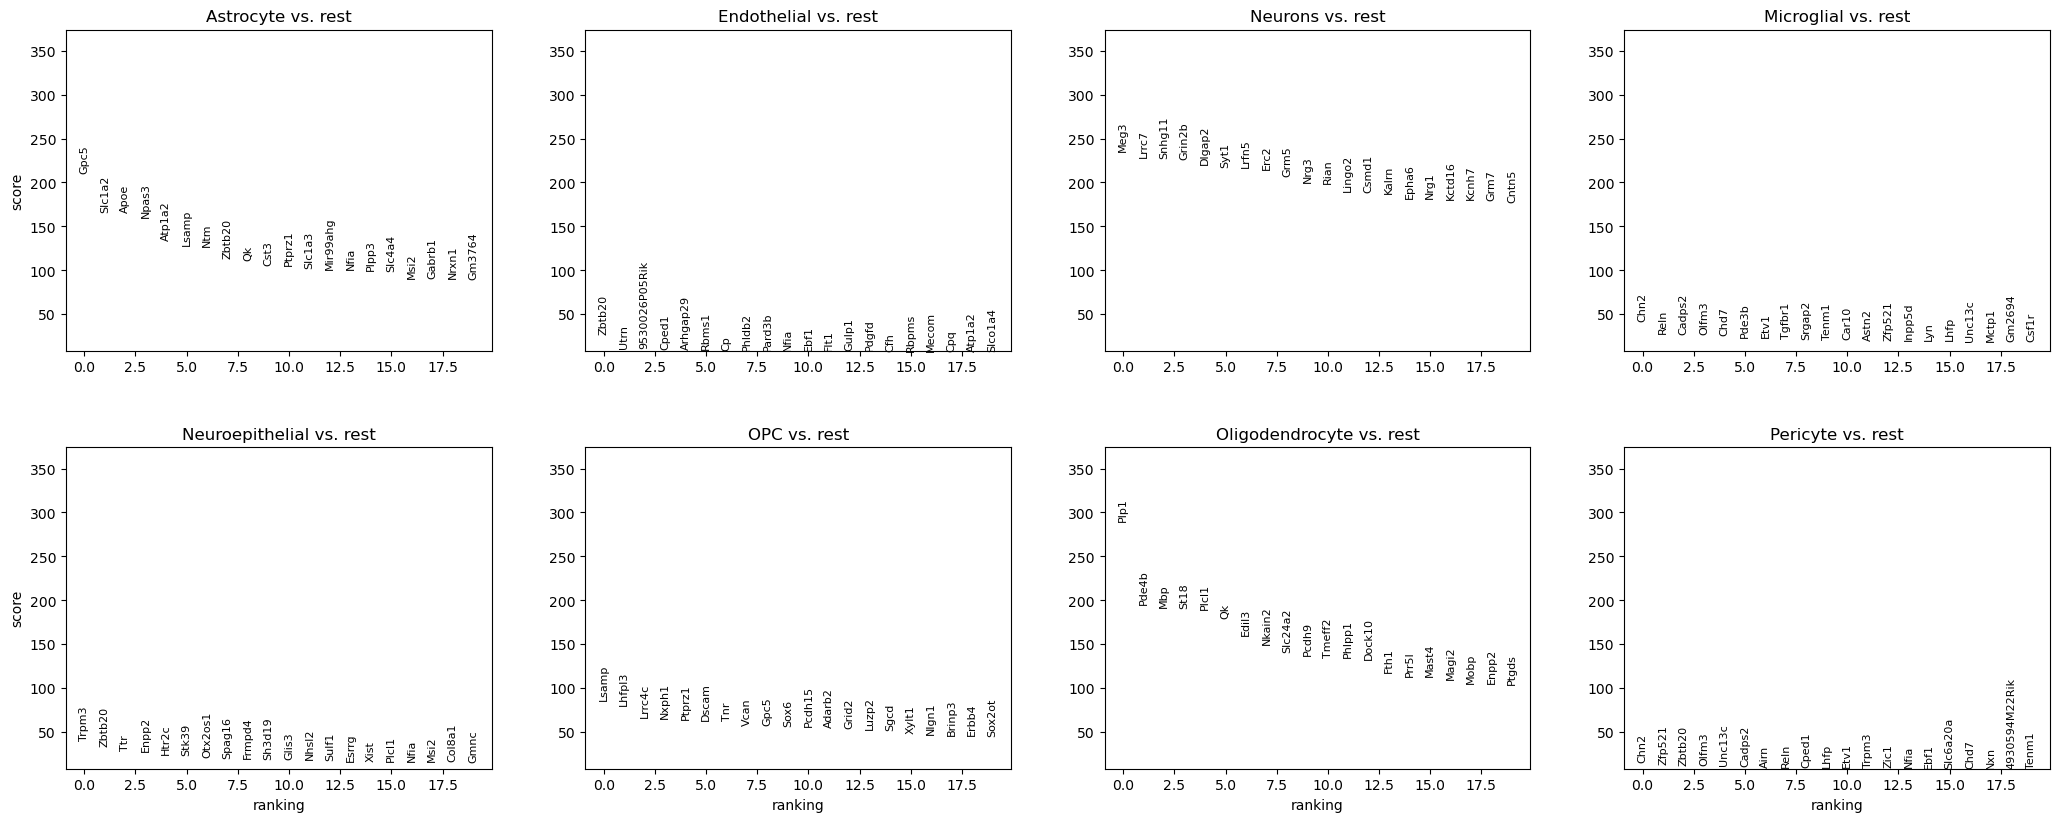

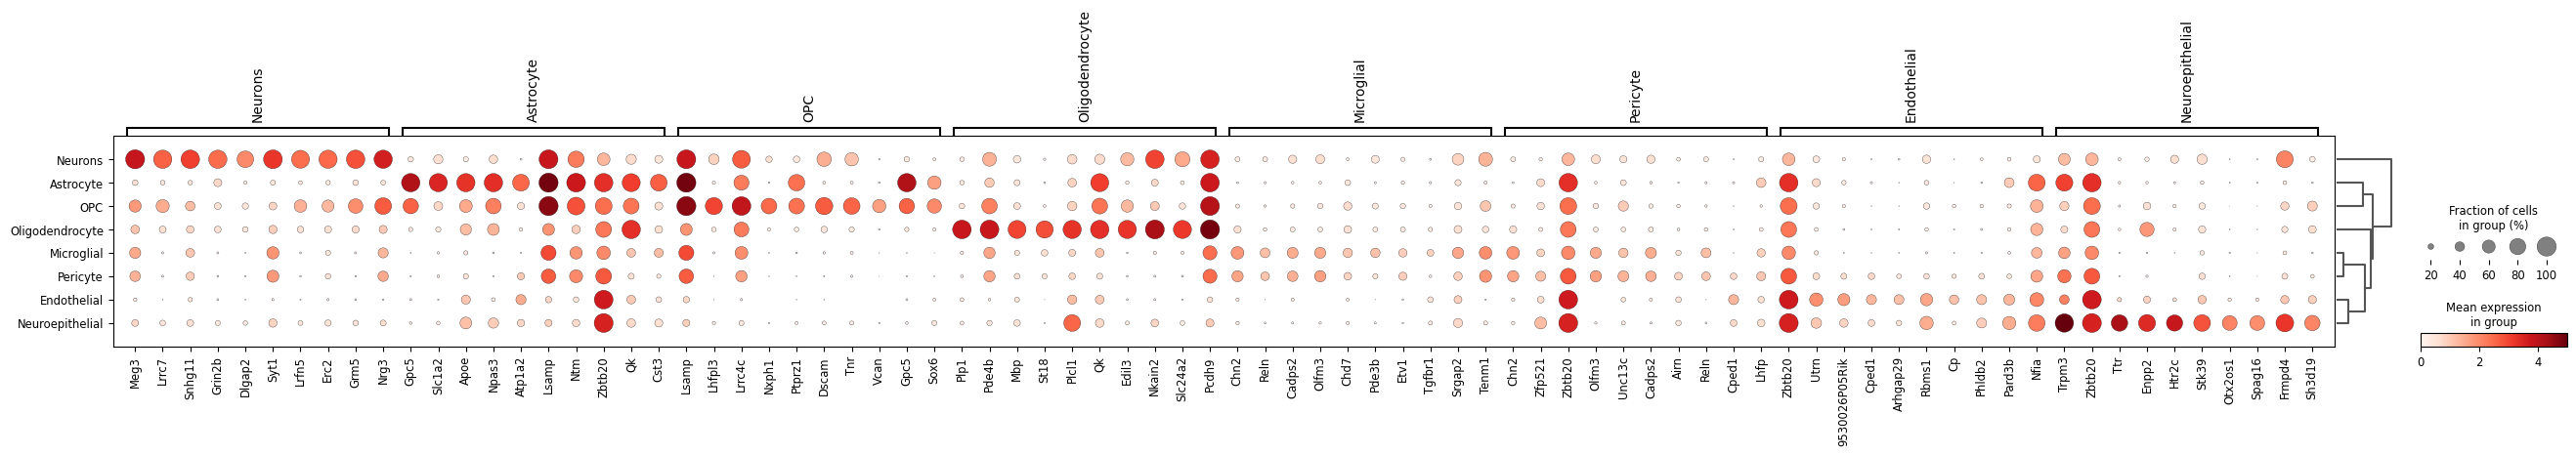

scores  logfoldchanges          pvals      pvals_adj  pct_nz_group  pct_nz_reference
annotation_scanvi_collapsed annotation_scanvi_collapsed names                                                                                                 
Astrocyte                   Astrocyte                   Msi2           90.946098        3.261281   0.000000e+00   0.000000e+00      0.810478          0.404313
                                                        Gabrb1         90.786873        2.475232   0.000000e+00   0.000000e+00      0.911017          0.675325
                                                        Nrxn1          90.630043        1.913130   0.000000e+00   0.000000e+00      0.972265          0.875118
Endothelial                 Endothelial                 Zbtb20         27.311522        3.074736   9.310808e-62   4.301525e-61      0.968153          0.650051
                                                        Utrn           11.776273        3.548953   2.585640e-23   7.199438e-23      0.617834          0.231337
                                                        9530026P05Rik  11.706896        4.654633   4.032571e-23   1.120216e-22      0.541401          0.093503
Microglial                  Microglial                  Chn2           42.501297        3.822199  2.267885e-285  1.119118e-283      0.580116          0.169433
                                                        Reln           28.206295        2.910359  9.726598e-149  2.307252e-147      0.408784          0.142347
                                                        Cadps2         27.151955        2.322925  1.455975e-139  3.232745e-138      0.474421          0.267650
Neuroepithelial             Neuroepithelial             Trpm3          41.074696        5.734245  6.624328e-108  1.777087e-106      0.947598          0.507142
                                                        Zbtb20         34.163395        2.890065   7.535590e-93   1.626161e-91      0.982533          0.649629
                                                        Ttr            28.850046        9.021933   4.623896e-78   8.242181e-77      0.816594          0.075108
Neurons                     Neurons                     Cbarp          48.261032        1.859474   0.000000e+00   0.000000e+00      0.195281          0.049896
                                                        Klhl7          47.983051        1.295839   0.000000e+00   0.000000e+00      0.385861          0.145827
                                                        Phf20l1        48.016766        1.027188   0.000000e+00   0.000000e+00      0.643054          0.322592
OPC                         OPC                         Lsamp          86.325478        1.616363   0.000000e+00   0.000000e+00      0.998464          0.892050
                                                        Lhfpl3         80.110672        4.291574   0.000000e+00   0.000000e+00      0.858295          0.350759
                                                        Lrrc4c         66.857498        2.056013   0.000000e+00   0.000000e+00      0.971198          0.840360
Oligodendrocyte             Oligodendrocyte             Car2           73.984337        4.755180   0.000000e+00   0.000000e+00      0.441917          0.044707
                                                        Apod           73.965744        5.418760   0.000000e+00   0.000000e+00      0.427867          0.026730
                                                        Aplp1          73.964508        2.472160   0.000000e+00   0.000000e+00      0.635144          0.348450
Pericyte                    Pericyte                    Chn2           15.242699        3.317348   6.911527e-42   3.950625e-41      0.492683          0.181036
                                                        Zfp521         13.146095        2.967441   3.465252e-33   1.672760e-32      0.421951          0.136669
                                                        Zbtb20         12.683339        1.629650   

In [5]:
self.find_markers(col_celltype=col_celltype)
df_celltype_markers = self.get_markers_df(
    n_genes=50, col_celltype=col_celltype,
    log2fc_threshold=1, p_threshold=1e-10)
df_celltype_markers.groupby(col_celltype).apply(lambda x: x.head(3))

# Regress Out?

In [ ]:
# if vars_regress_out is not None:
#     self.rna.X = self.rna.layers["log1p"].copy()
#     sc.pp.regress_out(self.rna, vars_regress_out)
#     self.rna.layers["log1p"] = self.rna.X.copy()
#     pkg.pp.scale(self.rna, zero_center=True, max_value=10)
#     self.rna.layers["scaled"] = self.rna.X.copy()
#     self.rna.X = self.rna.layers["log1p"].copy()

# Score Senescence

## Run Scoring

If you want just to find the senescence-related genes, run:

```
tissue = "Brain"  # or whatever you want here
celltype = None  # or whatever you want here
genes_senepy, hubs, figs = find_senescence_genes(
    self.rna, species=species, tissue=tissue, celltype=celltype,
    overlap_threshold=0, literature_sources=None,
    sengpt_sources=True, plot=True, col_celltype=col_celltype
)  # find tissue- and/or cell type-specific genes
```

To see available hubs:

```
hubs = senepy.load_hubs(species=species)
hubs.metadata.set_index(["tissue", "cell"]).sort_index()
```

Other examples of arguments you could use:

```
# tissue = ["Brain", "Myeloid"]
# tissue = None

# celltype = "GABA interneuron"  # only human I think
# celltype = ["microglia", "t cell", "monocyte"]
# celltype = "microglia"
# celltype = "microglial cell"`

### Senepy

In [6]:
%%time

tissue = "Brain"
celltype = None  # use all cell types

if "senepy" in sen_metrics:
    self.rna.X = self.rna.layers["log1p"].copy()
    self.rna, genes_senepy, figs = run_senepy(
        self.rna, species=species, tissue=tissue, celltype=celltype,
        overlap_threshold=0, literature_sources=None,
        sengpt_sources=True, col_celltype=col_celltype,
        col_senscore="score_senepy", identifiers=[col_celltype],
        use_translator=True, plot=True, figsize=(20, 20),
        swap_axes=False, standard_scale="group", plot_layer="log1p"
    )  # find tissue- and/or cell type-specific genes
    self.rna.obs.loc[
        :, "score_senepy_original_scale"] = self.rna.obs.score_senepy
    self.rna.obs.loc[:, "score_senepy"] = np.log(
        self.rna.obs.score_senepy)  # log-transform senescence score
    self.rna.obs[["score_senepy"]]

CPU times: user 1 μs, sys: 2 μs, total: 3 μs
Wall time: 5.01 μs


### Senmayo

In [7]:
if "senmayo" in sen_metrics:
    sc.tl.score_genes(self.rna, marker_gene_sets.loc["Senmayo"],
                      ctrl_as_ref=True, ctrl_size=50, gene_pool=None,
                      n_bins=25, score_name="score_senmayo", random_state=0,
                      copy=False, layer="log1p", use_raw=False)

## Label SnCs

### Define Snc Threshold & Label Cells

Based on percentile threshold derived from control group

In [9]:
# Determine Threshold
perc_s, perc = str(100 - percentile) + "%", 1 - (percentile / 100)
p_h = 3
perc_s_h, perc_h = str(100 - p_h) + "%", 1 - (p_h / 100)
print("Percentile for Threshold:", perc_s)
for u in sen_metrics:
    # raise ValueError("Need to fix so control = reference")
    self.rna.obs = self.rna.obs.assign(**{
        f"Senescence_Threshold_{u}": self.rna[self.rna.obs[col_batch] == keys[
            col_batch]["key_control"]].obs[
            f"score_{u}"].describe(percentiles=[perc])[perc_s]})
    self.rna.obs = self.rna.obs.assign(**{
        f"Senescence_Threshold_{u}_{p_h}": self.rna[self.rna.obs[
            col_batch] == keys[col_batch]["key_control"]].obs[
                f"score_{u}"].describe(percentiles=[perc_h])[perc_s_h]})

# Binary CLassification
for x in sen_metrics:
    self.rna.obs.loc[:, f"Senescent_Cell_{x}"] = (self.rna.obs[
        f"score_{x}"] >= self.rna.obs[f"Senescence_Threshold_{x}"])
    self.rna.obs.loc[:, f"Senescent_Cell_{x}_{p_h}"] = (self.rna.obs[
        f"score_{x}"] >= self.rna.obs[f"Senescence_Threshold_{x}_{p_h}"])

# String Labels (for Plotting/Categorical Analysis)
for x in sen_metrics:
    self.rna.obs.loc[:, f"Senescent_Cell_Label_{x}"] = self.rna.obs[
        f"Senescent_Cell_{x}"].astype(bool).astype(str).replace({
            "True": "Senescent", "False": "Non-Senescent"})
    self.rna.obs.loc[:, f"Senescent_Cell_Label_hierarchy_{x}"] = self.rna.obs[
        f"Senescent_Cell_{x}"].astype(bool).astype(str).replace({
            "True": "Senescent", "False": "Non-Senescent"})
    self.rna.obs.loc[:, f"Senescent_Cell_Label_{x}_{p_h}"] = self.rna.obs[
        f"Senescent_Cell_{x}_{p_h}"].astype(bool).astype(str).replace({
            "True": "Senescent", "False": "Non-Senescent"})
    self.rna.obs.loc[:, f"Senescent_Cell_Label_by_Type_{x}"] = self.rna.obs[
        f"Senescent_Cell_Label_{x}"].replace({
            "Senescent": "SnC ", "Non-Senescent": ""}) + self.rna.obs[
                col_celltype].astype(str)
    self.rna.obs.loc[:, f"SnC_hierarchy_{x}"] = self.rna.obs[
        f"Senescent_Cell_Label_{x}"].replace({
            "Senescent": "SnC ", "Non-Senescent": ""}) + self.rna.obs[
                col_celltype + "_hierarchy"].astype(str)

# Descriptives
for x in sen_metrics:
    print(x, round(self.rna.obs[[
        f"Senescent_Cell_Label_{x}", col_celltype, col_batch]].groupby(
            col_batch).value_counts(normalize=True).sort_index(
                ) * 100, 1).unstack(1))

# Choose Metrics for Main Analysis
for x in ["Senescent_Cell_Label", "Senescent_Cell", "SnC_hierarchy",
            "Senescence_Threshold", "Senescent_Cell_Label_by_Type"]:
    self.rna.obs.loc[:, x] = self.rna.obs[f"{x}_{use_metric}"]
self.rna.obs.loc[:, "senscore"] = self.rna.obs[f"score_{use_metric}"]
self.rna.obs.loc[
    :, f"Senescent_Cell_Label_by_Type_{use_metric}_{p_h}"] = self.rna.obs[
        f"Senescent_Cell_Label_{use_metric}_{p_h}"].replace({
            "Non-Senescent": "", "Senescent": "SnC "}).astype(
                str) + self.rna.obs[
                    col_celltype].astype(str)  # lower threshold SnC by type
genes = marker_gene_sets.loc["Senmayo"] if (
    use_metric == "senmayo") else genes_senepy  # main senescence gene list

# Avoid Nesting Duplication Issues
self.rna.obs.loc[:, "SnC_hierarchy"] = self.rna.obs[
    "SnC_hierarchy"].replace({
        "Neuron": "Neurons", "SnC Neuron": "SnC Neurons"})

Percentile for Threshold: 99%
senmayo Senescent_Cell_Label_senmayo                Non-Senescent  Senescent
Condition      annotation_scanvi_collapsed                          
Ground Control Astrocyte                              8.1        0.3
               Endothelial                            0.1        0.0
               Neurons                               65.8        0.4
               Microglial                             5.0        0.1
               Neuroepithelial                        0.5        0.0
               OPC                                    4.9        0.1
               Oligodendrocyte                       14.4        0.1
               Pericyte                               0.1        0.0
Space Flight   Astrocyte                              7.9        0.3
               Endothelial                            0.3        0.0
               Neurons                               68.9        0.2
               Microglial                             1.3        

### Label Batch/Cell-Specific Senescence Percentiles

In [ ]:
# for x in ["Senescence_Label", "Senescence_CellType"]:
#     if x in self.rna.obs:
#         self.rna.obs = self.rna.obs.drop(x, axis=1)

# # %ile Thresholds (Overall)
# thresh = self.rna.obs["score_senepy"].describe(
#     percentiles=[0.90, 0.95, 0.99])
# thres_ct =  self.rna.obs[["score_senepy", col_celltype]].groupby(
#     col_celltype).describe(percentiles=[0.90, 0.95, 0.99])["score_senepy"]

# sen = self.rna.obs["score_senepy"].apply(
#     lambda x: "Top 1%" if x >= float(thresh.loc["99%"]) else "Top 5%" if (
#         x >= float(thresh.loc["95%"])) else "Top 10%" if x >= float(
#             thresh.loc["90%"]) else "Bottom 90%").to_frame(
#                 "Senescence_Label").loc[self.rna.obs.index]
# self.rna.obs = self.rna.obs.join(sen).loc[self.rna.obs.index]

# # %ile Thresholds (by Cell Type)
# sct = self.rna.obs.groupby(
#     col_celltype).apply(lambda g: g["score_senepy"].apply(
#         lambda x: f"Top 1% {g.name}" if x >= float(thres_ct.loc[g.name][
#             "99%"]) else f"Top 5% {g.name}" if (x >= float(thres_ct.loc[
#                 g.name]["95%"])) else f"Top 10% {g.name}" if x >= float(
#                     thres_ct.loc[g.name]["90%"]) else g.name),
#                         include_groups=False)

# sct = sct.to_frame("Senescence_CellType").reset_index(0, drop=True)
# sct = sct.loc[self.rna.obs.index]
# self.rna.obs = self.rna.obs.join(sct).loc[self.rna.obs.index]

# for x in ["Senescence_Label", "Senescence_CellType"]:
#     self.rna.obs = self.rna.obs.assign(**{
#         x: self.rna.obs[x].astype("category")})

# high_sen_cts = [i for i in self.rna.obs["Senescence_CellType"].unique(
#     ) if " 1% " in i]

### Descriptives of SnCs

Percent Senescent: 

 Senescent_Cell                      0                                                                                        1                                                                              
annotation_scanvi_collapsed Astrocyte Endothelial Neurons Microglial Neuroepithelial    OPC Oligodendrocyte Pericyte Astrocyte Endothelial Neurons Microglial Neuroepithelial   OPC Oligodendrocyte Pericyte
Condition                                                                                                                                                                                                   
Ground Control                  96.01       83.33   99.38      98.68           96.61  98.90           99.46    92.16      3.99       16.67    0.62       1.32            3.39  1.10            0.54     7.84
Space Flight                    95.76       90.83   99.66      93.55           98.08  98.76           99.66    95.26      4.24        9.17    0.34       6.45 

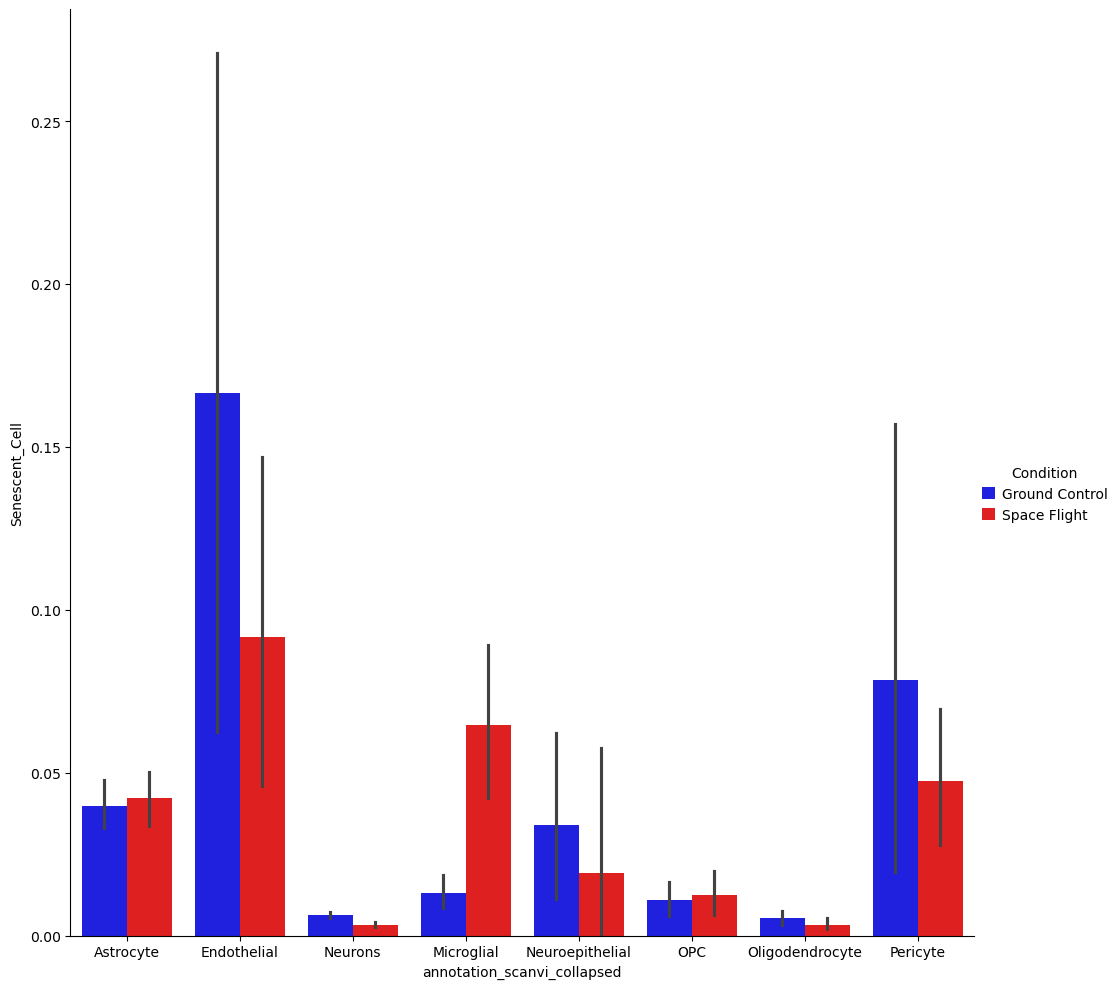

In [14]:
print("Percent Senescent: \n\n", round(self.rna.obs.groupby([
    col_celltype, col_batch]).apply(lambda x: x["Senescent_Cell"].astype(
        int).value_counts(normalize=True), include_groups=False) * 100,
    2).unstack(col_celltype))
sns.catplot(self.rna.obs, y="Senescent_Cell", x=col_celltype,
            hue=col_batch, kind="bar", palette=palette[col_batch], height=10)

# SnC DEGs

## Overall

... storing 'Senescent_Cell_Label_senmayo' as categorical
... storing 'Senescent_Cell_Label_hierarchy_senmayo' as categorical
... storing 'Senescent_Cell_Label_senmayo_3' as categorical
... storing 'Senescent_Cell_Label_by_Type_senmayo' as categorical
... storing 'SnC_hierarchy_senmayo' as categorical
... storing 'Senescent_Cell_Label' as categorical
... storing 'SnC_hierarchy' as categorical
... storing 'Senescent_Cell_Label_by_Type' as categorical
... storing 'Senescent_Cell_Label_by_Type_senmayo_3' as categorical


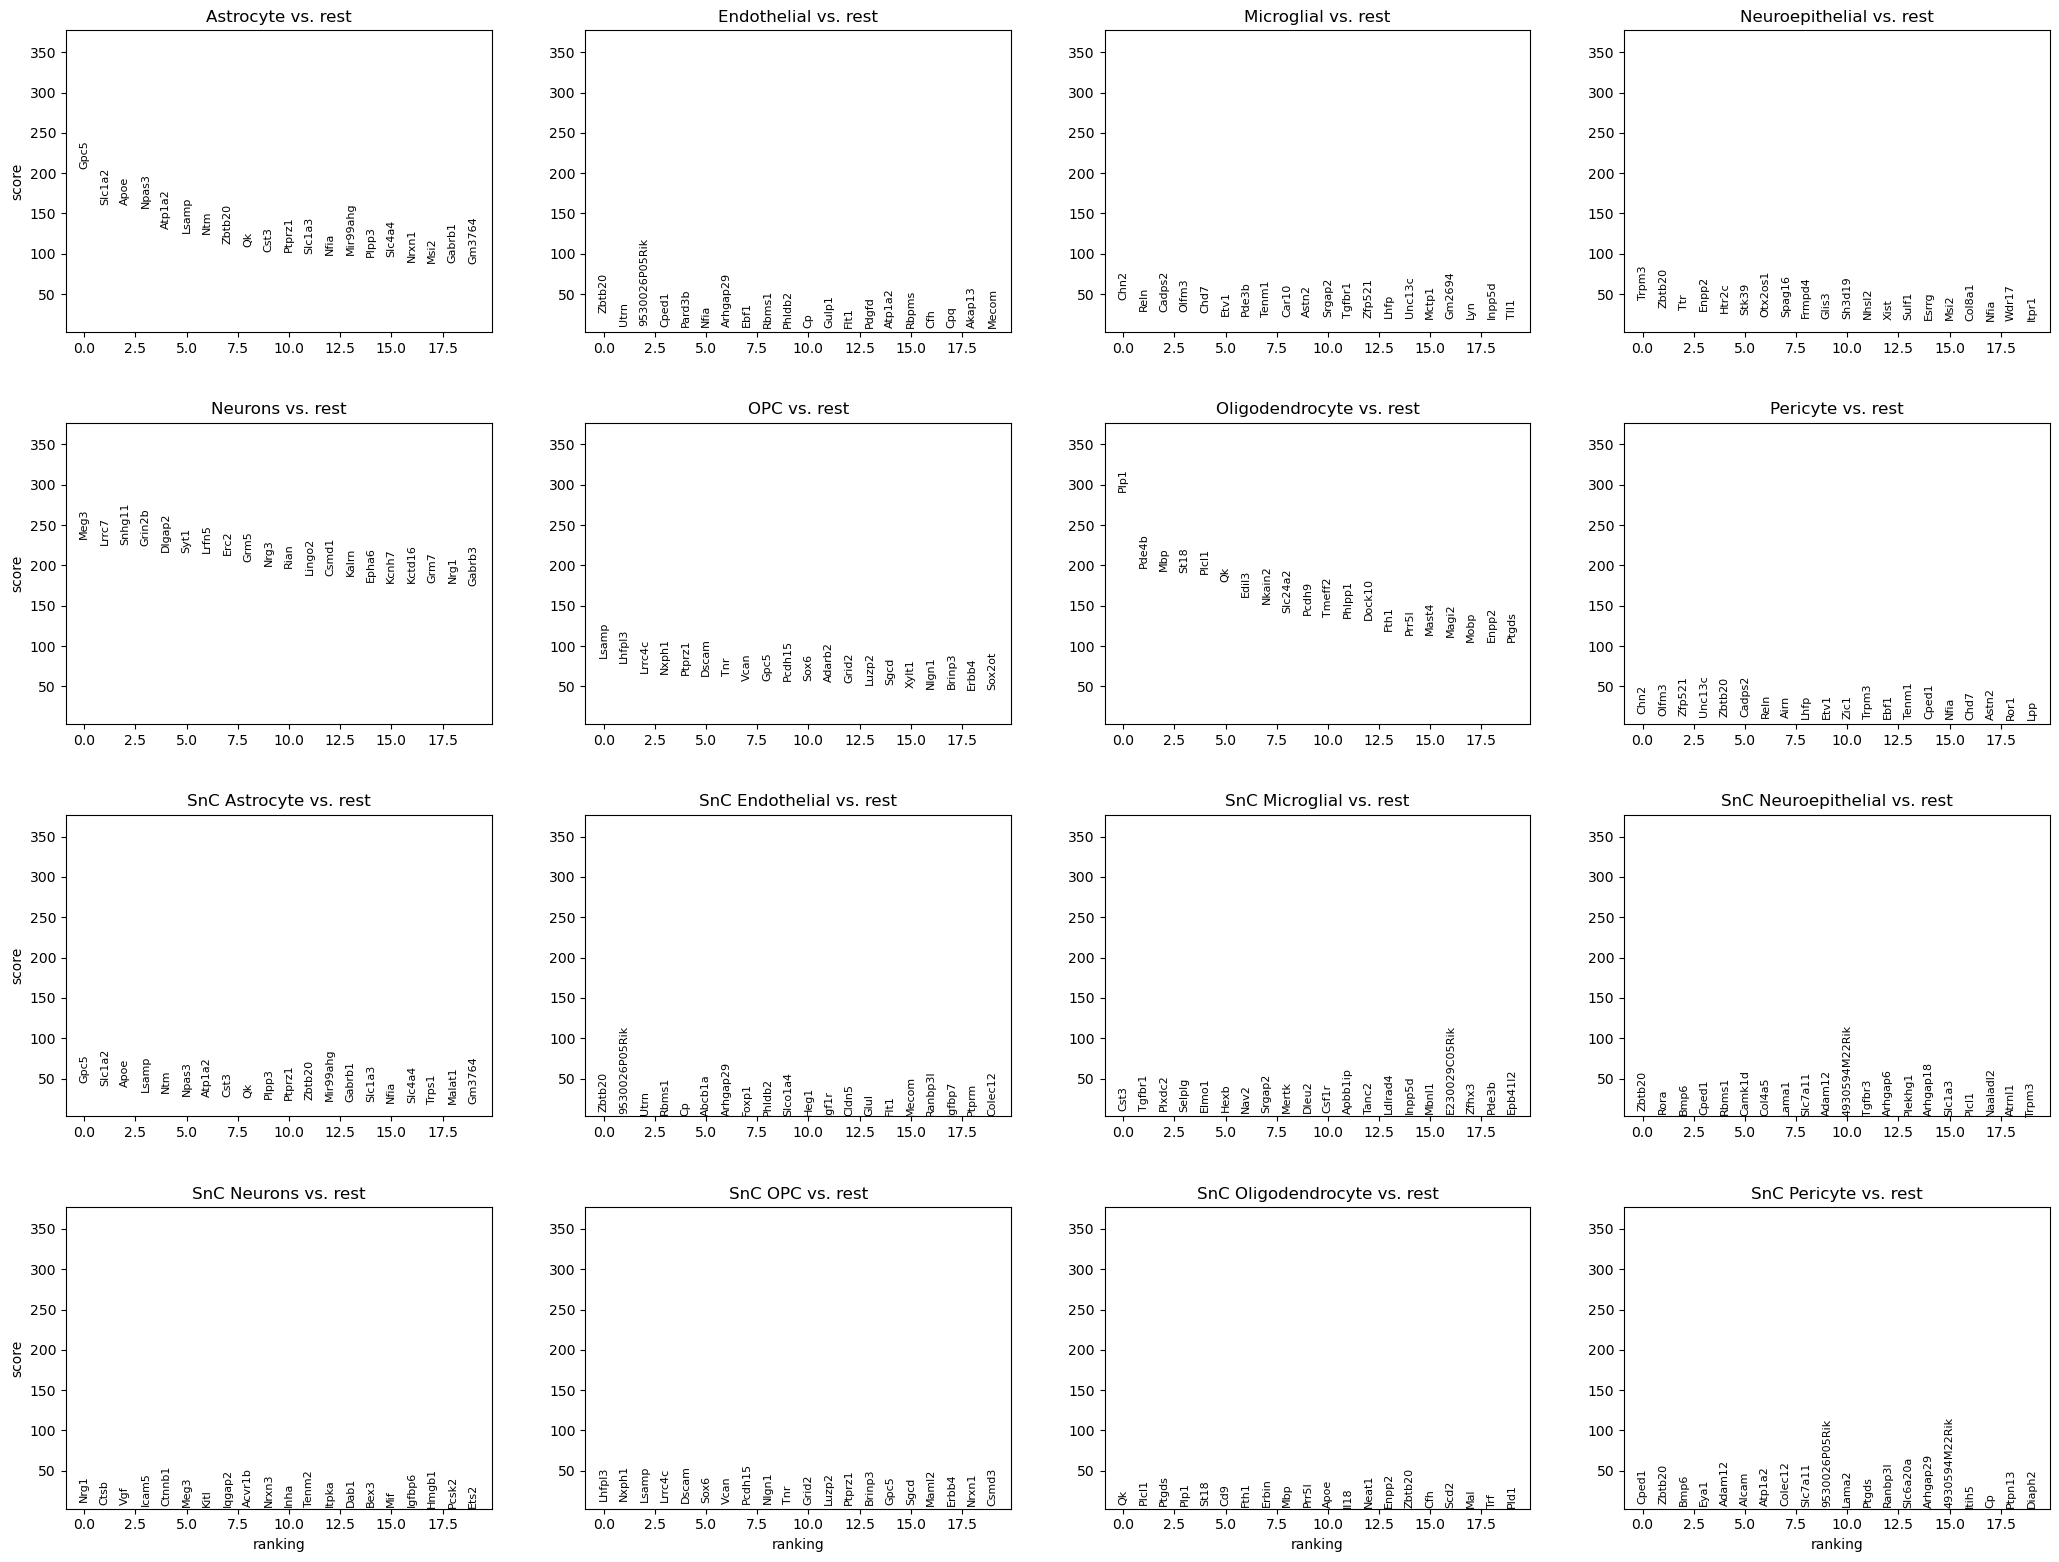

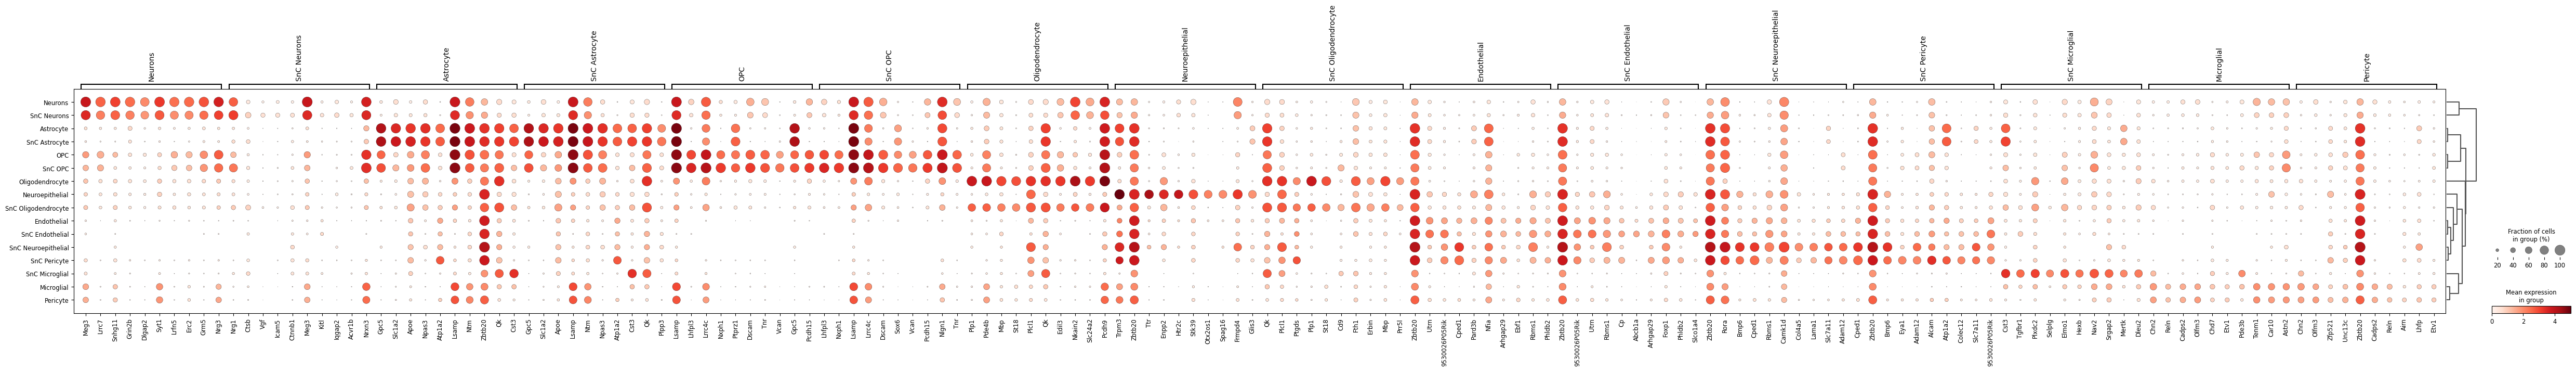

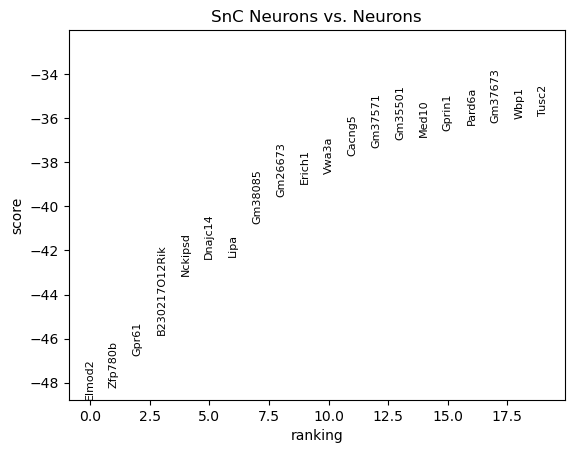

categories: Astrocyte, Endothelial, Microglial, etc.
var_group_labels: SnC Neurons


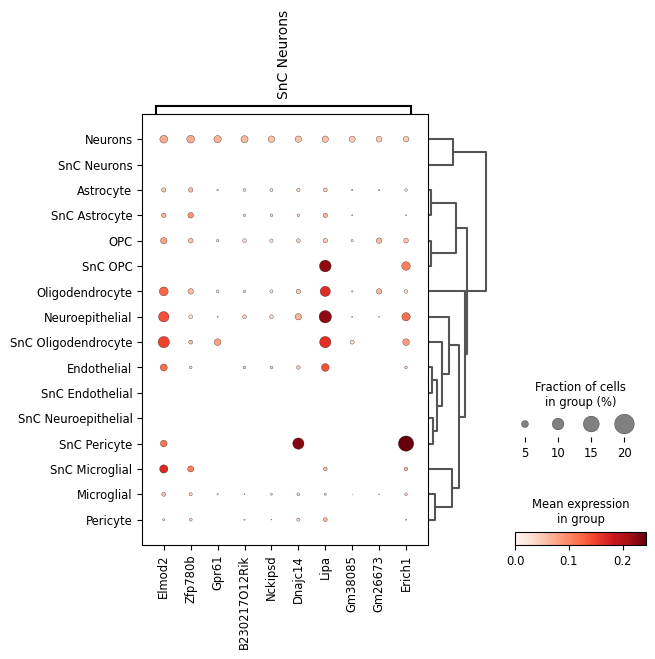

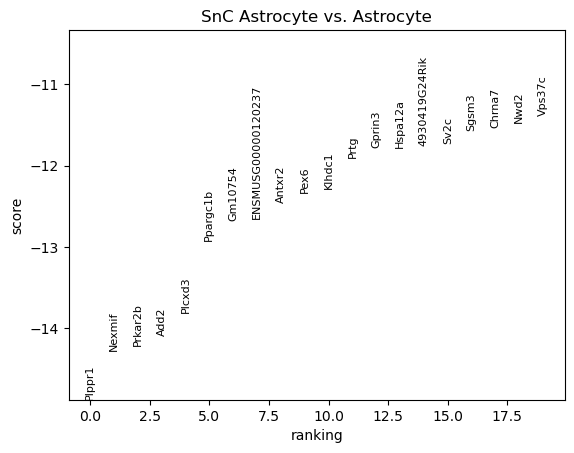

categories: Astrocyte, Endothelial, Microglial, etc.
var_group_labels: SnC Astrocyte


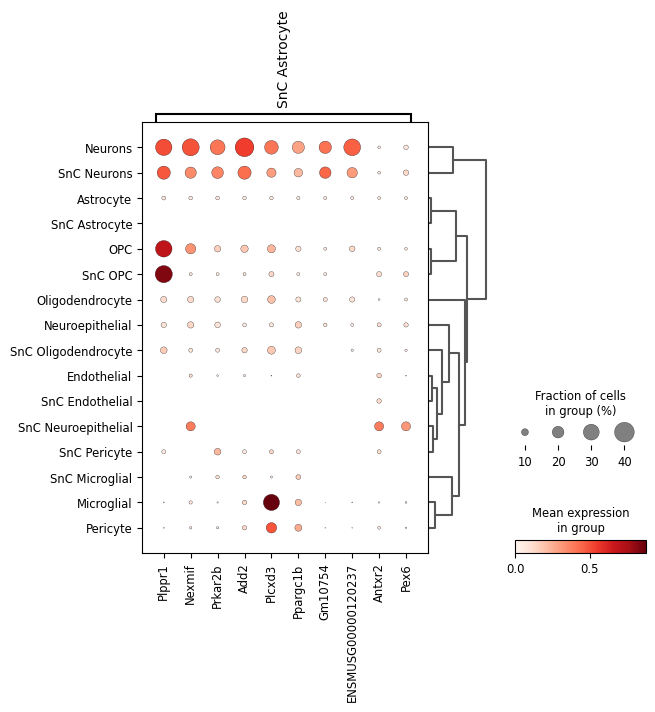

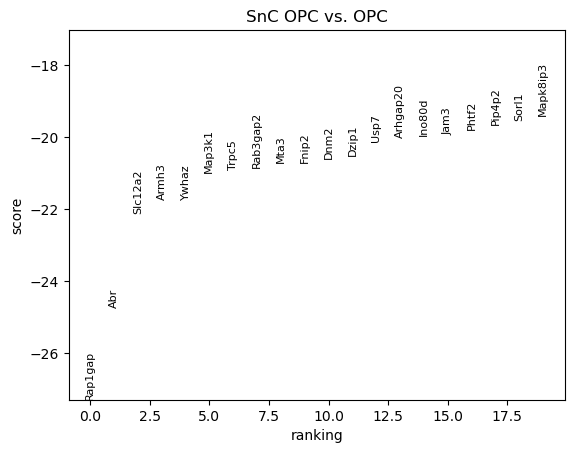

categories: Astrocyte, Endothelial, Microglial, etc.
var_group_labels: SnC OPC


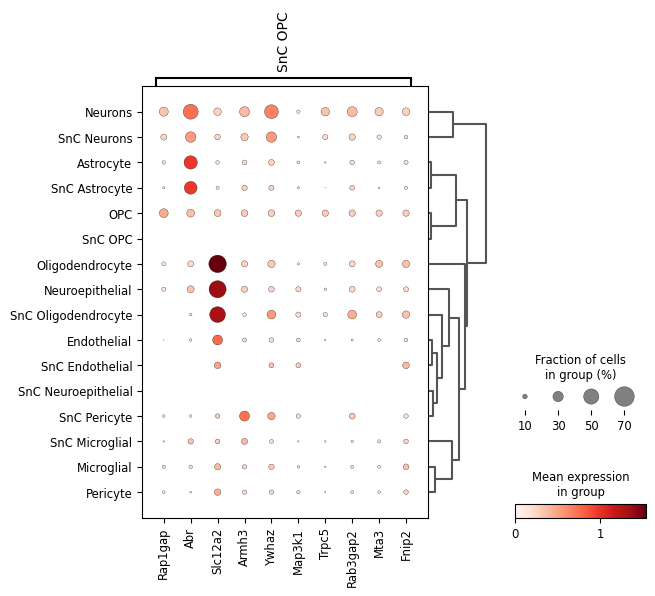

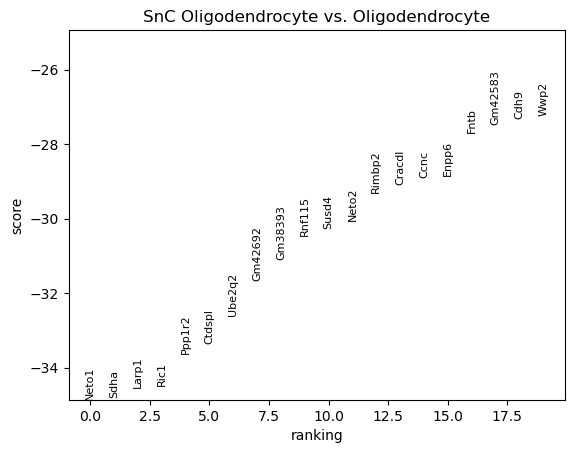

categories: Astrocyte, Endothelial, Microglial, etc.
var_group_labels: SnC Oligodendrocyte


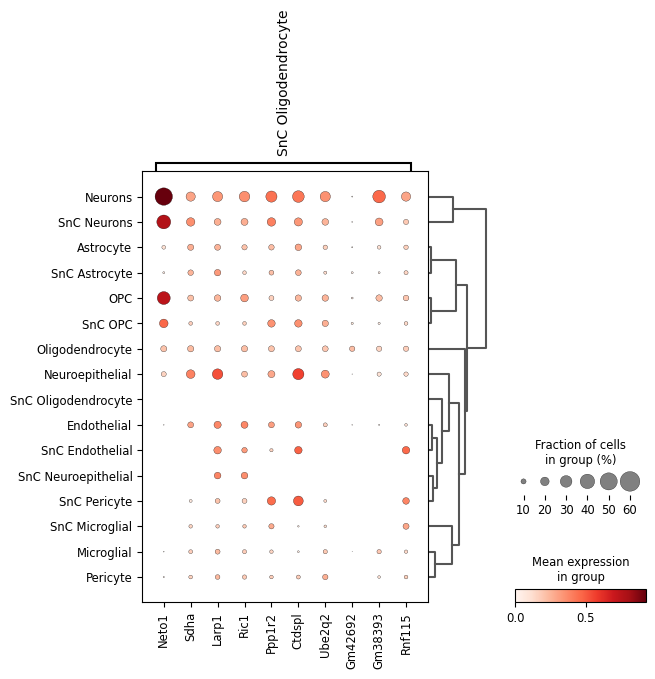

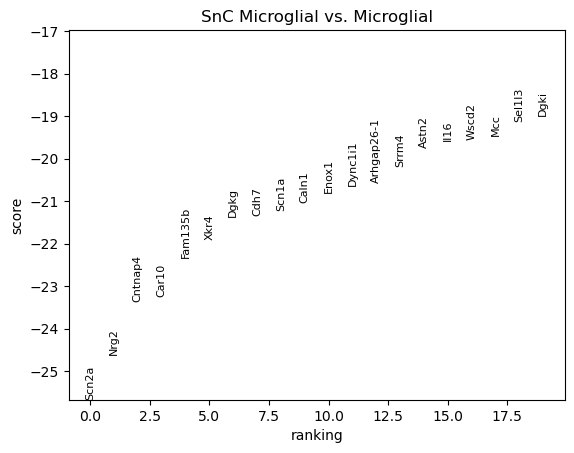

categories: Astrocyte, Endothelial, Microglial, etc.
var_group_labels: SnC Microglial


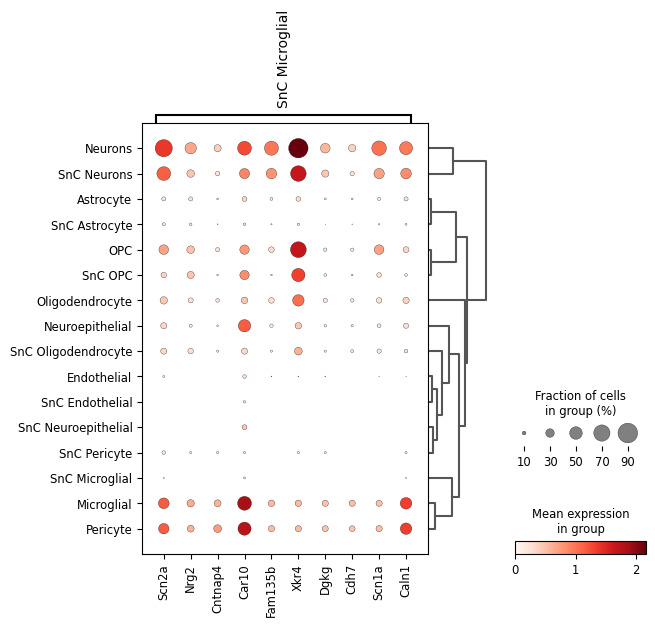

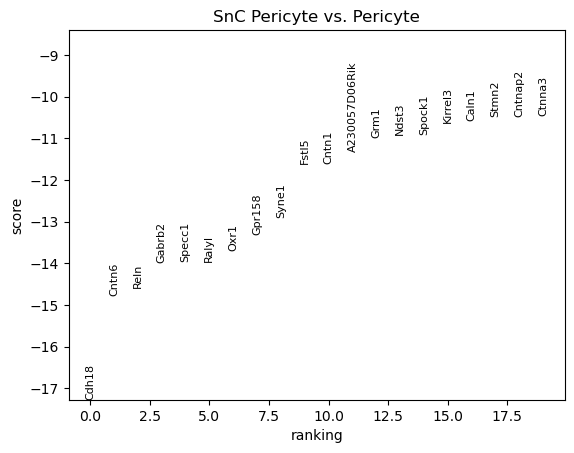

categories: Astrocyte, Endothelial, Microglial, etc.
var_group_labels: SnC Pericyte


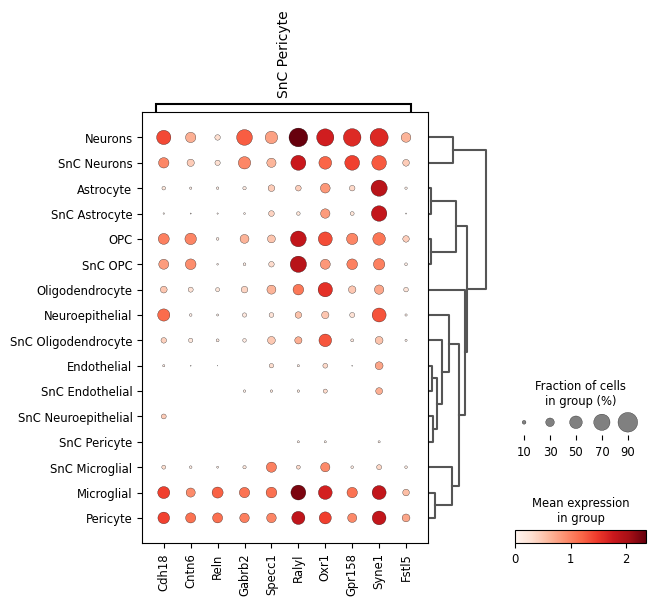

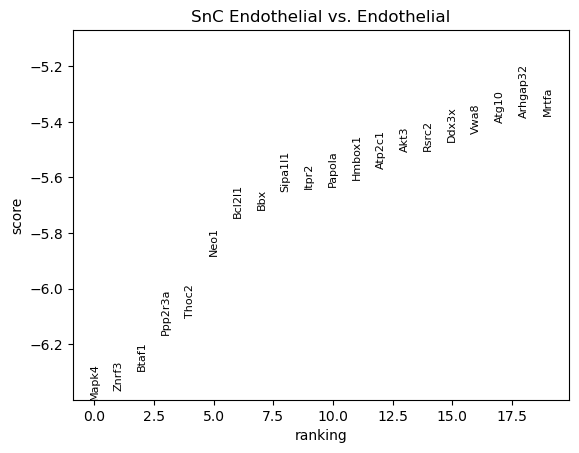

categories: Astrocyte, Endothelial, Microglial, etc.
var_group_labels: SnC Endothelial


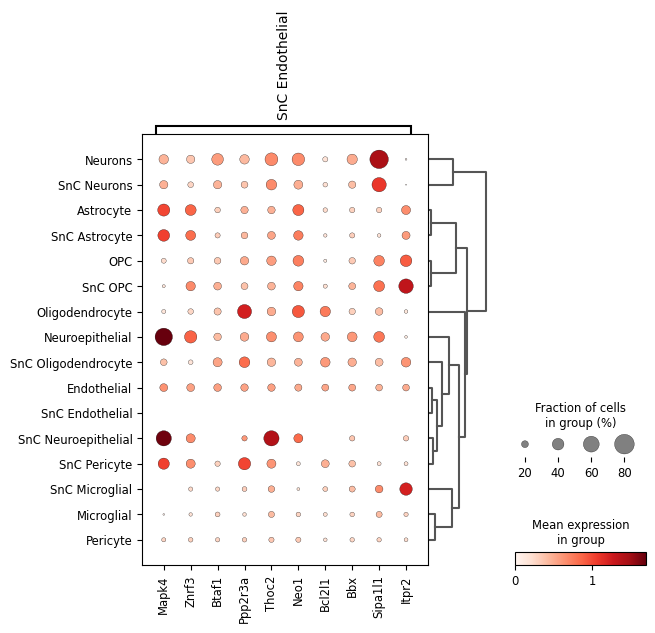

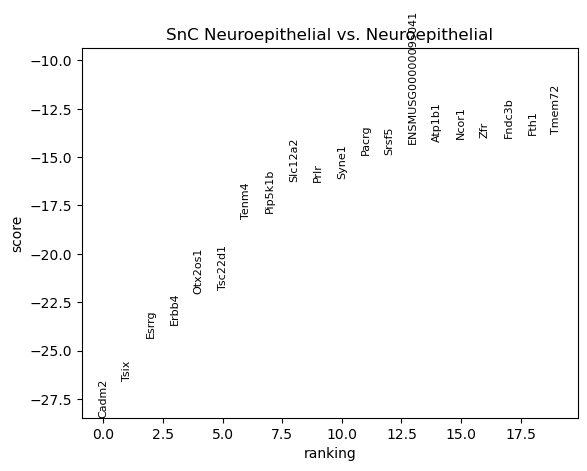

categories: Astrocyte, Endothelial, Microglial, etc.
var_group_labels: SnC Neuroepithelial


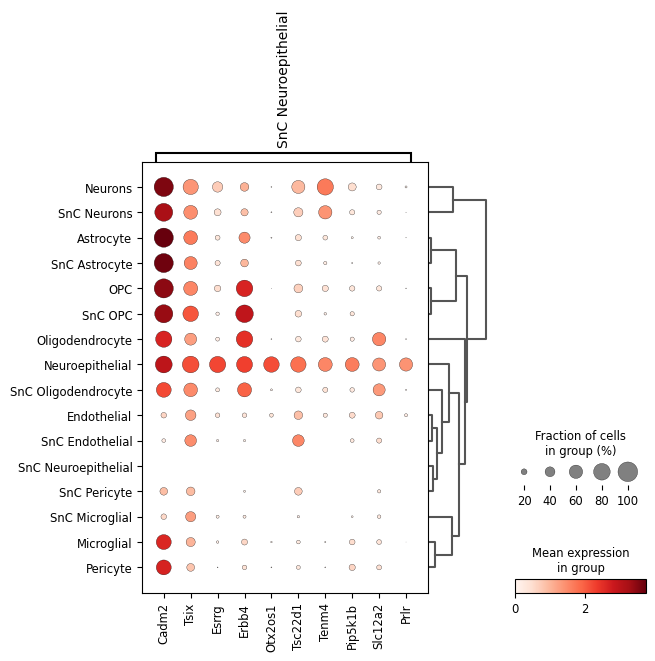

In [15]:
p_threshold = 1e-10
lfc_threshold = 1
self.find_markers(col_celltype="Senescent_Cell_Label_by_Type")
df_snc_markers = {}
df_snc_markers["All"] = self.get_markers_df(
    n_genes=50, col_celltype="Senescent_Cell_Label_by_Type",
    log2fc_threshold=1, p_threshold=1e-10)
# print(df_snc_markers["All"].loc[pd.unique([
#     i[0] for i in df_snc_markers["All"].index.values if (
#         "SnC" in i[0])])].groupby("Senescent_Cell_Label_by_Type").apply(
#             lambda x: x.head(3)))
for x in self.rna.obs[col_celltype].unique():
    df_snc_markers[x] = self.find_markers(
        col_celltype="Senescent_Cell_Label_by_Type",
        reference=x, groups=[x, f"SnC {x}"], rankby_abs=True,
        inplace=False).reset_index(0, drop=True).assign(**{
            col_celltype: f"SnC {x}"}).reset_index().set_index([
                col_celltype, "names"])
df_snc_markers = pd.concat(df_snc_markers, names=["Comparison"])
df_snc_markers = df_snc_markers.rename_axis([
    "Comparison", col_celltype, "names"]).rename({
        "logfoldchanges": "log_fc"}, axis=1).assign(
            log_fc_abs=df_snc_markers["logfoldchanges"].abs())
df_snc_markers_top = df_snc_markers[df_snc_markers.pvals_adj < p_threshold]
df_snc_markers_top = df_snc_markers_top[
    df_snc_markers.log_fc_abs >= lfc_threshold]
df_snc_markers_top = df_snc_markers_top.groupby([
    "Comparison", col_celltype]).apply(
        lambda x: x.assign(scores_abs=x.scores.abs()).sort_values(
            "scores_abs", ascending=False).head(20),
        include_groups=False).reset_index([0, 1], drop=True)

## By Group

### Find Snc versus Non-SnC DEGs by Group

In [ ]:
res_rank_genes, p_threshold = {}, 1e-10

for x in self.rna.obs[col_condition].unique():
    res_rank_genes[x] = {}
    for c in self.rna.obs[self.rna.obs[col_condition] == x][
            col_celltype].unique():
        s_iter = (self.rna.obs[col_condition] == x) & (self.rna.obs[
            "Senescent_Cell_Label_by_Type"].isin([c, f"SnC {c}"]))
        all_pres = all([i in self.rna[s_iter].obs[
            "Senescent_Cell_Label_by_Type"].to_list()
                        for i in [c, f"SnC {c}"]])
        if all_pres is False:
            print(f"SnC not in {c} for {x}")
            continue
        tmp = sc.tl.rank_genes_groups(
            self.rna[s_iter], "Senescent_Cell_Label_by_Type", rankby_abs=True,
            layer="log1p", groups=[c, f"SnC {c}"], reference=c, copy=True)
        res_rank_genes[x][c] = sc.get.rank_genes_groups_df(
            tmp, f"SnC {c}", pval_cutoff=p_threshold)
    tmp = sc.tl.rank_genes_groups(
            self.rna[self.rna.obs[col_condition] == x],
            "Senescent_Cell_Label", rankby_abs=True,
            layer="log1p", reference="Non-Senescent", copy=True)
    res_rank_genes[x]["Overall"] = sc.get.rank_genes_groups_df(
            tmp, f"Senescent", pval_cutoff=p_threshold)
    res_rank_genes[x] = pd.concat(res_rank_genes[x], names=[col_celltype])
res_rank_genes = pd.concat(res_rank_genes, names=[col_condition])
res_rank_genes = res_rank_genes.assign(
    logfoldchanges_abs=res_rank_genes.logfoldchanges.abs())
res_rank_genes_top = res_rank_genes.reset_index().groupby([
    col_condition, col_celltype]).apply(
        lambda x: x.sort_values("logfoldchanges_abs").iloc[:20],
        include_groups=False).reset_index(2, drop=True).set_index(
            "names", append=True).rename_axis([
                col_condition, col_celltype, "variable"])
res_rank_genes_top

### Figures by Batch (Cell Types in Same Figure)

In [ ]:
# if col_batch in self.rna.obs.index.names:
#     self.rna.obs = self.rna.obs.reset_index(col_batch)
# for k in res_rank_genes_top[col_batch].unique():
#     g_top_snc_sfold = dict(res_rank_genes_top.loc[k].groupby(
#         col_celltype).apply(lambda x: x.loc[x.name].index.values))
#     fig = self.plot(subset=self.rna.obs[col_batch] == k,
#                     genes=g_top_snc_sfold, col_celltype=col_celltype,
#                     kind=["heat"], figsize=(20, 20),
#                     standard_scale="var", title=k, fontsize=20)

#### Genes Grouped by Batch

In [ ]:
# for k in res_rank_genes_top.reset_index()[col_celltype].unique():
#     g_top_snc_sfold = dict(res_rank_genes_top.loc[:, k, :].groupby(
#         col_batch).apply(lambda x: x.loc[x.name].index.values))
#     fig = self.plot(subset=self.rna.obs[col_celltype] == k,
#                     genes=g_top_snc_sfold, col_celltype=col_batch,
#                     kind="matrix", figsize=(20, 20),
#                     swap_axes=True, title=k,
#                     standard_scale="var", fontsize=20)

#### Not Grouped

In [ ]:
for k in [i for i in res_rank_genes_top.reset_index()[col_celltype].unique(
        ) if i in self.rna.obs[col_celltype].unique()]:
    g_top_snc_sfold = list(res_rank_genes_top.loc[:, k, :].reset_index(
        ).variable.unique())
    fig = self.plot(subset=self.rna.obs[col_celltype] == k,
                    genes=g_top_snc_sfold, col_celltype=col_batch,
                    kind="matrix", figsize=(20, 20), swap_axes=True, title=k,
                    dendrogram=True, standard_scale="var", fontsize=20)

# Plot

## Comparison

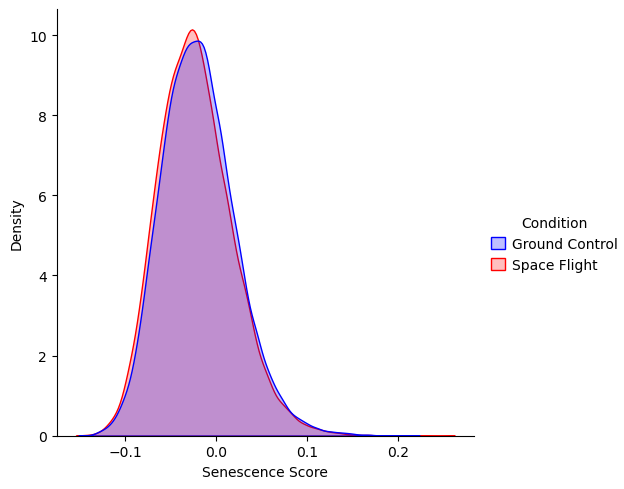

In [16]:
scores = self.rna.obs[[col_batch] + [
    f"score_{x}" for x in sen_metrics]].set_index(
        col_batch, append=True)
scores = scores.rename_axis("Metric", axis=1).stack().to_frame(
    "Senescence Score").reset_index()
sns.displot(scores, kind="kde", cut=0, fill=True, common_norm=False,
            x="Senescence Score", hue=col_batch, palette=palette[col_batch])

## Scores

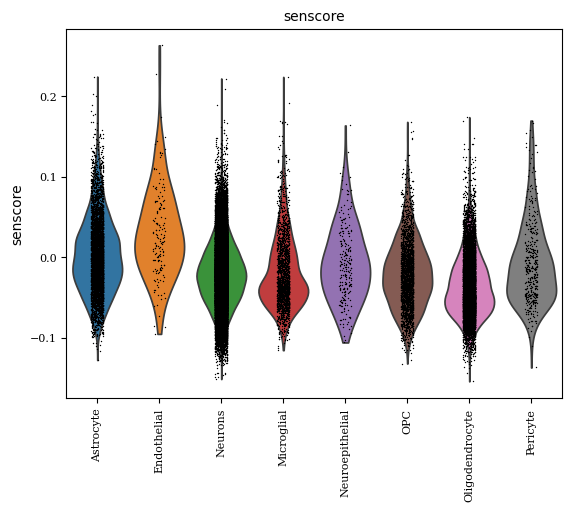



***Plotting group Neurons (0.0%)...


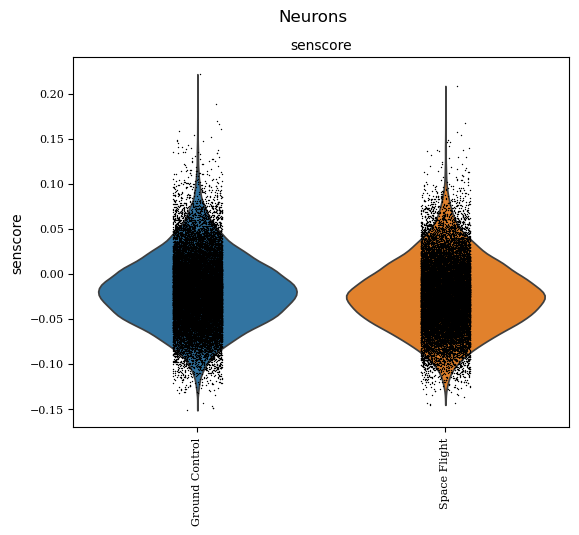



***Plotting group Astrocyte (12.5%)...


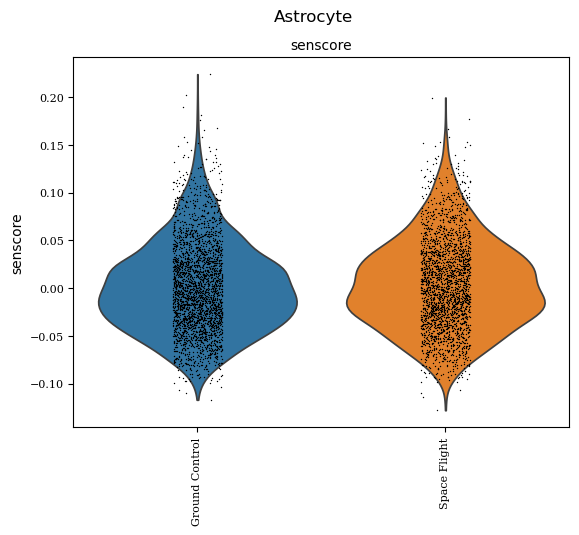



***Plotting group OPC (25.0%)...


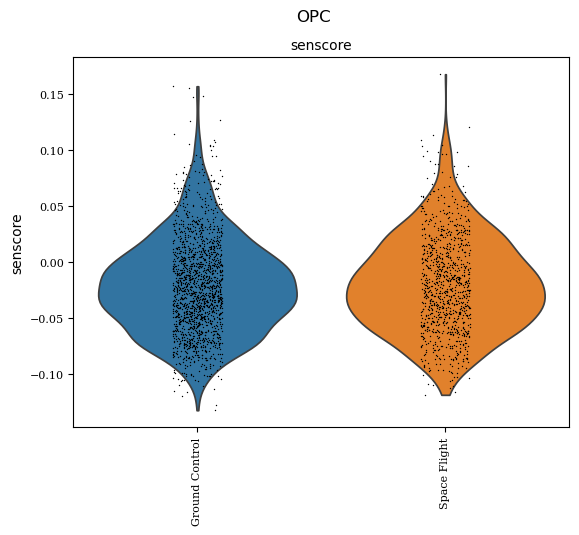



***Plotting group Oligodendrocyte (37.5%)...


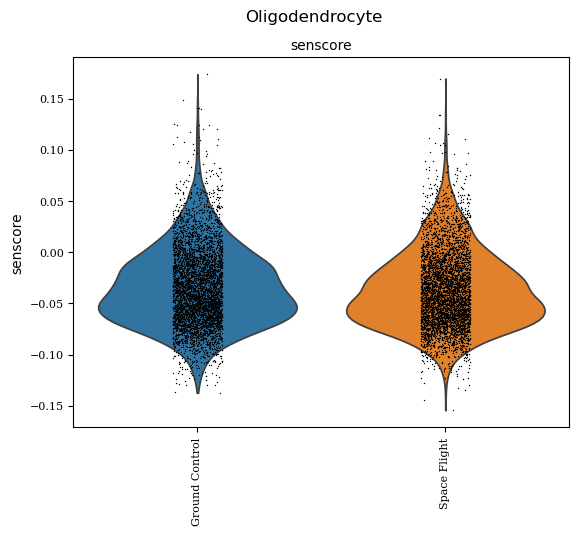



***Plotting group Microglial (50.0%)...


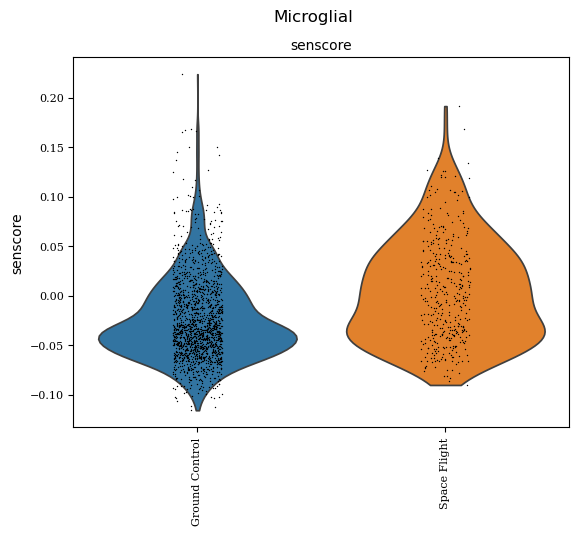



***Plotting group Pericyte (62.5%)...


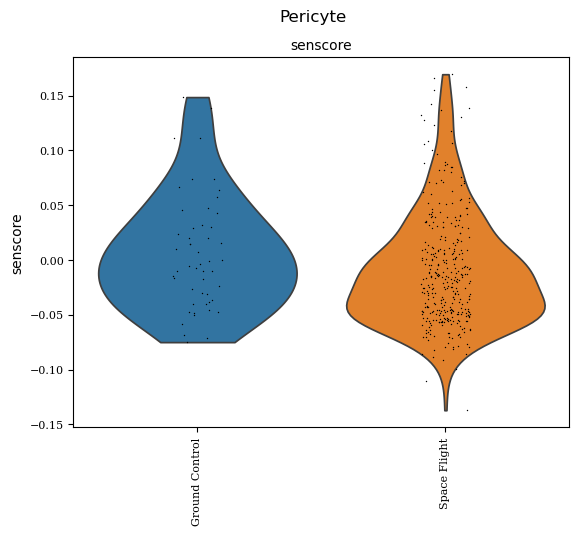



***Plotting group Endothelial (75.0%)...


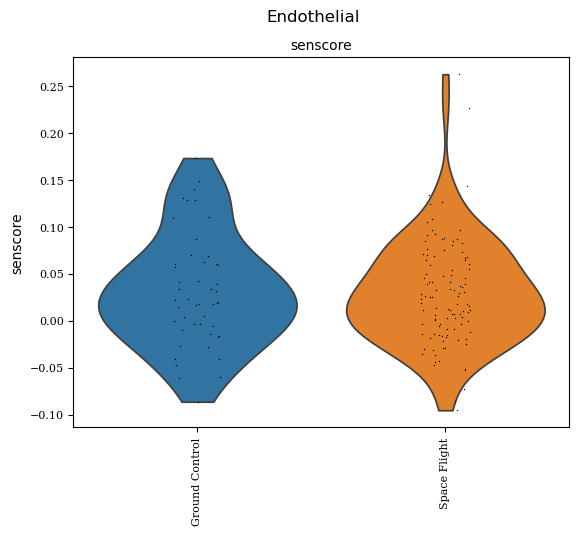



***Plotting group Neuroepithelial (87.5%)...


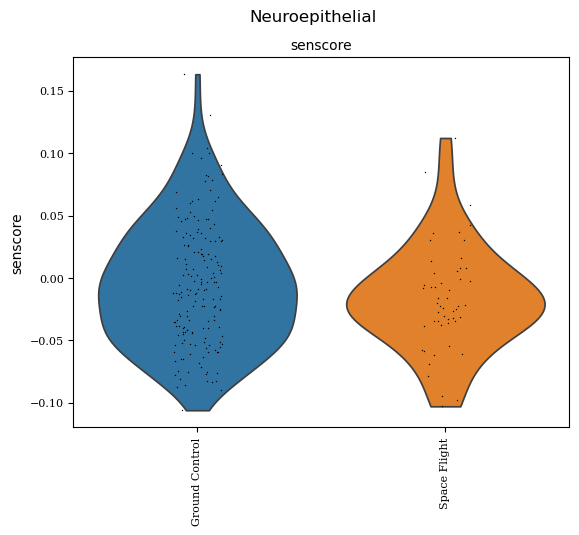

ValueError: The palette dictionary is missing keys: {'18 -19 Weeks'}

In [17]:
# UMAP with Senescence Scores
bnds = self.rna.obs["senscore"].describe(percentiles=[0.75, 0.99])
# _ = self.plot(kind="umap", genes=["senscore", col_celltype], umap=dict(
#     palette=None, color_map="Reds", vmin=bnds["75%"], vmax=bnds["99%"]))

# Violin Plot of Senescence Scores
_ = self.plot(kind="violin", genes=["senscore"], common_norm=False,
              col_celltype=col_celltype, rotation=90)
_ = self.plot(kind="violin", genes=["senscore"], common_norm=False,
              by_group=col_celltype, col_wrap=1,
              col_celltype=col_batch, rotation=90)

# KDEs
fig_sen_kde = {}
for x in [col_age, col_condition, col_batch]:
    fig_sen_kde[x] = sns.displot(self.rna.obs, hue=x, x="senscore",
                                 palette=palette[x], kind="kde",
                                 cut=0, common_norm=False, fill=True)

# Overall (All Cell Types)
fig_sen_overall = sns.catplot(self.rna.obs, x=col_condition,
                              hue=col_age, y="senscore",
                              palette=palette[col_age],
                              kind="violin")
fig_sen_overall_2 = sns.catplot(self.rna.obs, x=col_age, hue=col_condition,
                                palette=palette[col_condition],
                                y="senscore", kind="violin")

# By Cell Type
fig_sen_rc = sns.catplot(self.rna.obs, col=col_celltype, y="senscore",
                         palette=palette[col_condition],
                         hue=col_condition, x=col_age, kind="violin",
                         height=10, aspect=2, col_wrap=3)
fig_sen = sns.catplot(self.rna.obs, x=col_celltype, y="senscore",
                      palette=palette[col_batch],
                      hue=col_batch, kind="box", height=10, aspect=2)
for a in fig_sen.axes.flatten():
    a.tick_params(axis="x", labelrotation=90)
fig_sen_2 = sns.catplot(self.rna.obs, x=col_celltype, y="senscore",
                        col=col_age, hue=col_condition,
                        palette=palette[col_condition],
                        kind="box", height=10, aspect=2)
for a in fig_sen_2.axes.flatten():
    a.tick_params(axis="x", labelrotation=90)
fig_sen_3 = sns.catplot(self.rna.obs, x=col_celltype, y="senscore",
                        col=col_condition, hue=col_age,
                        palette=palette[col_age],
                        kind="box", height=10, aspect=2)
for a in fig_sen_3.axes.flatten():
    a.tick_params(axis="x", labelrotation=90)

## Burden 

Group by sample and cell type and get percentage of senescent cells



                 min  25%  50%  75%    max
Condition                                
Ground Control  0.0  0.2  0.9  4.5  100.0
Space Flight    0.0  0.2  1.0  5.6   50.0


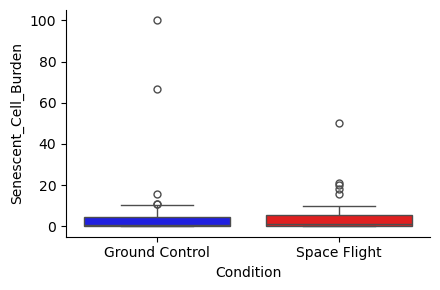

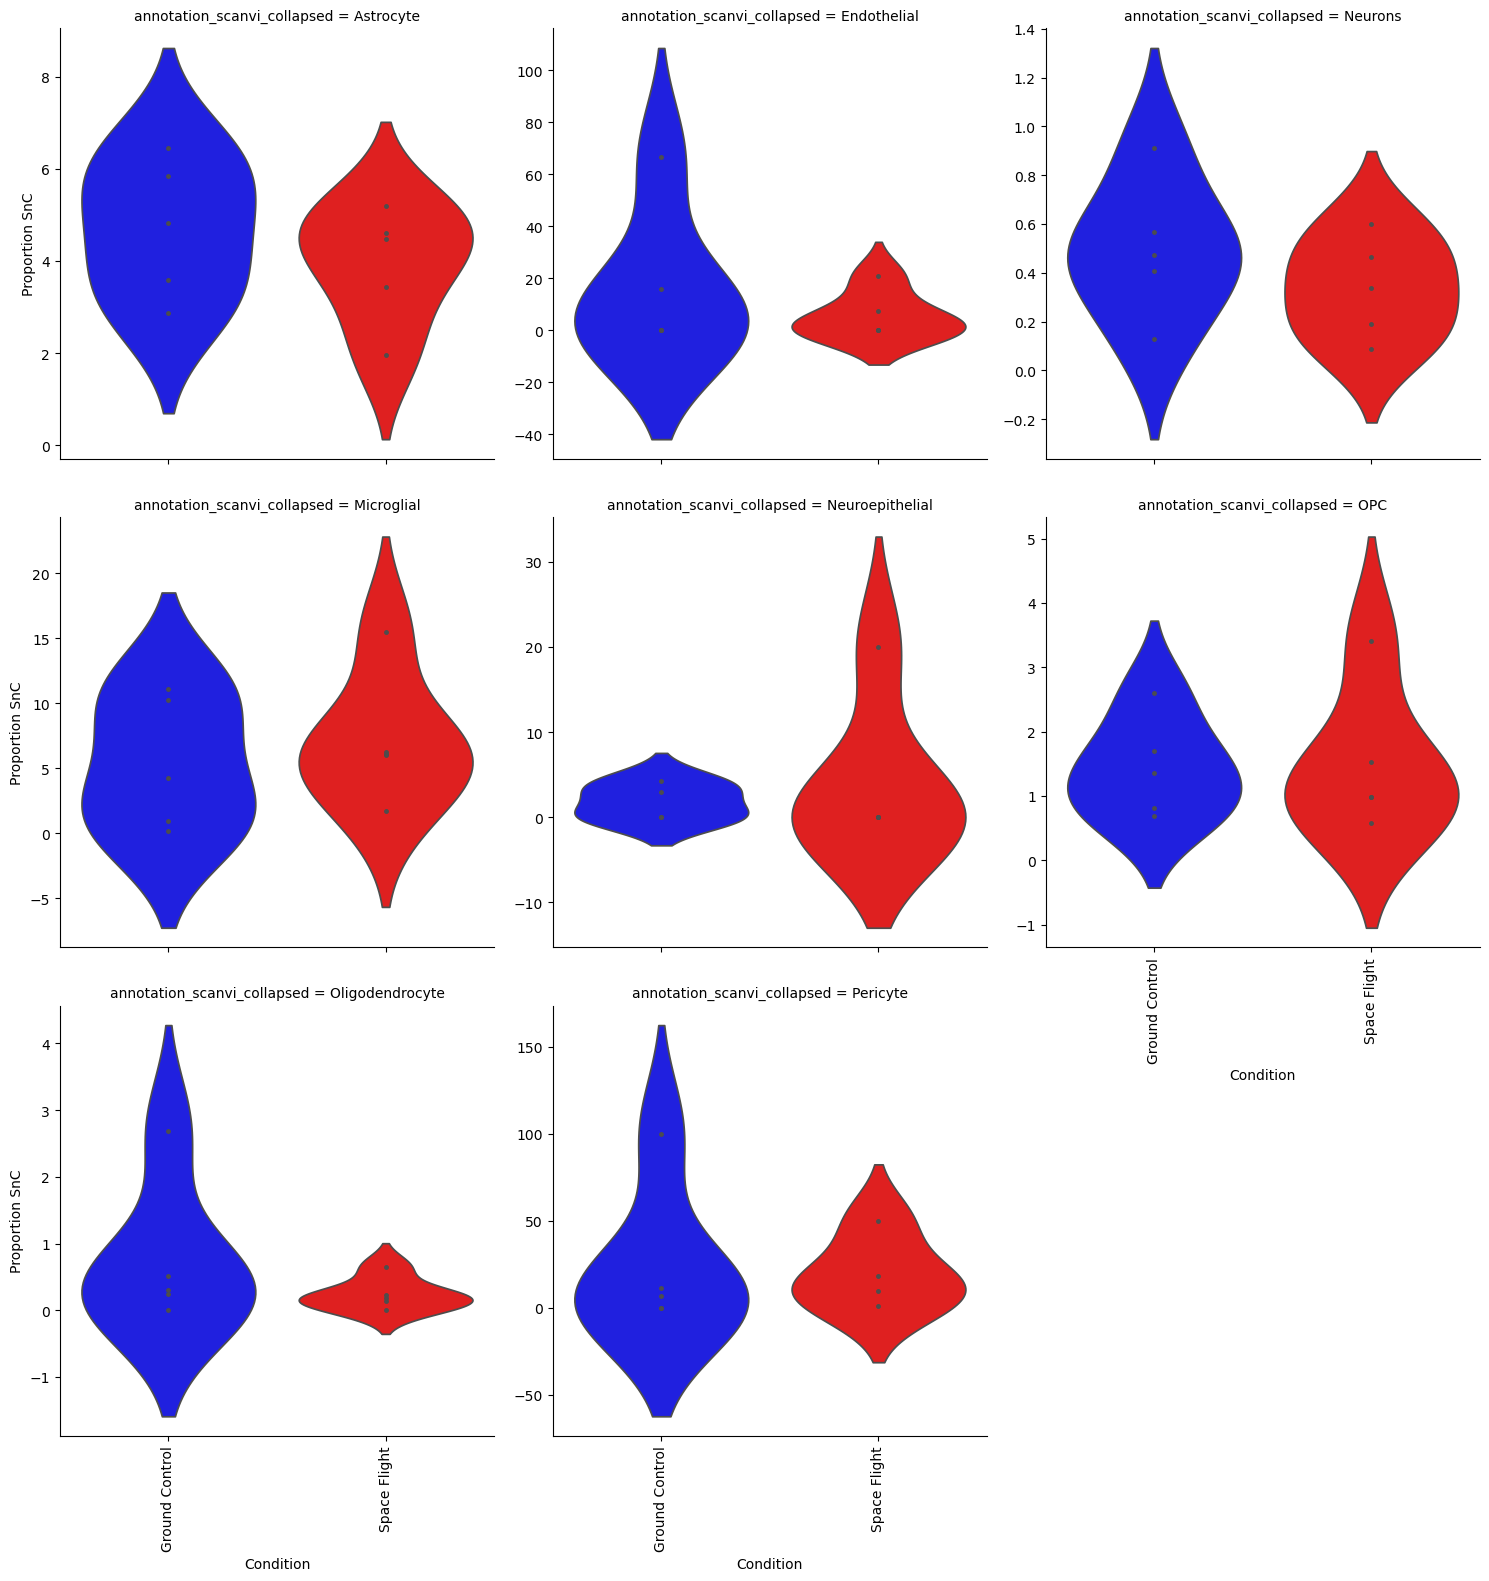

In [22]:
grps = [col_sample, col_celltype, col_condition]
dff = self.rna.obs[grps + ["Senescent_Cell"]].groupby(grps).apply(
    lambda x: x["Senescent_Cell"].mean(), include_groups=False
    ).to_frame("Senescent_Cell_Burden") * 100
# kws_plot = dict(kind="violin", split=False, , common_norm=True)
kws_plot = dict(kind="box", errorbar=("ci", 95))

sns.catplot(y="Senescent_Cell_Burden", x=col_condition, **kws_plot,
            palette=palette[col_condition],
            hue=col_condition, data=dff, height=3, aspect=1.5)

props_snc = self.rna.obs.groupby([col_celltype, col_batch, col_sample]).apply(
    lambda x: 100 * np.mean(x["Senescent_Cell"]), include_groups=False)
fig = sns.catplot(data=props_snc.to_frame("Proportion SnC"),
                  y="Proportion SnC", hue=col_batch, x=col_batch,
                  col=col_celltype, col_wrap=3, kind="violin",
                  palette=palette[col_batch], inner="point",
                  sharey=False, common_norm=False)
for a in fig.axes.flatten():
    a.tick_params(axis="x", labelrotation=90)

# props_snc = self.rna.obs.groupby([
#     col_celltype, col_batch, col_sample]).apply(
#         lambda x: 100 * np.mean(x[f"Senescent_Cell_{use_metric}_{p_h}"]),
#         include_groups=False)
# fig = sns.catplot(data=props_snc.to_frame("Proportion SnC"),
#                   y="Proportion SnC", hue=col_batch, x=col_batch,
#                   col=col_celltype, col_wrap=3, kind="violin",
#                   palette=palette[col_batch], inner="point",
#                   common_norm=False)
# for a in fig.axes.flatten():
#     a.tick_params(axis="x", labelrotation=90)

print("\n\n", round(dff["Senescent_Cell_Burden"].groupby(
    col_condition).describe()[["min", "25%", "50%", "75%", "max"]], 1))

# Analyze

## Regressions & ANOVAs & MEMs

In [ ]:
r_dff = polars.DataFrame(dff.reset_index())  # pymer-compatible aggregated df
r_rna = polars.DataFrame(self.rna.obs.rename({
    col_celltype: "CT_"}, axis=1).copy())  # pymer-compatible cell-level df
lvls = ["key_control", "key_treatment"]
factors = {col_condition: [keys[col_condition][i] for i in lvls],
           "CT_": [ref_ct] + [i for i in self.rna.obs[
               col_celltype].unique() if i != ref_ct]}

### Scores

##### Cell Type Random Effects

In [26]:
model_ca_mlm_iii = lmer(
    f"senscore ~ {col_condition} + (1 | {col_sample})"
    f" + (1 + {col_condition} | CT_)",
    data=r_rna)  # set up model
model_ca_mlm_iii.set_factors(factors)
model_ca_mlm_iii.set_transforms({"senscore": "zscore"})
model_ca_mlm_iii.anova(summary=True).show()
model_ca_mlm_iii.summary().show()

R messages: 
Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 62326' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 62326)' or larger];
but be warned that this may result in large computation time and memory use.

R messages: 
Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 62326' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 62326)' or larger];
but be warned that this may result in large computation time and memory use.



ANOVA (Type III tests) 
 
 
 model term 
 df1 
 df2 
 F_ratio 
 Chisq 
 p_value 
 
 
 
 
 
 Condition 
 1.000 
 inf 
 0.032 
 0.032 
 0.8584 
 
 
 
 
 
 
 Signif. codes: 0 *** 0.001 ** 0.01 * 0.05 . 0.1

Formula: lmer(senscore~Condition+(1|sample)+(1+Condition|CT_)) 
 
 
 Number of observations: 62326 
Confidence intervals: parametric 
--------------------- 
Log-likelihood: -86411 
AIC: 172836 | BIC: 172900 
Residual error: 0.967 
 
 
 Random Effects: 
 
 Estimate 
 SE 
 CI-low 
 CI-high 
 T-stat 
 DF 
 p 
 
 
 
 
 
 sample-sd 
 (Intercept) 
 0.096 
 
 
 
 
 
 
 
 
 
 CT_-sd 
 (Intercept) 
 0.520 
 
 
 
 
 
 
 
 
 
 CT_-sd 
 ConditionSpace Flight 
 0.314 
 
 
 
 
 
 
 
 
 
 CT_-cor 
 (Intercept) 
 −0.289 
 
 
 
 
 
 
 
 
 
 Residual-sd 
 Observation 
 0.967 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 Fixed Effects: 
 
 
 
 
 
 
 
 
 
 
 
 
 (Intercept) 
 0.303 
 0.190 
 −0.142 
 0.749 
 1.594 
 7.383 
 0.1528 
 
 
 
 
 ConditionSpace Flight 
 0.023 
 0.131 
 −0.266 
 0.312 
 0.178 
 10.575 
 0.8618 
 
 
 
 
 
 
 Signif. codes: 0 *** 0.001 ** 0.01 * 0.05 . 0.1

#### Cell Type as Moderator

In [32]:
# Age + Condition * Cell Type
model_cac_mlm_i2 = lmer(
    f"senscore ~  Spaceflight * CT_ + "
    f"(1 | {col_sample})", data=r_rna)  # set up model
model_cac_mlm_i2.set_transforms({"senscore": "zscore"})
model_cac_mlm_i2.set_factors(factors)
model_cac_mlm_i2.anova(summary=True).show()
model_cac_mlm_i2.summary().show() # GLM version of results

R messages: 
Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 62326' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 62326)' or larger];
but be warned that this may result in large computation time and memory use.

R messages: 
Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 62326' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 62326)' or larger];
but be warned that this may result in large computation time and memory use.



ANOVA (Type III tests) 
 
 
 model term 
 df1 
 df2 
 F_ratio 
 Chisq 
 p_value 
 
 
 
 
 
 Spaceflight 
 1.000 
 inf 
 0.004 
 0.004 
 0.9468 
 
 
 
 CT_ 
 7.000 
 inf 
 492.541 
 3,447.787 
 
 *** 
 
 
 Spaceflight:CT_ 
 7.000 
 inf 
 37.774 
 264.418 
 <.001 
 *** 
 
 
 
 
 
 Signif. codes: 0 *** 0.001 ** 0.01 * 0.05 . 0.1

Formula: lmer(senscore~Spaceflight*CT_+(1|sample)) 
 
 
 Number of observations: 62326 
Confidence intervals: parametric 
--------------------- 
Log-likelihood: -86402 
AIC: 172840 | BIC: 173002 
Residual error: 0.967 
 
 
 Random Effects: 
 
 Estimate 
 SE 
 CI-low 
 CI-high 
 T-stat 
 DF 
 p 
 
 
 
 
 
 sample-sd 
 (Intercept) 
 0.096 
 
 
 
 
 
 
 
 
 
 Residual-sd 
 Observation 
 0.967 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 Fixed Effects: 
 
 
 
 
 
 
 
 
 
 
 
 
 (Intercept) 
 0.050 
 0.043 
 −0.049 
 0.150 
 1.164 
 8.177 
 0.2774 
 
 
 
 
 Spaceflight 
 −0.094 
 0.061 
 −0.235 
 0.046 
 −1.539 
 8.214 
 0.1614 
 
 
 
 
 CT_Astrocyte 
 0.474 
 0.019 
 0.436 
 0.512 
 24.341 
 62,303.925 
 <.001 
 *** 
 
 
 
 CT_OPC 
 −0.072 
 0.025 
 −0.121 
 −0.023 
 −2.892 
 62,289.295 
 0.003825 
 ** 
 
 
 
 CT_Oligodendrocyte 
 −0.376 
 0.015 
 −0.406 
 −0.346 
 −24.331 
 62,309.281 
 <.001 
 *** 
 
 
 
 CT_Microglial 
 −0.100 
 0.025 
 −0.150 
 −0.050 
 −3.954 
 61,966.244 
 <.001 
 *** 
 
 
 
 CT_Pericyte 
 0.618 
 0.136 
 0.351 
 0.884 
 4.546 
 62,309.802 
 <.001 
 *** 
 
 
 
 CT_Endothelial 
 1.318 
 0.140 
 1.043 
 1.592 
 9.414 
 62,306.853 
 <.001 
 *** 
 
 
 
 CT_Neuroepithelial 
 0.285 
 0.073 
 0.142 
 0.428 
 3.897 
 62,306.408 
 <.001 
 *** 
 
 
 
 Spaceflight:CT_Astrocyte 
 0.197 
 0.029 
 0.141 
 0.253 
 6.904 
 62,306.178 
 <.001 
 *** 
 
 
 
 Spaceflight:CT_OPC 
 0.165 
 0.041 
 0.086 
 0.245 
 4.079 
 62,310.000 
 <.001 
 *** 
 
 
 
 Spaceflight:CT_Oligodendrocyte 
 0.059 
 0.022 
 0.015 
 0.102 
 2.662 
 62,309.056 
 0.007761 
 ** 
 
 
 
 Spaceflight:CT_Microglial 
 0.799 
 0.055 
 0.691 
 0.906 
 14.526 
 62,294.251 
 <.001 
 *** 
 
 
 
 Spaceflight:CT_Pericyte 
 −0.284 
 0.146 
 −0.569 
 0.002 
 −1.946 
 62,305.891 
 0.05167 
 . 
 
 
 
 Spaceflight:CT_Endothelial 
 0.050 
 0.168 
 −0.279 
 0.380 
 0.299 
 62,306.796 
 0.7647 
 
 
 
 
 Spaceflight:CT_Neuroepithelial 
 −0.194 
 0.153 
 −0.494 
 0.106 
 −1.266 
 62,304.431 
 0.2054 
 
 
 
 
 
 
 Signif. codes: 0 *** 0.001 ** 0.01 * 0.05 . 0.1

### Binary Snc/Not

Multilevel Logistic Regression

#### Cell Type Random Effects

In [29]:
glmmod = {}
for x in ["1", f"1 + Spaceflight"]:
    sep = "|" if x == "1" else "||"
    fff = str(f"Senescent_Cell ~ Spaceflight"
              f" + (1 | {col_sample}) + ({x} {sep} CT_)")
    glmmod[x] = glmer(fff, data=r_rna, family="binomial")
    glmmod[x].set_factors(factors)
    # glmmod[x].set_factors(factors)
    glmmod[x].fit(exponentiate=True, ncpus=ncpus)  # estimates => odds
    # print(glmmod[x].emmeans(col_condition))
    # print(glmmod[x].emmeans(col_age))
    glmmod[x].summary().show()
    # print(glmmod[x].ranef["CT_"])
compare(*[glmmod[x] for x in glmmod])

# Plot
# grid = sns.FacetGrid(self.rna.obs, col=col_age, hue=col_condition)
# grid.map(sns.countplot, "Senescent_Cell", order=[False, True])
# grid.add_legend()
# grid.set_xlabels("")
# grid.set_xticklabels(["Not SnC", "Snc"])
# sns.despine()
# fig = plt.figure(figsize=(10, 2))
# g_s = fig.add_gridspec(1, 2, width_ratios=[1, 3])
# left, right = fig.add_subplot(g_s[0]), fig.add_subplot(g_s[1])
# left = sns.kdeplot(x="resid", data=glmmod.data, ax=left)
# left.set(xlabel="Residuals", title="Error Distribution")
# right.stem(glmmod.data["cooksd"], basefmt=" ", label="Cook's Distance")
# right.set(xlabel="Row Number", ylabel="Cook's Distance",
#           title="Influential Observations",
#           xticks=range(glmmod.data.height))
# sns.despine()

Formula: glmer(Senescent_Cell~Spaceflight+(1|sample)+(1|CT_)) 
 
 
 Family: binomial (link: default ) 
Number of observations: 62326 
Confidence intervals: parametric 
--------------------- 
Log-likelihood: -3018 
AIC: 6045 | BIC: 6082 
Residual error: 1.0 
 
 
 Random Effects: 
 
 Estimate 
 CI-low 
 CI-high 
 SE 
 Z-stat 
 df 
 p 
 
 
 
 
 
 sample-sd 
 (Intercept) 
 0.262 
 
 
 
 
 
 
 
 
 
 CT_-sd 
 (Intercept) 
 1.157 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 Fixed Effects: 
 
 
 
 
 
 
 
 
 
 
 
 
 (Intercept) 
 0.023 
 0.010 
 0.051 
 0.009 
 −9.128 
 inf 
 <.001 
 *** 
 
 
 
 Spaceflight 
 0.906 
 0.624 
 1.315 
 0.172 
 −0.519 
 inf 
 0.6038 
 
 
 
 
 
 
 Signif. codes: 0 *** 0.001 ** 0.01 * 0.05 . 0.1

Formula: glmer(Senescent_Cell~Spaceflight+(1|sample)+(1+Spaceflight||CT_)) 
 
 
 Family: binomial (link: default ) 
Number of observations: 62326 
Confidence intervals: parametric 
--------------------- 
Log-likelihood: -3005 
AIC: 6020 | BIC: 6065 
Residual error: 1.0 
 
 
 Random Effects: 
 
 Estimate 
 CI-low 
 CI-high 
 SE 
 Z-stat 
 df 
 p 
 
 
 
 
 
 sample-sd 
 (Intercept) 
 0.262 
 
 
 
 
 
 
 
 
 
 CT_-sd 
 (Intercept) 
 1.147 
 
 
 
 
 
 
 
 
 
 CT_.1-sd 
 Spaceflight 
 0.652 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 Fixed Effects: 
 
 
 
 
 
 
 
 
 
 
 
 
 (Intercept) 
 0.022 
 0.010 
 0.050 
 0.009 
 −9.190 
 inf 
 <.001 
 *** 
 
 
 
 Spaceflight 
 0.972 
 0.519 
 1.820 
 0.311 
 −0.089 
 inf 
 0.9288 
 
 
 
 
 
 
 Signif. codes: 0 *** 0.001 ** 0.01 * 0.05 . 0.1

GT(_tbl_data=shape: (2, 10)
┌─────────────┬─────────────┬──────────────┬──────┬───┬─────┬────────────┬───────┬─────┐
│ AIC         ┆ BIC         ┆ logLik       ┆ npar ┆ … ┆ Df  ┆ Pr(>Chisq) ┆ stars ┆ ids │
│ ---         ┆ ---         ┆ ---          ┆ ---  ┆   ┆ --- ┆ ---        ┆ ---   ┆ --- │
│ f64         ┆ f64         ┆ f64          ┆ i64  ┆   ┆ f64 ┆ str        ┆ str   ┆ i64 │
╞═════════════╪═════════════╪══════════════╪══════╪═══╪═════╪════════════╪═══════╪═════╡
│ 6045.992014 ┆ 6082.15255  ┆ -3018.996007 ┆ 4    ┆ … ┆ 0.0 ┆            ┆       ┆ 1   │
│ 6020.087899 ┆ 6065.288569 ┆ -3005.04395  ┆ 5    ┆ … ┆ 1.0 ┆ <.001      ┆ ***   ┆ 2   │
└─────────────┴─────────────┴──────────────┴──────┴───┴─────┴────────────┴───────┴─────┘, _body=<great_tables._gt_data.Body object at 0x78dbb0d6cf50>, _boxhead=Boxhead([ColInfo(var='ids', type=<ColInfoTypeEnum.stub: 2>, column_label='', column_align='right', column_width=None), ColInfo(var='AIC', type=<ColInfoTypeEnum.default: 1>, column_label='AIC', column_align='right', column_width=None), ColInfo(var='BIC', type=<ColInfoTypeEnum.default: 1>, column_label='BIC', column_align='right', column_width=None), ColInfo(var='logLik', type=<ColInfoTypeEnum.default: 1>, column_label='logLik', column_align='right', column_width=None), ColInfo(var='npar', type=<ColInfoTypeEnum.default: 1>, column_label='npar', column_align='right', column_width=None), ColInfo(var='-2*log(L)', type=<ColInfoTypeEnum.default: 1>, column_label='-2*log(L)', column_align='right', column_width=None), ColInfo(var='Chisq', type=<ColInfoTypeEnum.default: 1>, column_label='Chisq', column_align='right', column_width=None), ColInfo(var='Df', type=<ColInfoTypeEnum.default: 1>, column_label='Df', column_align='right', column_width=None), ColInfo(var='Pr(>Chisq)', type=<ColInfoTypeEnum.default: 1>, column_label='Pr(>Chisq)', column_align='left', column_width=None), ColInfo(var='stars', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x78df8dbaa300>, _spanners=Spanners([]), _heading=Heading(title='Analysis of Deviance Table', subtitle=Md(text='Model 1: glmer(Senescent_Cell~Spaceflight+(1|sample)+(1|CT_))   \nModel 2: glmer(Senescent_Cell~Spaceflight+(1|sample)+(1+Spaceflight||CT_))   \n'), preheader=None), _stubhead=None, _source_notes=[Md(text='Signif. codes: *0 *** 0.001 ** 0.01 * 0.05 . 0.1*')], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x78deb7d36950>, _formats=[<great_tables._gt_data.FormatInfo object at 0x78df8dedd7b0>, <great_tables._gt_data.FormatInfo object at 0x78df8dedf960>], _substitutions=[<great_tables._gt_data.FormatInfo object at 0x78deb591ea30>], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='valu

#### Cell Type as Moderator

In [30]:
# Just SF
fff = str(f"Senescent_Cell ~ Spaceflight * CT_ + "
          "(1 | sample)")
glmmod_ct = glmer(fff, data=r_rna, family="binomial")
glmmod_ct.set_factors(factors)
glmmod_ct.fit(exponentiate=True, ncpus=ncpus)  # estimates => odds
glmmod_ct.summary().show()

Formula: glmer(Senescent_Cell~Spaceflight*CT_+(1|sample)) 
 
 
 Family: binomial (link: default ) 
Number of observations: 62326 
Confidence intervals: parametric 
--------------------- 
Log-likelihood: -2976 
AIC: 5986 | BIC: 6140 
Residual error: 1.0 
 
 
 Random Effects: 
 
 Estimate 
 CI-low 
 CI-high 
 SE 
 Z-stat 
 df 
 p 
 
 
 
 
 
 sample-sd 
 (Intercept) 
 0.236 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 Fixed Effects: 
 
 
 
 
 
 
 
 
 
 
 
 
 (Intercept) 
 0.006 
 0.004 
 0.008 
 0.001 
 −37.035 
 inf 
 <.001 
 *** 
 
 
 
 Spaceflight 
 0.546 
 0.358 
 0.833 
 0.118 
 −2.810 
 inf 
 0.004954 
 ** 
 
 
 
 CT_Astrocyte 
 6.688 
 5.195 
 8.610 
 0.862 
 14.747 
 inf 
 <.001 
 *** 
 
 
 
 CT_OPC 
 1.852 
 1.134 
 3.025 
 0.464 
 2.461 
 inf 
 0.01386 
 * 
 
 
 
 CT_Oligodendrocyte 
 0.876 
 0.576 
 1.333 
 0.188 
 −0.616 
 inf 
 0.5376 
 
 
 
 
 CT_Microglial 
 2.521 
 1.580 
 4.022 
 0.601 
 3.879 
 inf 
 <.001 
 *** 
 
 
 
 CT_Pericyte 
 15.524 
 5.668 
 42.522 
 7.981 
 5.334 
 inf 
 <.001 
 *** 
 
 
 
 CT_Endothelial 
 41.445 
 19.018 
 90.318 
 16.472 
 9.371 
 inf 
 <.001 
 *** 
 
 
 
 CT_Neuroepithelial 
 5.286 
 2.284 
 12.232 
 2.263 
 3.890 
 inf 
 <.001 
 *** 
 
 
 
 Spaceflight:CT_Astrocyte 
 2.044 
 1.369 
 3.052 
 0.418 
 3.494 
 inf 
 <.001 
 *** 
 
 
 
 Spaceflight:CT_OPC 
 2.020 
 0.922 
 4.425 
 0.808 
 1.757 
 inf 
 0.07898 
 . 
 
 
 
 Spaceflight:CT_Oligodendrocyte 
 1.140 
 0.573 
 2.270 
 0.400 
 0.374 
 inf 
 0.7083 
 
 
 
 
 Spaceflight:CT_Microglial 
 8.972 
 4.626 
 17.402 
 3.032 
 6.491 
 inf 
 <.001 
 *** 
 
 
 
 Spaceflight:CT_Pericyte 
 1.123 
 0.352 
 3.580 
 0.664 
 0.196 
 inf 
 0.8447 
 
 
 
 
 Spaceflight:CT_Endothelial 
 0.884 
 0.312 
 2.502 
 0.469 
 −0.232 
 inf 
 0.8163 
 
 
 
 
 Spaceflight:CT_Neuroepithelial 
 0.917 
 0.077 
 10.928 
 1.160 
 −0.068 
 inf 
 0.9456 
 
 
 
 
 
 
 Signif. codes: 0 *** 0.001 ** 0.01 * 0.05 . 0.1

### Burden (Percent SnC)

ANOVA: Percent SnCs across (a) Condition x Age and (b) Condition x Age x Cell Type

In [31]:
# Age + Condition
model_1 = lm(
    f"Senescent_Cell_Burden ~ {col_condition}", data=r_dff)
model_1.set_factors(factors)
model_1.anova(summary=True).show()
model_1.summary().show()

# Age + Condition +  Cell Type
model_2 = lm(
    f"Senescent_Cell_Burden ~ {col_condition} + {col_celltype}",
    data=r_dff)
model_2.set_factors(factors)
model_2.anova(summary=True).show()
model_2.summary().show()

# Age + Condition * Cell Type
model_3 = lm(
    f"Senescent_Cell_Burden ~ {col_condition} * {col_celltype}",
    data=r_dff)
model_3.set_factors(factors)
model_3.anova(summary=True).show()

# # Age * Condition * Cell Type
# model_4 = lm(
#     f"Senescent_Cell_Burden ~ {col_age} * {col_condition} * {col_celltype}",
#     data=r_dff)
# model_4.set_factors(factors)
# model_4.anova(summary=True).show()
# model_4.summary().show()

# Compare
# compare(model_1, model_2, model_3, model_4).show()
for x in [model_1, model_2, model_3]:
    x.summary().show()
compare(model_1, model_2, model_3).show()

ColumnNotFoundError: CT_

Resolved plan until failure:

	---> FAILED HERE RESOLVING 'sink' <---
DF ["sample", "annotation_scanvi_collapsed", "Condition", "Senescent_Cell_Burden"]; PROJECT */4 COLUMNS

### Just Age as Predictor

In [ ]:
# model_cac_mlm_i3_a = lmer(
#     f"senscore ~  {col_age} * {col_celltype} + (1 | {col_sample})",
#     data=r_rna)  # set up model
# model_cac_mlm_i3_a.set_factors(factors)
# model_cac_mlm_i3_a.set_transforms({"senscore": "zscore"})
# model_cac_mlm_i3_a.fit()
# model_cac_mlm_i3_a.summary().show()

# fff = str(f"Senescent_Cell ~ Aged * {col_celltype} + "
#           "(1 | sample)")
# glmmod_ct2a = glmer(fff, data=r_rna, family="binomial")
# glmmod_ct2a.fit(exponentiate=True, ncpus=ncpus)  # estimates => odds
# glmmod_ct2a.summary().show()

### Lower SnC Threshold

In [ ]:
# Column for Lower Threshold Classification
chp = f"Senescent_Cell_{use_metric}_{p_h}"  # column name

# Cell Type Random Effects
fff = str(f"{chp} ~ Aged * Spaceflight"
          f" + (1 | {col_sample}) + (1 + Spaceflight + Aged || CT_)")
glmmod_lenient_thresh = glmer(fff, data=r_rna, family="binomial")
glmmod_lenient_thresh.fit(exponentiate=True, ncpus=ncpus)  # => odds
glmmod_lenient_thresh.summary().show()

# Cell Type as Moderator
fff = str(f"{chp} ~ Aged * Spaceflight * CT_ + (1 | {col_sample})")
glmmod_lenient_thresh_ct = glmer(fff, data=r_rna, family="binomial")
glmmod_lenient_thresh_ct.fit(exponentiate=True, ncpus=ncpus)  # => odds
glmmod_lenient_thresh_ct.summary().show()

## Perturbation Distance

In [ ]:
print(f"\n\n{'=' * 80}\nOverall Distance\n{'=' * 80}\n\n")
df_distance, figs_distance = scflow.ax.analyze_perturbation_distance(
    self.rna, col_condition=[col_age, col_condition, col_batch])

print(f"\n\n{'=' * 80}\nJust Senescence Genes\n{'=' * 80}\n\n")
df_distance_snc, figs_distance_snc = scflow.ax.analyze_perturbation_distance(
    self.rna[:, genes], col_condition=[
        col_age, col_condition, col_batch])

## Composition Analysis

### Cell Type

In [ ]:
# print(f"\n\n{'=' * 80}\nOverall Sample\n{'=' * 80}\n\n")
# out_ctc = scflow.ax.analyze_composition(
#     self.rna, col_celltype, col_batch, col_sample=col_sample,
#     palette=palette[col_batch],
#     formula=None, key_modality="coda", reference_cell_type="automatic",
#     absence_threshold=0.1, est_fdr=0.1, level_order=[keys[
#         col_batch]["key_control"]] + keys[col_batch]["key_treatment"])
# plt.show()

# print(f"\n\n{'=' * 80}\nAged Subset\n{'=' * 80}\n\n")
# out_ctc_sf = scflow.ax.analyze_composition(
#     self.rna[self.rna.obs[col_age] != keys[col_age]["key_control"]],
#     col_celltype, col_condition, col_sample=col_sample,
#     formula=None, key_modality="coda", reference_cell_type="automatic",
#     absence_threshold=0.1, est_fdr=0.1, level_order=[keys[col_condition][
#         "key_control"]] + [keys[col_condition]["key_treatment"]])

### Senescent Cells

#### Tree-Aggregated

In [ ]:
# Setup
# col_celltype_hierarchy = [
#     f"{col_celltype}_hierarchical", "SnC_hierarchy"]
col_celltype_hierarchy = [
    "Senescent_Cell", f"{col_celltype}_hierarchical", "SnC_hierarchy",
    "Senescent_Cell_Label_by_Type"]
# col_celltype_hierarchy = [
#     "Senescent_Cell_Label", f"SnC_hierarchy",
#     "Senescent_Cell_Label_by_Type"]
ref_celltype = self.rna.obs[col_celltype_hierarchy[-1]].value_counts(
    ).index.values[0]
form_c = " + ".join([col_condition, col_age]) + " + " + " * ".join([
    col_condition, col_age])

# By SF vs. GC (No Age)
_ = scflow.ax.analyze_composition_tree(
    self.rna, col_celltype_hierarchy[-1], col_condition,
    col_sample=col_sample, formula=None, seed=0, est_fdr=0.2,
    reference_cell_type=ref_celltype, num_warmup=2000,
    col_celltype_hierarchy=col_celltype_hierarchy)

# By SF & Age
_ = scflow.ax.analyze_composition_tree(
    self.rna, col_celltype_hierarchy[-1], [col_condition, col_age],
    formula=form_c, col_sample=col_sample, seed=0,
    reference_cell_type=ref_celltype, est_fdr=0.2,
    col_celltype_hierarchy=col_celltype_hierarchy)

#### `scCoda`

##### Just by Condition (By Cell Type)

In [ ]:
for x in self.rna.obs[col_celltype].unique():
    r_s, num_samples, num_warmup = 0, 10000, 2000  # defaults
    if "annotation_scanvi" in col_celltype:  # avoid bad acceptance rates
        r_s = 2 if x  == "OPC" else 2323 if x in [
            "Microglial"] else r_s  # different random seed
        if x == "Endothelial":
            r_s, num_samples, num_warmups = 7654321, 14000, 2000
    print(f"Seed = {r_s}; {num_samples} samples; {num_samples} warmup")
    out = scflow.ax.analyze_composition(
        self.rna[self.rna.obs[col_celltype] == x],
        "Senescent_Cell_Label_by_Type", col_condition,
        col_sample=col_sample, formula=None, key_modality="coda",
        full_hmc=False, palette=palette[col_condition], seed=r_s,
        num_samples=10000, num_warmup=2000,
        reference_cell_type=x, absence_threshold=0.1, est_fdr=0.2,
        level_order=[keys[col_condition]["key_control"], keys[
            col_condition]["key_treatment"]])
    plt.show()
    del out

# x = "Endothelial"
# ann = self.rna[self.rna.obs[col_celltype] == x]
# sccoda = pt.tl.Sccoda()
# mdata = sccoda.load(ann, type="cell_level", generate_sample_level=True,
#                     cell_type_identifier="Senescent_Cell_Label_by_Type",
#                     sample_identifier=col_sample, covariate_obs=[col_batch])
# fig = sccoda.plot_boxplots(mdata, feature_name=col_batch, plot_facets=True,
#                            level_order=list(palette[col_batch].keys()),
#                            palette=palette[col_batch], return_fig=True)
# for a in fig.fig.axes:
#     a.tick_params(axis="x", labelrotation=90)

##### By Condition & Age

In [ ]:
print(f"\n\n{'=' * 80}\nBy Cell Type (by Group)\n{'=' * 80}\n\n")
for x in self.rna.obs[col_celltype].unique():
    r_s = 1618
    if "annotation_scanvi" in col_celltype:
        r_s = 32145 if x in ["Neuron"] else 16 if x in [
            "Microglia", "OPC"] else r_s
    out = scflow.ax.analyze_composition(
        self.rna[self.rna.obs[col_celltype] == x],
        "Senescent_Cell_Label_by_Type", col_batch, col_sample=col_sample,
        formula=None, key_modality="coda", full_hmc=False,
        palette=palette[col_batch], seed=r_s,
        num_samples=10000, num_warmup=2000,
        reference_cell_type=x, absence_threshold=0.1, est_fdr=0.2,
        level_order=[keys[col_batch]["key_control"]] + keys[
            col_batch]["key_treatment"])
    plt.show()
    del out

##### Lower SnC Threshold

In [ ]:
%time

chp = f"Senescent_Cell_Label_by_Type_{use_metric}_{p_h}"  # column name
print("Cross-Tabs of Cell Counts in SnC Classifications "
      f"with Top {percentile}% Threshold versus Top {p_h}%")
print(self.rna.obs[["Senescent_Cell_Label_by_Type", chp]].value_counts(
    ).sort_index(), "\n\n")  # cross-tabs of higher vs. lower SnC threshold
# print(self.rna.obs[["Senescent_Cell_Label_by_Type", chp, col_batch]].groupby(
#     col_batch).value_counts().unstack(0).replace(0, np.nan).dropna(
#         how="all", axis=0).astype(int).sort_index())  # cross-tabs by group
for x in self.rna.obs[col_celltype].unique():
    r_s = 1618
    if "annotation_scanvi" in col_celltype and x == "Endothelial":
        r_s = 0
    out = scflow.ax.analyze_composition(
        self.rna[self.rna.obs[col_celltype] == x],
        chp, col_condition, col_sample=col_sample,
        formula=None, key_modality="coda", full_hmc=False,
        palette=palette[col_condition], seed=r_s,
        num_samples=10000, num_warmup=2000,
        reference_cell_type=x, absence_threshold=0.1, est_fdr=0.2,
        level_order=[keys[col_condition]["key_control"], keys[
            col_condition]["key_treatment"]])
    plt.show()
    del out

## Differential Gene Expression

Mainly using `edgeR`

### Pseudo-Bulk & Examine Covariates

In [ ]:
pdata = scflow.tl.create_pseudobulk(
    self.rna, [i for i in [col_sample, col_condition, col_age] if i],
    "Senescent_Cell_Label_by_Type", layer="counts", mode="sum")
pdata.layers["counts"] = pdata.X.copy()
sc.pp.normalize_total(pdata, target_sum=1e6)
sc.pp.log1p(pdata)
sc.pp.pca(pdata)
sc.pl.pca(pdata, color=pdata.obs, ncols=1, size=300)

### Overall DEGs by Groups

#### Age

**In older spaceflight mice compared to younger spaceflight mice**
* 9630013a20Rik (CNS myelination and neural tissue regeneration) is downregulated.
* mt-Td is upregulated.

In [ ]:
%matplotlib inline

# Overall
print(f"\n\n{'=' * 80}\nOverall Sample\n{'=' * 80}\n\n")
out_edgr_age = scflow.ax.run_deg_edgr(
    self.rna, col_age, col_covariate=None, formula=None,
    **keys[col_age], log2fc_thresh=0, n_top_vars=25,
    col_celltype=col_celltype, col_sample=col_sample,
    fig_title="Age DEGs: Overall Sample\n\n")

# Ground Control Subset
print(f"\n\n{'=' * 80}\nGround Control Subset\n{'=' * 80}\n\n")
out_edgr_age_gc = scflow.ax.run_deg_edgr(
    self.rna[self.rna.obs[col_condition] == keys[
        col_condition]["key_control"]],
    col_age, col_covariate=None, formula=None,
    **keys[col_age], log2fc_thresh=0, n_top_vars=25,
    col_celltype=col_celltype, col_sample=col_sample,
    fig_title="Age DEGs: Just Ground Control\n\n")

# Space Flight Subset
print(f"\n\n{'=' * 80}\nSpace Flight Subset\n{'=' * 80}\n\n")
out_edgr_age_sf = scflow.ax.run_deg_edgr(
    self.rna[self.rna.obs[col_condition] == keys[
        col_condition]["key_treatment"]],
    col_age, col_covariate=None, formula=None, **keys[col_age],
    log2fc_thresh=0, n_top_vars=25, col_celltype=col_celltype,
    col_sample=col_sample, fig_title="Age DEGs: Just Space Flight\n\n")

#### Condition

```
out_edgr_con_o[0][(out_edgr_con_o[0].adj_p_value < 0.01) & (
    out_edgr_con_o[0].abs_log_fc > 0.5)].sort_values(
        "abs_log_fc", ascending=False)
```

Among the older mice, *Mir6236* was differentially highly expressed in aged spaceflight mice compared to ground control mice (LFC=1.95, adjusted p=2.61e-13 in the overall sample; LFC=2.11, adjusted p=0.000015 in the aged subset). Suppression of this gene has been linked to neuronal morphogenesis (https://pubs.acs.org/doi/abs/10.1021/acsabm.0c01389) and therefore may represent a candidate intervention target. 

*Il31ra*, which has been linked to neuroinflammation (https://advanced.onlinelibrary.wiley.com/doi/pdfdirect/10.1002/advs.202409086), was also more highly expressed in spaceflight mice compared to ground control mice (LFC=1.52, adjusted p<0.001 in the overall sample; LFC=1.53, adjusted p<0.001 in the aged subset).

*UBA52*, also more highly expressed in spaceflight mice (LFC=1.43, adjusted p<0.001 in the overall sample; LFC=1.45, adjusted p<0.001 in the aged subset), may serve a neuroprotective role: It has been shown underexpressed in PD (https://www.mdpi.com/2073-4409/11/23/3770) and plays a role in neuroautophagy (https://www.tandfonline.com/doi/pdf/10.1080/15548627.2024.2395727). Likewise, *Pomp*, a gene associated with oxidative stress resistance and protein clearance [CITATION] was also more highly expressed in spaceflight mice. In contrast to past observations of downregulation of *Uqcr11* in Alheimer's (https://www.benthamdirect.com/content/journals/car/10.2174/1567205014666170505095921), that gene was differentially highly expressed in spaceflight mice (LFC=1.23 aged subset; LFC=1.44 overall; p<0.001); however, *Cmss1*, which has been associated with Alzheimer's in APOE4 mice (https://pmc.ncbi.nlm.nih.gov/articles/PMC8064208/), was also more highly expressed in spaceflight mice.

Genes involved in oxidative phosphorylation and the electron transport chain, including *Atp5e*, *Ndufa12*, and *Uqcr11* were also more highly expressed in spaceflight mice. *Uqcr11* has shown an anti-apoptotic and oxidative stress alleviation role in mice (https://www.mdpi.com/2073-4425/16/5/526).

*Tpt1* and *Rn7sk* were also upregulated in spaceflight mice. *Tpt1*, which is associated with cancer progression, anti-apoptosis, and cell stress response, has been shown to have a potentially bi-directional relationship with cell cycle control gene and canonical senescence marker *TP53* (https://www.tandfonline.com/doi/pdf/10.4161/cc.25404). *Rn7sk* is associated with cellular senescence (https://onlinelibrary.wiley.com/doi/abs/10.1002/jcp.28119) and Alzheimer's (https://www.nature.com/articles/s41598-024-82490-9.pdf).

---

*Pvalb* overall sample (LFC=1.61, p=1.25e-11)

*Trim17*

*Cck*

*Pam16*

---

*Mitochondrial/electron transport chain genes whose upregulation has been linked to Parkinson's disease (https://pmc.ncbi.nlm.nih.gov/articles/PMC10259399/pdf/AMS-19-3-131629.pdf) and/or adaptive responses to neurodegeneration in Alheimer's mouse models (https://journals.sagepub.com/doi/abs/10.1177/13872877251314847), including *mt-Atp6*, *mt-Co1*, *mt-Cytb* *mt-Nd2*, and *mt-Nd5*, *mt-Nd6...pregulation of *mt-Rnr1*, which also showed higher expression in spaceflight aged mice, has been seen in response to ionizing radiation, possibly reflecting increased mitochonrial biogenesis as an adaptive stress response (https://pmc.ncbi.nlm.nih.gov/articles/PMC5555881)** 

In [ ]:
# Overall
print(f"\n\n{'=' * 80}\nOverall Sample\n{'=' * 80}\n\n")
out_edgr_con = scflow.ax.run_deg_edgr(
    self.rna, col_condition, col_covariate=None, formula=None,
    **keys[col_condition], log2fc_thresh=0, n_top_vars=25,
    col_celltype=col_celltype, col_sample=col_sample,
    fig_title=f"{col_condition} DEGs (Overall Sample)\n\n")
out_edgr_con_df = out_edgr_con[0][out_edgr_con[
    0].adj_p_value < 0.001].sort_values("abs_log_fc", ascending=False)
goe = out_edgr_con_df.variable[:10].to_list()
print(out_edgr_con_df.iloc[:min(100, out_edgr_con_df.shape[0])], "\n\n", goe)
plt.show()

# Just Old
print(f"\n\n{'=' * 80}\nAged Subset\n{'=' * 80}\n\n")
out_edgr_con_o = scflow.ax.run_deg_edgr(
    self.rna[self.rna.obs[col_age] == keys[col_age]["key_treatment"]],
    col_condition, col_covariate=None, formula=None,
    **keys[col_condition], log2fc_thresh=0, n_top_vars=25,
    col_celltype=col_celltype, col_sample=col_sample,
    fig_title=f"{col_condition} DEGs (Just Aged)\n\n")
plt.show()
out_edgr_con_o_df = out_edgr_con_o[0][out_edgr_con_o[
    0].adj_p_value < 0.001].sort_values("abs_log_fc", ascending=False)
goes = out_edgr_con_o_df.variable[:10].to_list()
print(out_edgr_con_o_df, "\n\n", goes)
_ = self.plot(
    kind=["violin", "matrix"], col_celltype=col_batch, layer="log1p",
    violin=dict(col_wrap=5, hspace=0.25, rotation=45, figsize=(20, 20)),
    matrix=dict(standard_scale="var"), genes=goes)
out_edgr_old_sf_v_gc = out_edgr_con_o_df[0][(
    out_edgr_con_o_df[0].abs_log_fc > 1) & (
        out_edgr_con_o_df[0].adj_p_value < 0.001)].sort_values(
            "adj_p_value", ascending=True)
out_edgr_old_sf_v_gc = out_edgr_old_sf_v_gc.groupby("contrast").apply(
    lambda x: x.sort_values("adj_p_value", ascending=True).iloc[
        :20]).set_index("variable", append=True).reset_index(
            1, drop=True).rename_axis([col_condition, "variable"])
out_edgr_con_compare = out_edgr_con_o_df.set_index("variable")[[
    "log_fc", "adj_p_value"]].join(out_edgr_con_df.set_index("variable")[[
        "log_fc", "adj_p_value"]], how="inner", lsuffix="_Aged_Subset",
                                   rsuffix="_Overall_Sample")
out_edgr_con_compare

#### Age x Condition

Spaceflight effect (main analysis), can visualize at different ages

*Chchd2* (related to oxidative phosphorylation, cell migration, apoptosis inhibition, COX regulation, stress adaptation, Parkinson's, Lewy Body diseases, and cancer) was more highly expressed in spaceflight mice (and demonstrated a bigger young versus old difference in spaceflight mice).
Spaceflight mice also showed higher expression of several ribosomal proteins (*Rps16*, *Rpl31*, *Rpl17*, *Rpl9*, *Rpl15*, *Rps15a*, *Rpl19*, *Rps7*, *Rps23*, *Rpl37*, *Rps3a1*, *Rpl29*, *Rps15*, *Rps14*).

*Ndufa4* was also more highly expressed (implicated in cancer and mitochondrial dysfunction, part of the cytochrome c oxidase complex which drives oxidative phosphorylation, adaptation to hypoxia via downregulation of oxygen consumption and suppression of mitochondrial ROS production https://www.cell.com/cell-metabolism/fulltext/S1550-4131(11)00394-9?mobileUi=0) in spaceflight mice, as were other genes involved in ATP production/the electron transport chain and oxidative phosophorylation, including *Cox7a2*, *Uqcr11*, *Ndufa12*, *Ndufa4*, *Ndufc1*, *Atp5o-1*, *Atp5e*, and *Uqcrh* (which additionally has been implicated in tumor suppression https://aacrjournals.org/cancerres/article/80/16_Supplement/4795/643367).


In [ ]:
# With Single Label for Age x Condition
print(f"\n\n{'=' * 80}\nGroup (Single Factor)\n{'=' * 80}\n\n")
out_edgr_groups = scflow.ax.run_deg_edgr(
    self.rna, col_batch, col_covariate=None, formula=None,
    **keys[col_batch], col_sample=col_sample,
    log2fc_thresh=0, n_top_vars=25, col_celltype=col_celltype)
print(list(out_edgr_groups[0].variable[:25]))
plt.show()
# _ = self.plot(kind="violin", col_celltype=col_batch,
#               genes=list(out_edgr_groups[0].variable[:25]), layer="scaled",
#               violin=dict(col_wrap=4, hspace=1, rotation=45))
out_edgr_batches = out_edgr_groups[0][(out_edgr_groups[0].abs_log_fc > 1) & (
    out_edgr_groups[0].adj_p_value < 0.001)].sort_values(
        "adj_p_value", ascending=True)
out_edgr_batches_top = out_edgr_batches.groupby("contrast").apply(
    lambda x: x.sort_values("adj_p_value", ascending=True).iloc[
        :20]).set_index("variable", append=True).reset_index(
            1, drop=True).rename_axis([col_condition, "variable"])

# With Contrasts (Age & Condition = Separate Factors)
print(f"\n\n{'=' * 80}\nAge * Condition (2-Factor Contrast)\n{'=' * 80}\n\n")
out_edgr_contrasts = scflow.ax.run_deg_edgr(
    self.rna, col_condition, col_covariate=col_age, formula=None,
    **keys[col_condition], log2fc_thresh=0, n_top_vars=24,
    col_celltype=col_celltype, col_sample=col_sample)
_ = self.plot(
    kind=["violin", "matrix"], col_celltype=col_batch,
    genes=out_edgr_contrasts[0][out_edgr_contrasts[
        0].adj_p_value < 0.001].sort_values(
            "abs_log_fc", ascending=False).variable[:10], layer="log1p",
    violin=dict(col_wrap=5, hspace=0.25, rotation=45, figsize=(20, 20)),
    matrix=dict(standard_scale="var"))

# Condition x Age
# Vulnerability of mice who were older at launch to spaceflight stress
out_edgr_contrasts_age = scflow.ax.run_deg_edgr(
    self.rna, col_age, col_covariate=col_condition, formula=None,
    **keys[col_age], log2fc_thresh=0, n_top_vars=24,
    col_celltype=col_celltype, col_sample=col_sample)

#### Senescence Gene Contrasts Results

In [ ]:
# Genes
sen_genes_in_contrasts = list(set(genes).intersection(
    out_edgr_contrasts[0].variable.unique()))  # senescence genes in contrasts
out_edgr_snc = out_edgr_contrasts[0].set_index(
    "variable").loc[sen_genes_in_contrasts]  # contrast results for snc genes
res_snc_contrast = out_edgr_snc[out_edgr_snc.adj_p_value < 0.01]  # p < 0.01
sig_contrast_genes = list(res_snc_contrast.index.values)  # significant genes

# Plots By Groups; Axis by Cell Types
kws = dict(dot=dict(figsize=(10, 5)), heat=dict(figsize=(15, 15)))
_ = self.plot(kind=["matrix", "dot"], genes=sig_contrast_genes,
              standard_scale="obs", col_celltype=col_celltype,
              by_group=col_batch, **kws)

# Plots By Cell Types; Axis by Groups
# kws = dict(dot=dict(figsize=(10, 5)), heat=dict(figsize=(15, 15)),
#            violin=dict(figsize=(30, 20), col_wrap=4, xlabel=None,
#                        rotation=45, hspace=1, top=0.95))
kws = dict(dot=dict(figsize=(10, 5)), heat=dict(figsize=(15, 15)))
_ = self.plot(kind=["matrix", "dot"], genes=sig_contrast_genes,
              standard_scale="obs", col_celltype=col_batch,
              by_group=col_celltype, **kws)

# Results
print(f"\n{'=' * 80}\nSignificant Senescence Gene Contrasts\n{'=' * 80}\n")
print(sig_contrast_genes)
res_snc_contrast

### Snc versus Not (Group=Covariate)

In [ ]:
# Group = Covariate
out_edgr_contrasts_snc = scflow.ax.run_deg_edgr(
    self.rna, "Senescent_Cell_Label",
    # col_covariate=col_batch,
    col_covariate=col_condition,
    formula=None,
    key_treatment="Senescent", key_control="Non-Senescent",
    log2fc_thresh=0, n_top_vars=24, xlabel_rotation=45,
    hspace=0.5, wspace=0.2, top=0.92, legend_loc="upper right",
    col_celltype=col_celltype, col_sample=col_sample)

### SnC versus Not SnC (Group=Subset)

In [ ]:
# Aged Subset
subset_old = self.rna.obs[col_age] == keys[col_age]["key_treatment"]

# Old Ground Control SnCs
print(f"\n\n{'=' * 80}\nGround Control (Aged)\n{'=' * 80}\n\n")
subset_gc = self.rna.obs[col_condition] == keys[
    col_condition]["key_control"]
out_edgr_contrasts_snc_gc = scflow.ax.run_deg_edgr(
    self.rna[subset_gc & subset_old], "Senescent_Cell_Label",
    key_treatment="Senescent", top=0.92,
    key_control="Non-Senescent", log2fc_thresh=0, n_top_vars=24,
    xlabel_rotation=45, hspace=0.5, wspace=0.2, legend_loc="upper right",
    col_celltype=col_celltype, col_sample=col_sample)
if len(self.rna[subset_gc & subset_old].obs[col_batch].unique()) > 1:
    raise ValueError("Check subsetting")
key_1 = self.rna[subset_gc & subset_old].obs[col_batch].unique()[0]

# Old Spaceflight SnCs
print(f"\n\n{'=' * 80}\nSpaceflight (Aged)\n{'=' * 80}\n\n")
subset_sf = self.rna.obs[col_condition] == keys[
    col_condition]["key_treatment"]
out_edgr_contrasts_snc_sf = scflow.ax.run_deg_edgr(
    self.rna[subset_sf & subset_old], "Senescent_Cell_Label",
    key_treatment="Senescent", key_control="Non-Senescent",
    log2fc_thresh=0, n_top_vars=24, xlabel_rotation=45,
    hspace=0.5, wspace=0.2, top=0.92, legend_loc="upper right",
    col_celltype=col_celltype, col_sample=col_sample)
if len(self.rna[subset_sf & subset_old].obs[col_batch].unique()) > 1:
    raise ValueError("Check subsetting")
key_2 = self.rna[subset_sf & subset_old].obs[col_batch].unique()[0]

# Compare
res_snc_gc = out_edgr_contrasts_snc_gc[0][out_edgr_contrasts_snc_gc[
    0].adj_p_value < 0.001].sort_values("adj_p_value").set_index("variable")
res_snc_sf = out_edgr_contrasts_snc_sf[0][out_edgr_contrasts_snc_sf[
    0].adj_p_value < 0.001].sort_values("adj_p_value").set_index("variable")
res_snc_grps = pd.concat([
    res_snc_gc, res_snc_sf], keys=[key_1, key_2], names=[col_condition])
res_snc_grps = res_snc_grps[res_snc_grps.abs_log_fc >= 1]
# top_tx_g_snc = res_snc_grps.loc[keys[col_condition][
#     "key_treatment"]].sort_values("abs_log_fc", ascending=False).index
# print(res_snc_grps.unstack(0).replace(np.nan, "")[[
#     "log_fc", "adj_p_value"]].loc[top_tx_g_snc])
# just_sf = res_snc_grps.loc[keys[col_condition][
#     "key_treatment"]].index.difference(res_snc_grps.loc[keys[
#         col_condition]["key_control"]].index)
# just_gc = res_snc_grps.loc[keys[col_condition][
#     "key_control"]].index.difference(res_snc_grps.loc[keys[
#         col_condition]["key_treatment"]].index)
# print(res_snc_grps.loc[:, just_gc, :].sort_values(
#     "abs_log_fc", ascending=False)[["log_fc", "adj_p_value"]], "\n\n")
# res_snc_grps.loc[:, just_sf, :].sort_values(
#     "abs_log_fc", ascending=False)[["log_fc", "adj_p_value"]]
res_snc_grps.unstack(0).replace(np.nan, "")[["log_fc", "adj_p_value"]]

### Group DEGs (SnC=Subset)

##### All Groups SnCs

>>>Pseudo-bulking data with grouping columns ['sample', 'Condition'] and cell type column annotation_scanvi_collapsed (`mode='sum'`)
	***Creating combined group column with ['sample', 'Condition']
AAATGCCTCGTGCTAG-1_RR10_BRN_GC_WT_G5    RR10_BRN_GC_WT_G5 *** Ground Control
AAGACAAGTGATCAGC-1_RR10_BRN_GC_WT_G5    RR10_BRN_GC_WT_G5 *** Ground Control
AAGTGCAAGGCTGGCT-1_RR10_BRN_GC_WT_G5    RR10_BRN_GC_WT_G5 *** Ground Control
AAGTTTGTCGGCTAGC-1_RR10_BRN_GC_WT_G5    RR10_BRN_GC_WT_G5 *** Ground Control
ACCAAACTCGTTTCCA-1_RR10_BRN_GC_WT_G5    RR10_BRN_GC_WT_G5 *** Ground Control
Name: PBULK_GROUPING, dtype: object
	***Using `pertpy` pseudo-bulking on layer counts...
	***Total count-normalizing pseudobulk data (`target_sum=10000.0`)...
	***Log-transforming pseudo-bulked data...
	***Scaling pseudo-bulked data (`max_value=10`, `zero_center=True`)...
	***Performing PCA on pseudo-bulked data...
	***Swapping back to counts layer...
• Calculating NormFactors
• Estimating Dispersions
• Fitting lin

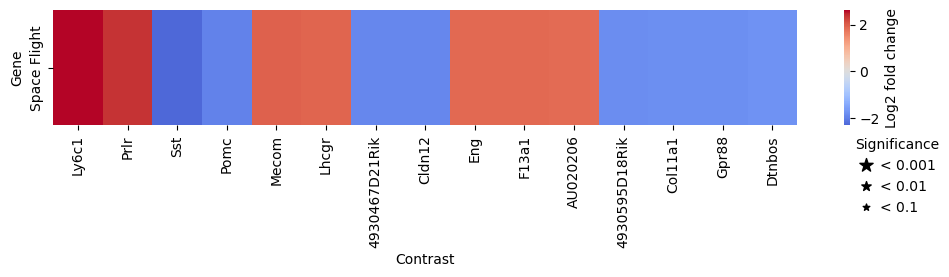

In [33]:
out_edgr_groups_snc = scflow.ax.run_deg_edgr(
    self.rna[(self.rna.obs["Senescent_Cell_Label"] == "Senescent")],
    col_batch, **keys[col_batch], col_sample=col_sample,
    log2fc_thresh=0, n_top_vars=25, col_celltype=col_celltype)
print(list(out_edgr_groups_snc[0].variable[:25]))
out_edgr_batches_snc = out_edgr_groups_snc[0][(
    out_edgr_groups_snc[0].abs_log_fc > 1) & (
        out_edgr_groups_snc[0].adj_p_value < 0.001)].sort_values(
            "adj_p_value", ascending=True)
# out_edgr_batches_snc_top = out_edgr_batches_snc.groupby("contrast").apply(
#     lambda x: x.sort_values("adj_p_value", ascending=True).iloc[
#         :20]).set_index("variable", append=True).reset_index(
#             1, drop=True).rename_axis([col_condition, "variable"])
plt.show()

### More Specific Contrasts (`pyDESeq2`)

#### Group

In [ ]:
# pdata =  scflow.tl.create_pseudobulk(
#     self.rna, [col_sample, col_condition, col_age],
#     col_celltype, layer="counts", mode="sum")
# design = f"~{col_condition} + {col_age} + {col_condition} * {col_age}"
# # edgr = pt.tl.EdgeR(pdata, design=design)
# pds2 = pt.tl.PyDESeq2(adata=pdata, design=design)
# pds2.fit()
# key_control, key_treatment = [keys[col_condition][k] for k in [
#     "key_control", "key_treatment"]]
# key_control_cov, key_treatment_cov = [keys[col_age][k] for k in [
#     "key_control", "key_treatment"]]
# sf_old = {col_condition: key_treatment, col_age: key_treatment_cov}
# sf_yng = {col_condition: key_treatment, col_age: key_control_cov}
# gc_old = {col_condition: key_control, col_age: key_treatment_cov}
# gc_yng = {col_condition: key_control, col_age: key_control_cov}

# # Spaceflight-Specific Age DEGs
# spaceflight_specfic_age_degs = (pds2.cond(**sf_old) - pds2.cond(
#     **sf_yng)) - (pds2.cond(**gc_old) - pds2.cond(**gc_yng))
# interaction_res_df = pds2.test_contrasts(spaceflight_specfic_age_degs)
# pds2.plot_volcano(interaction_res_df, log2fc_thresh=0)

# # Age-Specific Spaceflight DEGs
# age_specfic_sf_degs = (pds2.cond(**sf_old) - pds2.cond(**gc_old)) - (
#     pds2.cond(**sf_yng) - pds2.cond(**gc_yng))
# interaction_res_df2 = pds2.test_contrasts(age_specfic_sf_degs)
# pds2.plot_volcano(interaction_res_df2, log2fc_thresh=0)

# # Old vs. Young Spaceflight
# age_sf_ix = pds2.cond(**sf_old) - pds2.cond(**sf_yng)
# interaction_res_df3 = pds2.test_contrasts(age_sf_ix)
# pds2.plot_volcano(interaction_res_df3, log2fc_thresh=0)

# # Old vs. Young GC
# age_gc_ix = pds2.cond(**gc_old) - pds2.cond(**gc_yng)
# interaction_res_df4 = pds2.test_contrasts(age_gc_ix)
# pds2.plot_volcano(interaction_res_df4, log2fc_thresh=0)

# # SF vs. GC Old
# cond_old_ix = pds2.cond(**sf_old) - pds2.cond(**gc_old)
# interaction_res_df5 = pds2.test_contrasts(cond_old_ix)
# pds2.plot_volcano(interaction_res_df5, log2fc_thresh=0)

# # SF vs. GC Young
# cond_yng_ix = pds2.cond(**sf_yng) - pds2.cond(**gc_yng)
# interaction_res_df6 = pds2.test_contrasts(cond_yng_ix)
# pds2.plot_volcano(interaction_res_df6, log2fc_thresh=0)

# # Compare
# thresh_lfc, thresh_p = 1, 0.001
# sf_deg_res_df_old = interaction_res_df5[(
#     interaction_res_df5.adj_p_value < thresh_p) & (
#         interaction_res_df5.log_fc.abs() >= thresh_lfc)].set_index(
#             "variable")
# sf_deg_res_df_yng = interaction_res_df6[(
#     interaction_res_df6.adj_p_value < thresh_p) & (
#         interaction_res_df6.log_fc.abs() >= thresh_lfc)].set_index(
#             "variable")
# sf_deg_res = pd.concat([sf_deg_res_df_old, sf_deg_res_df_yng],
#                        keys=["Old", "Young"], names=["Age Group"])
# sf_deg_res.loc[:, "log_fc_abs"] = sf_deg_res.log_fc.abs()
# sf_deg_res = sf_deg_res.sort_values("log_fc_abs", ascending=False)[[
#     "log_fc", "adj_p_value"]].unstack(0)
# print("SF DEGs in Both Young & Old: ", sf_deg_res.dropna().index.values)
# print("\n\nSF DEGs in Just Young", list(sf_deg_res_df_yng.index.difference(
#     sf_deg_res_df_old.index)), "\n\n")
# print("SF DEGs in Just Old", list(sf_deg_res_df_old.index.difference(
#     sf_deg_res_df_yng.index)), "\n\n")
# sf_deg_res.replace(np.nan, "")

# # Marker Set Overlap
# print("Both: ", marker_gene_sets.apply(
#     lambda i: set(sf_deg_res.dropna().index).intersection(set(i))).apply(
#         lambda x: x if len(x) > 0 else np.nan).dropna(), "\n\n")
# print("Young: ", marker_gene_sets.apply(
#     lambda i: sf_deg_res_df_yng.index.difference(
#         sf_deg_res_df_old.index).intersection(set(i))).apply(
#         lambda x: x if len(x) > 0 else np.nan).dropna(), "\n\n")
# print("Old: ", marker_gene_sets.apply(
#     lambda i: sf_deg_res_df_old.index.difference(
#         sf_deg_res_df_yng.index).intersection(set(i))).apply(
#         lambda x: x if len(x) > 0 else np.nan).dropna(), "\n\n")

#### SnCs

##### Old

In [ ]:
# Setup
design = (f"~{col_condition} + Senescent_Cell_Label + "
          f"{col_condition} * Senescent_Cell_Label")
pdata2 =  scflow.tl.create_pseudobulk(
    self.rna[self.rna.obs[col_age] == keys[col_age]["key_treatment"]], [
        col_sample, col_condition, "Senescent_Cell_Label"],
    "Senescent_Cell_Label_by_Type", layer="counts", mode="sum")
pds2_snc_yng = pt.tl.PyDESeq2(adata=pdata2, design=design)
pds2_snc_yng.fit()
key_control, key_treatment = [keys[col_condition][k] for k in [
    "key_control", "key_treatment"]]
key_control_cov, key_treatment_cov = "Non-Senescent", "Senescent"
sf_sc = {col_condition: key_treatment,
         "Senescent_Cell_Label": key_treatment_cov}
sf_ns = {col_condition: key_treatment,
         "Senescent_Cell_Label": key_control_cov}
gc_snc = {col_condition: key_control,
          "Senescent_Cell_Label": key_treatment_cov}
gc_ns = {col_condition: key_control, "Senescent_Cell_Label": key_control_cov}

# SnC DEGs
res_df_snc = pds2_snc_yng.test_contrasts(pds2_snc_yng.contrast(
    column="Senescent_Cell_Label", baseline=key_control_cov,
    group_to_compare=key_treatment_cov))
print(res_df_snc[res_df_snc.adj_p_value < 0.001].head(10))
pds2_snc_yng.plot_volcano(res_df_snc, log2fc_thresh=0)

# Spaceflight-Specific SnC DEGs
spaceflight_specfic_snc_degs = (pds2_snc_yng.cond(
    **sf_sc) - pds2_snc_yng.cond(**sf_ns)) - (
        pds2_snc_yng.cond(**gc_snc) - pds2_snc_yng.cond(**gc_ns))
interaction_res_df_snc_sf = pds2_snc_yng.test_contrasts(
    spaceflight_specfic_snc_degs)
pds2_snc_yng.plot_volcano(interaction_res_df_snc_sf, log2fc_thresh=0)

#### SnCs (More Permissive Threshold)

In [ ]:
# Compare Less & More Permissive Thresholds
print("Less & More Permissive SnC Threshold: ", self.rna.obs[[
    "Senescent_Cell_Label", f"Senescent_Cell_Label_{use_metric}_{p_h}"
    ]].value_counts())
sen_lab = f"Senescent_Cell_Label_{use_metric}_{p_h}"

# Setup
design = (f"~{col_condition} + {sen_lab} + "
          f"{col_condition} * {sen_lab}")
pdata2_3 =  scflow.tl.create_pseudobulk(
    self.rna[self.rna.obs[col_age] == keys[col_age]["key_treatment"]], [
        col_sample, col_condition, sen_lab],
    col_celltype, layer="counts", mode="sum")
pds2_snc_old_3 = pt.tl.PyDESeq2(adata=pdata2_3, design=design)
pds2_snc_old_3.fit()
key_control, key_treatment = [keys[col_condition][k] for k in [
    "key_control", "key_treatment"]]
key_control_cov, key_treatment_cov = "Non-Senescent", "Senescent"
sf_sc = {col_condition: key_treatment, sen_lab: key_treatment_cov}
sf_ns = {col_condition: key_treatment, sen_lab: key_control_cov}
gc_snc = {col_condition: key_control, sen_lab: key_treatment_cov}
gc_ns = {col_condition: key_control, sen_lab: key_control_cov}

# SnC DEGs
res_df_snc_3 = pds2_snc_old_3.test_contrasts(pds2_snc_old_3.contrast(
    column=sen_lab, baseline=key_control_cov,
    group_to_compare=key_treatment_cov))
print(res_df_snc_3[res_df_snc_3.adj_p_value < 0.001].head(10))
pds2_snc_old_3.plot_volcano(res_df_snc_3, log2fc_thresh=0)

# Spaceflight-Specific SnC DEGs
spaceflight_specfic_snc_degs_3 = (pds2_snc_old_3.cond(
    **sf_sc) - pds2_snc_old_3.cond(**sf_ns)) - (
        pds2_snc_old_3.cond(**gc_snc) - pds2_snc_old_3.cond(**gc_ns))
interaction_res_df_snc_sf_3 = pds2_snc_old_3.test_contrasts(
    spaceflight_specfic_snc_degs_3)
pds2_snc_old_3.plot_volcano(interaction_res_df_snc_sf_3, log2fc_thresh=0)

# SnC GEX Profiles

## Pathway Analysis

In [34]:
names = gp.get_library_name()
# perts_geo = ["Aging", "Drug", "Disease"]
perts_geo = ["Aging", "Disease"]
other_sets = ["GTEx_Aging_Signatures_2021", f"HDSigDB_{species}_2021",
              "MSigDB_Hallmark_2020",  # "DGIdb_Drug_Targets_2024",
              "MSigDB_Oncogenic_Signatures", "OMIM_Disease",
              # "Reimport pdb;actome_Pathways_2024", "Reactome_2022",
              f"WikiPathways_2024_{species}", f"WikiPathways_2019_{species}"]
other_sets += [i for i in names if "GO_Biological_Process" in i]
gene_sets = dict(zip(["up", "down"], [[
    f"{u}_Perturbations_from_GEO_{i}" for u in perts_geo] + [
        f"Disease_Signatures_from_GEO_{i}_2014"] + other_sets
    for i in ["up", "down"]]))


def fx_replace_string(string):
    """Make short version of pathway terms."""
    string = re.sub("aging:([0-9]+)", "aging", re.sub(
        "([0-9]+) months v ([0-9]+) mo(nths)?", "\\1 v \\2 mo.", re.sub(
            "SRP[0-9]+ ", "", re.sub("GSE[0-9]+ ", "", string))))
    string = re.sub(".*.xlsx.", "", re.sub(
        ".*Supplementary Data ..", "", re.sub(
            "PMID([0-9])+", "", re.sub("([0-9]+) years v ([0-9]+) years",
                                       "\\1 v \\2 yrs.", string))))
    string = re.sub("Expression Of ", "", re.sub(".*.xls", "", re.sub(
        ".*.XLSX", "", re.sub(
            ".*Supplementary Table [0-9]+[-]?", "", string))))
    return string

### Endrichr

In [ ]:
# out_pathway_snc_edgr_contrasts = scflow.ax.run_enrichr(
#     out_edgr_contrasts_snc_all_top,
#     col_grouping=["Comparison", col_celltype],
#     gene_sets=gene_sets,
#     fx_replace_string=fx_replace_string, title="Overall")

### SnC vs. Not

In [ ]:
# res_dc_ulm = scflow.ax.run_decoupler_ulm(
#         self.rna[self.rna.obs["Senescent_Cell_Label"] == "Senescent"],
#         # "Senescent_Cell_Label_by_Type",
#         # "Senescent_Cell_Label",
#         col_condition, col_condition="Senescent_Cell_Label_by_Type",
#         species=species, resource="hallmark",
#         top=0.95, hspace=1, wspace=0.5, figsize=(15, 10))

#### Pathway Set = Progeny

{'Ground Control': ['MAPK', 'EGFR']}
{'Space Flight': ['WNT']}


No significant contrasts for SnC Oligodendrocyte


No significant contrasts for SnC Astrocyte


No significant contrasts for SnC Microglial


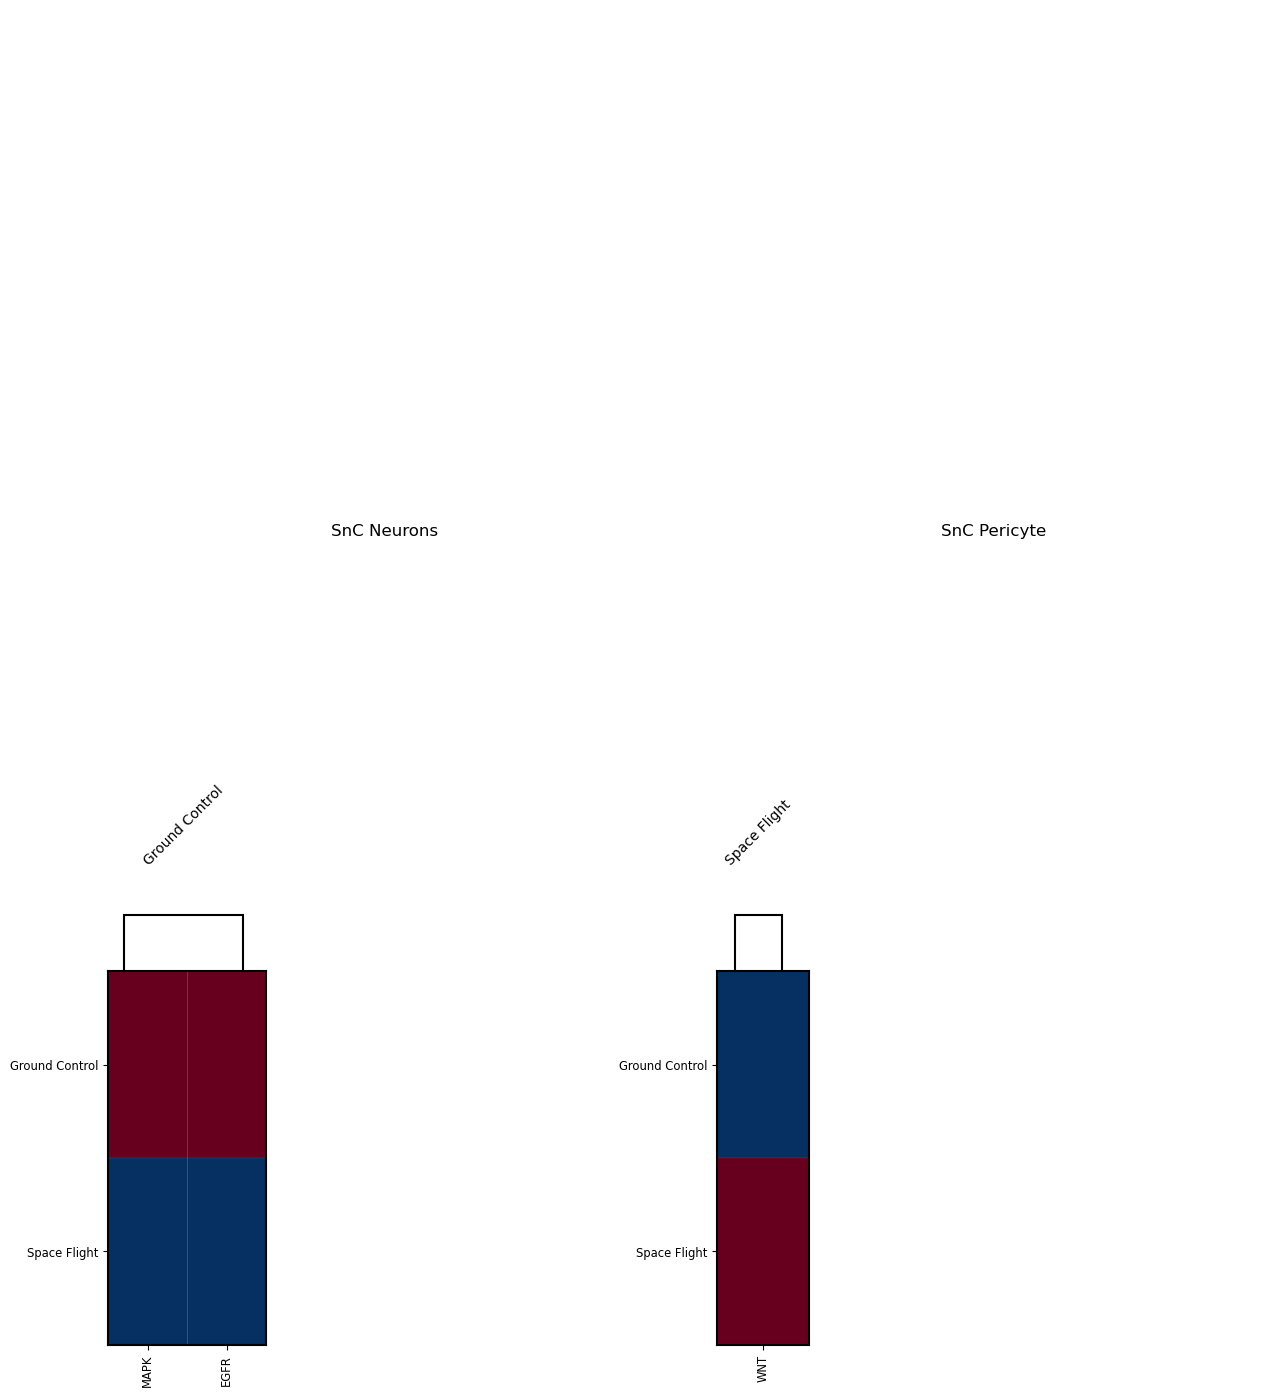

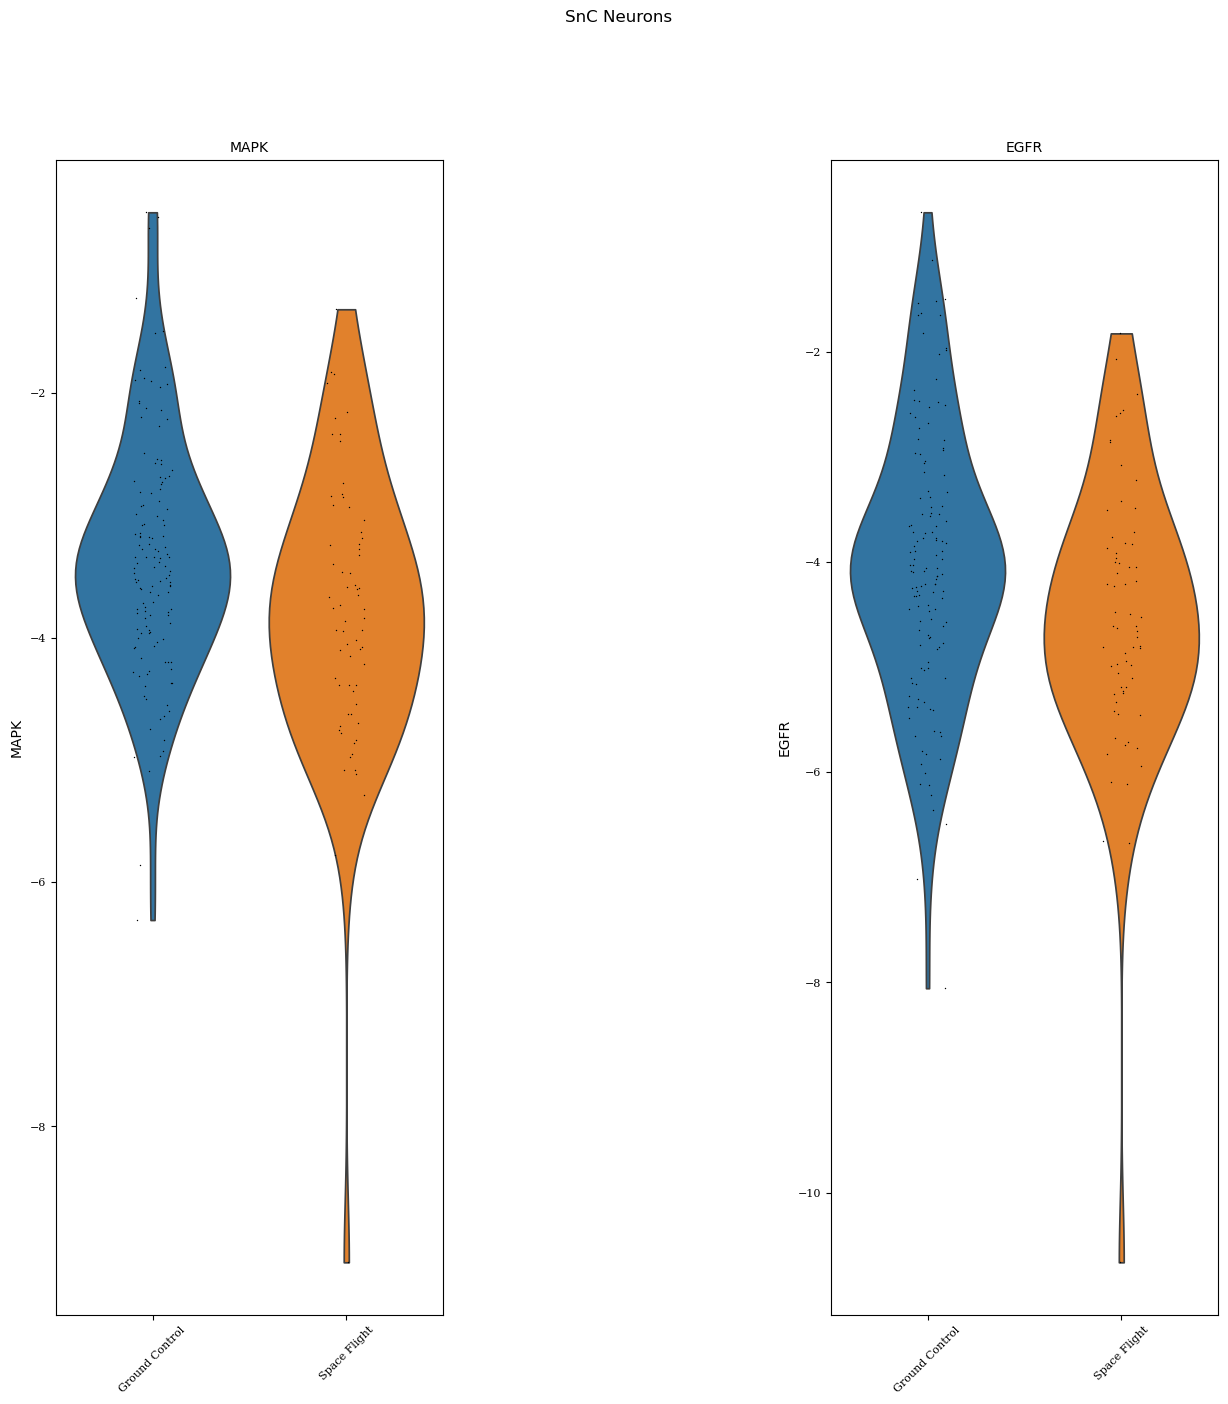



No significant contrasts for SnC OPC


No significant contrasts for SnC Endothelial


No significant contrasts for SnC Neuroepithelial


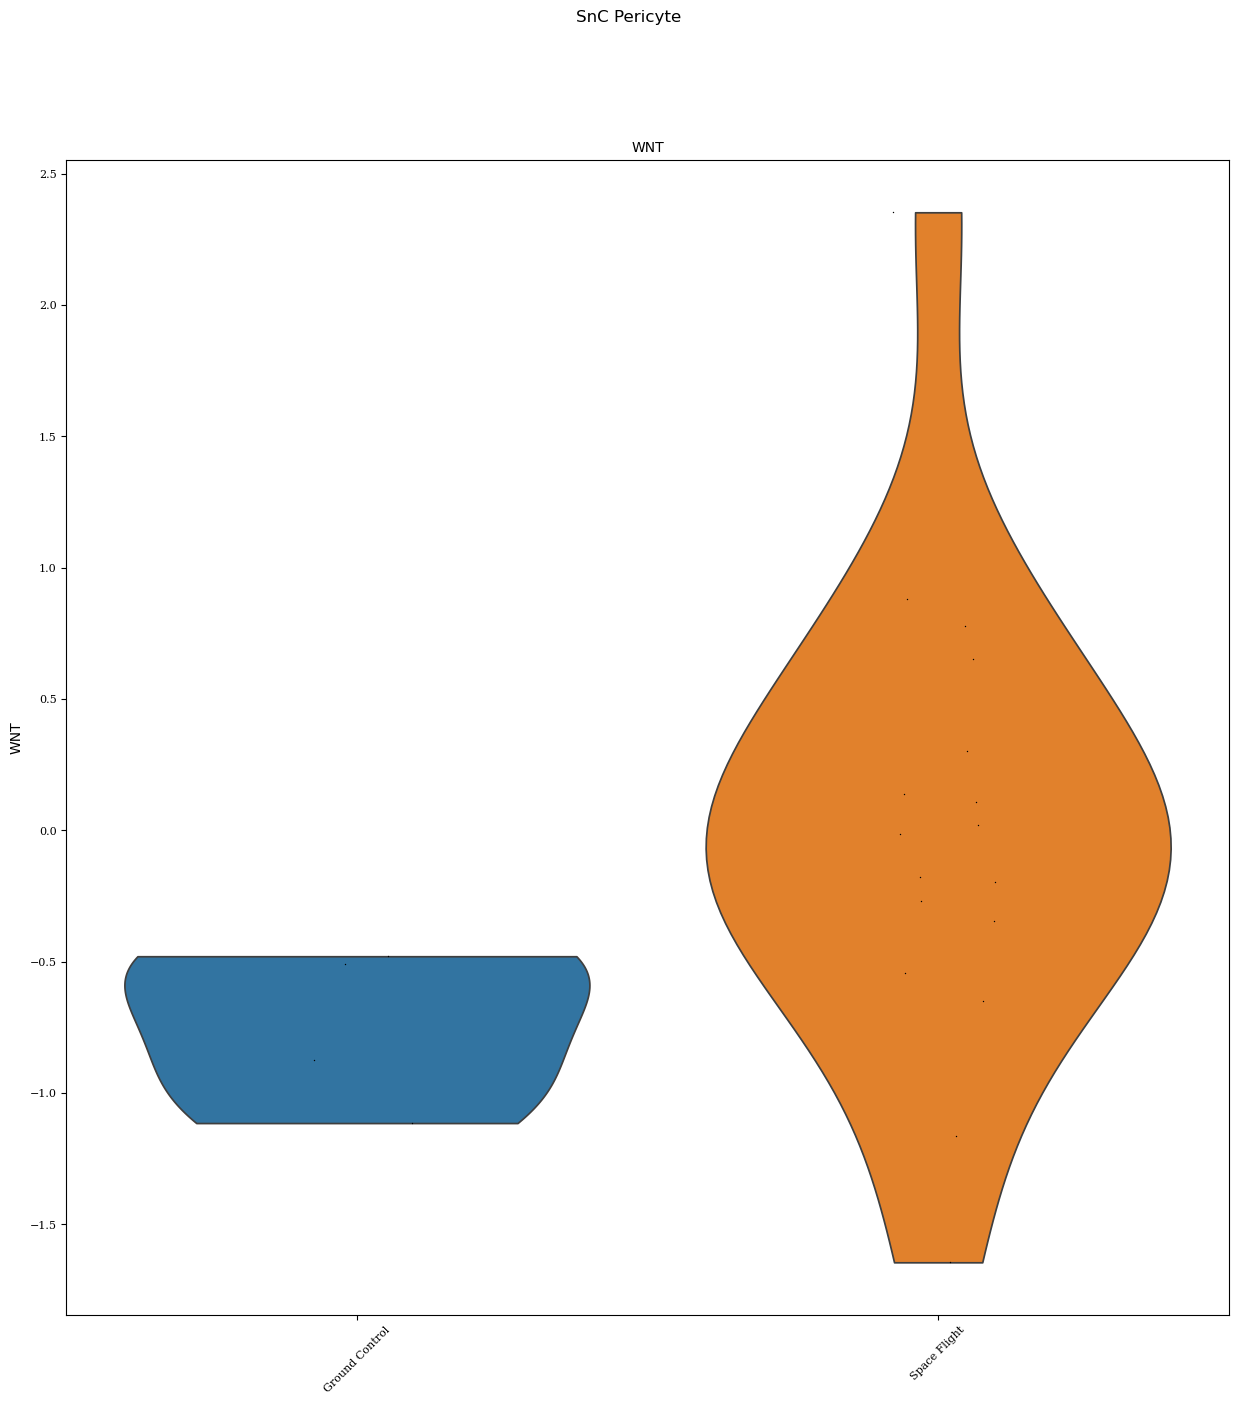

SnC Oligodendrocyte  Ground Control              []
                     Space Flight                []
SnC Astrocyte        Ground Control              []
                     Space Flight                []
SnC Microglial       Ground Control              []
                     Space Flight                []
SnC Neurons          Ground Control    [MAPK, EGFR]
                     Space Flight                []
SnC OPC              Ground Control              []
                     Space Flight                []
SnC Endothelial      Ground Control              []
                     Space Flight                []
SnC Neuroepithelial  Ground Control              []
                     Space Flight                []
SnC Pericyte         Ground Control              []
                     Space Flight             [WNT]
dtype: object


reference      stat  meanchange      pval      padj
annotation_scanvi_collapsed Condition      name                                                    
SnC Neurons                 Ground Control MAPK      rest  3.468160    0.448469  0.000613  0.006255
                                           EGFR      rest  3.359496    0.528550  0.000894  0.006255
SnC Pericyte                Space Flight   WNT       rest  3.344638    0.758383  0.003269  0.045761

In [39]:
res_dc_ulm = scflow.ax.run_decoupler_ulm(
        self.rna[self.rna.obs["Senescent_Cell_Label"] == "Senescent"],
        col_condition, col_condition="Senescent_Cell_Label_by_Type",
        species=species, resource="progeny",
        hspace=0.5, wspace=0.1, top=1, figsize=(15, 15))
res_dc_ulm_scores = pd.concat([res_dc_ulm[0][x][1].set_index(
    "group").rename_axis(col_condition).set_index(
        "name", append=True) for x in res_dc_ulm[0]],
                              keys=res_dc_ulm[0], names=[col_celltype])
res_dc_ulm_pathways = pd.concat([pd.Series(res_dc_ulm[0][x][2])
                                 for x in res_dc_ulm[0]], keys=res_dc_ulm[0])
print(res_dc_ulm_pathways)
res_dc_ulm_scores[res_dc_ulm_scores.padj < 0.05]

#### Pathway Set = Hallmark

##### Cell Type Comparisons (Separately by Condition)

{'SnC Astrocyte': ['INFLAMMATORY_RESPONSE', 'ADIPOGENESIS', 'HYPOXIA'], 'SnC Microglial': ['ALLOGRAFT_REJECTION', 'IL6_JAK_STAT3_SIGNALING', 'INTERFERON_ALPHA_RESPONSE'], 'SnC Neurons': ['PANCREAS_BETA_CELLS', 'KRAS_SIGNALING_DN', 'SPERMATOGENESIS']}
{'SnC Astrocyte': ['ADIPOGENESIS', 'INFLAMMATORY_RESPONSE', 'HYPOXIA'], 'SnC Microglial': ['ALLOGRAFT_REJECTION', 'COMPLEMENT', 'IL6_JAK_STAT3_SIGNALING'], 'SnC Neurons': ['PANCREAS_BETA_CELLS', 'KRAS_SIGNALING_DN', 'SPERMATOGENESIS'], 'SnC Pericyte': ['EPITHELIAL_MESENCHYMAL_TRANSITION']}


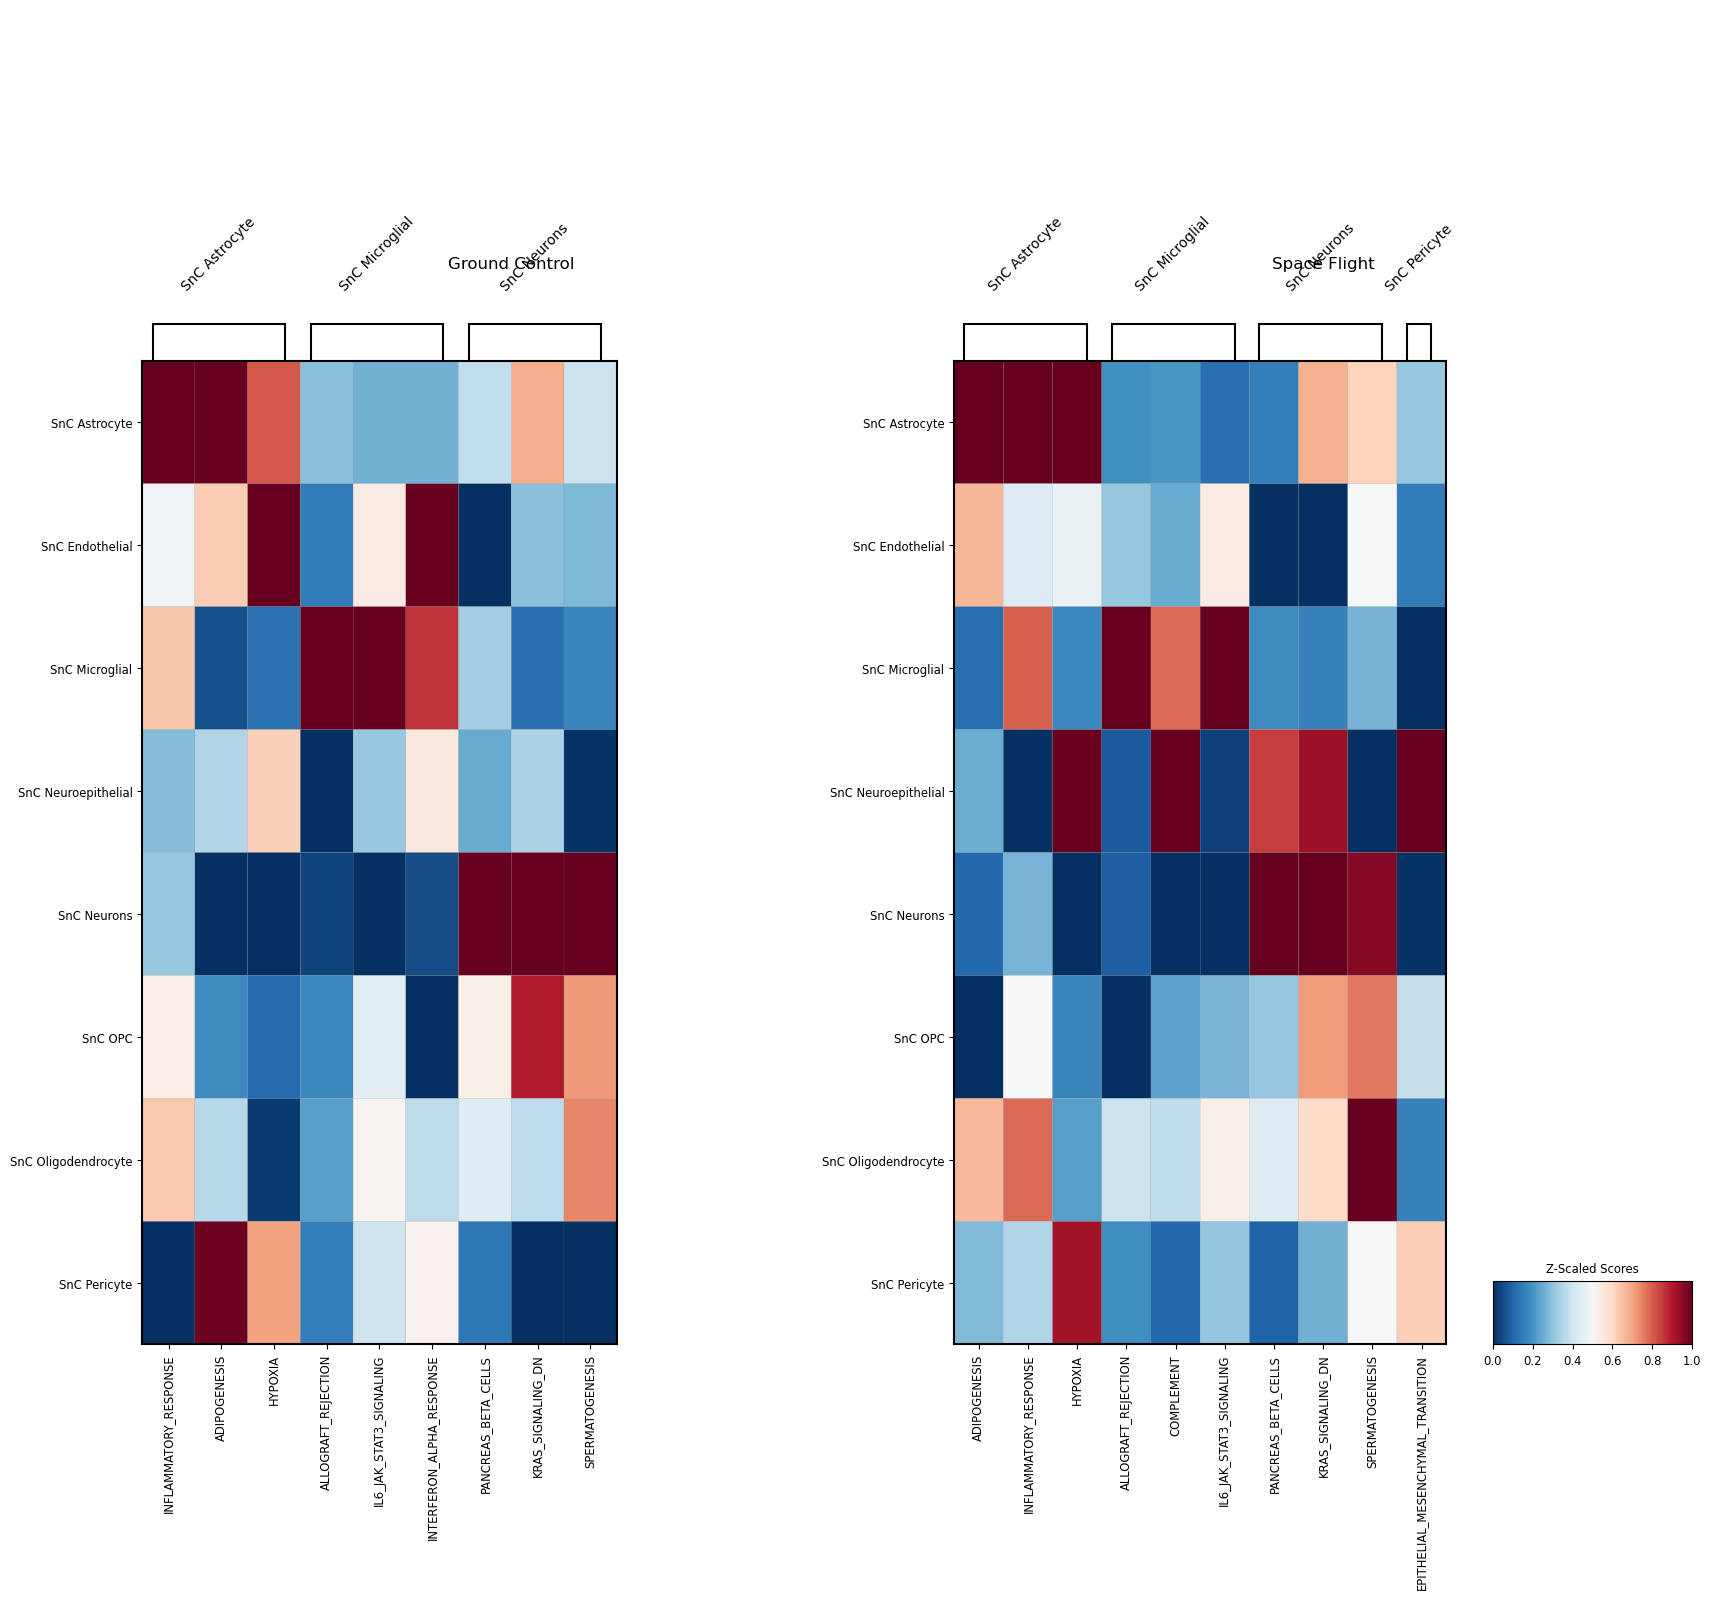

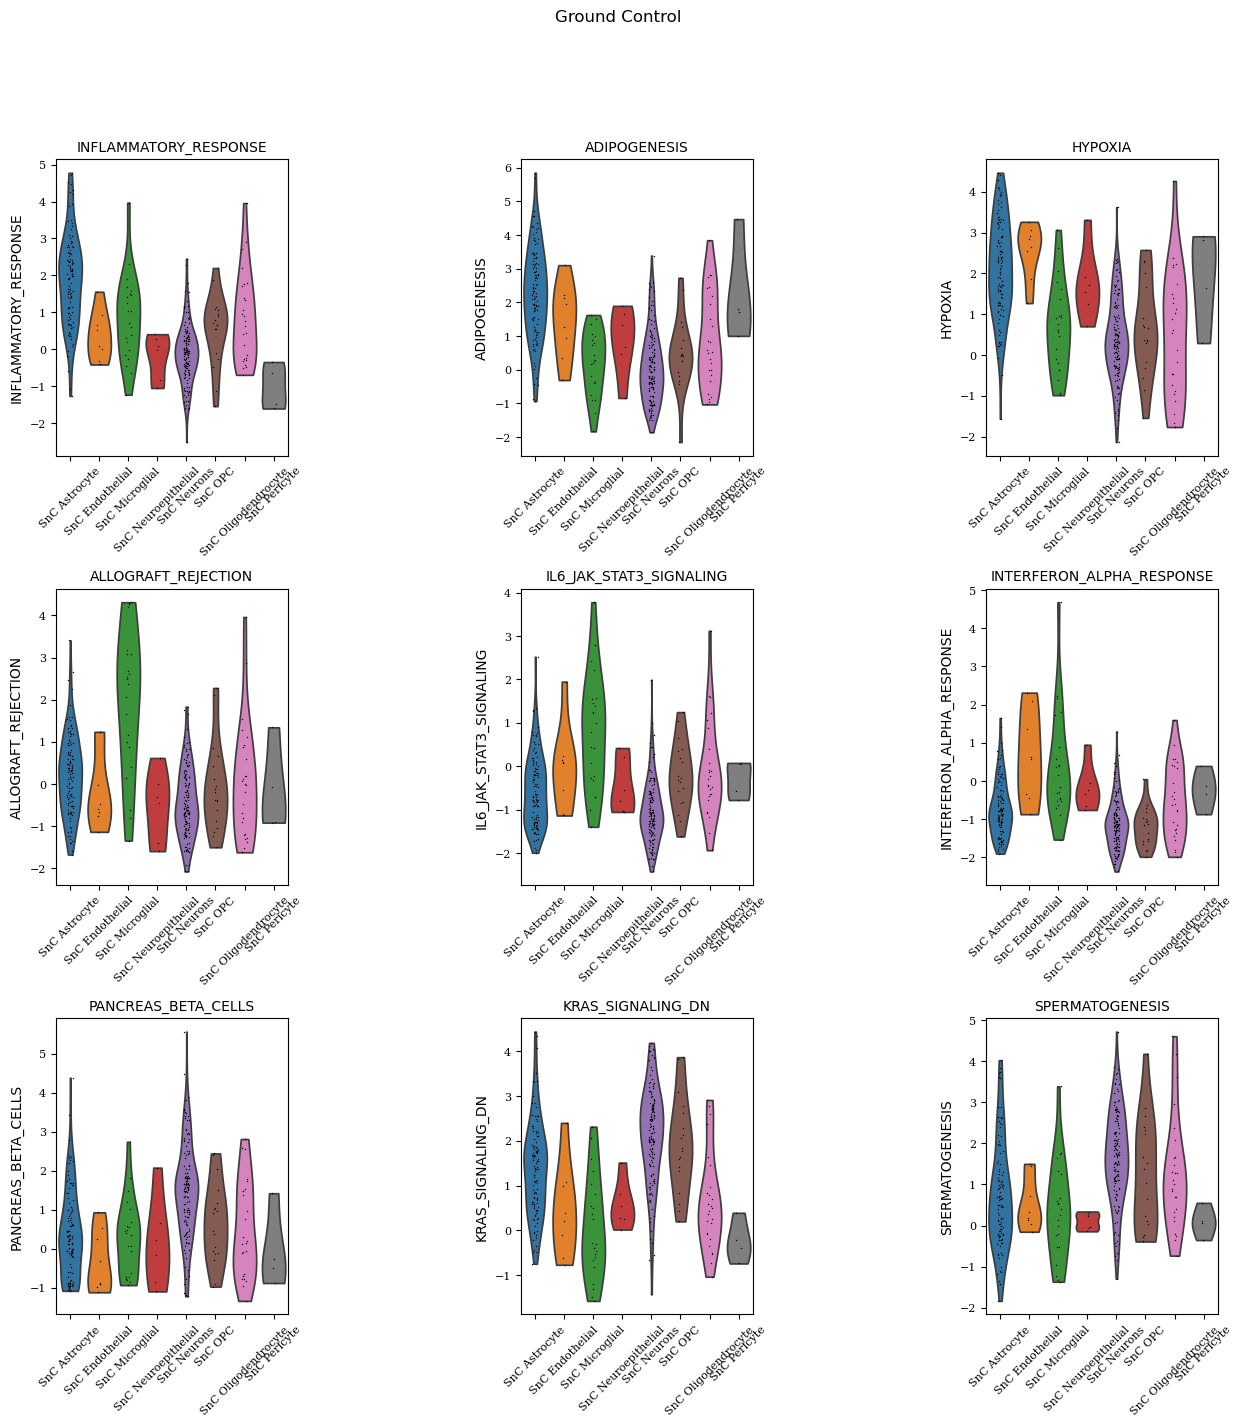

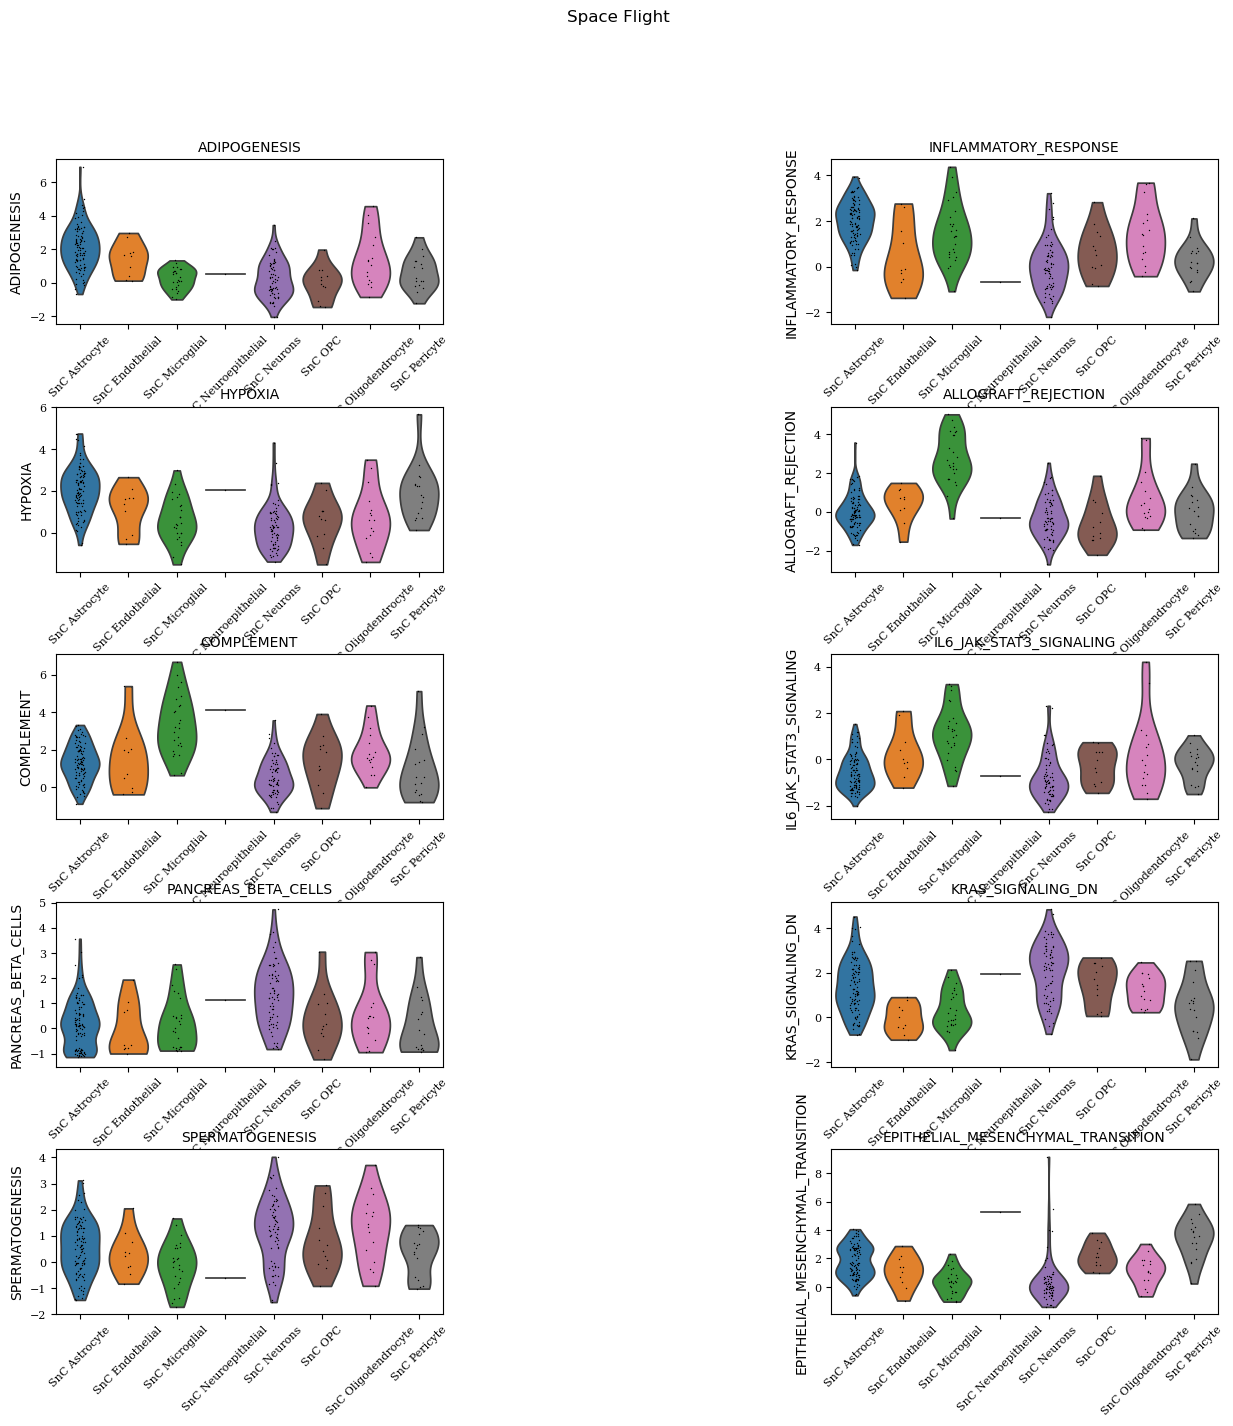

reference       stat  meanchange          pval          padj
Condition      Condition      name                                                                                          
Ground Control SnC Astrocyte  INFLAMMATORY_RESPONSE                  rest  11.764632    1.755182  7.184895e-25  3.592448e-23
                              ADIPOGENESIS                           rest  11.304734    1.923649  1.417778e-23  3.544444e-22
                              HYPOXIA                                rest   9.635168    1.533212  1.484189e-18  2.079829e-17
                              FATTY_ACID_METABOLISM                  rest   9.735237    1.343734  1.663863e-18  2.079829e-17
                              XENOBIOTIC_METABOLISM                  rest   8.863764    1.398817  2.943393e-16  2.943393e-15
                              CHOLESTEROL_HOMEOSTASIS                rest   8.479164    1.560808  6.120020e-15  5.100016e-14
                              ESTROGEN_RESPONSE_LATE                 rest   7.776971    1.099999  2.936390e-13  2.097421e-12
                              TNFA_SIGNALING_VIA_NFKB                rest   7.741430    1.188183  3.690066e-13  2.306292e-12
                              COAGULATION                            rest   7.641138    1.348595  6.584766e-13  3.658203e-12
                              BILE_ACID_METABOLISM                   rest   7.318265    0.963445  4.684848e-12  2.342424e-11
                              EPITHELIAL_MESENCHYMAL_TRANSITION      rest   7.128154    1.251152  1.849959e-11  8.408904e-11
                              MTORC1_SIGNALING                       rest   6.399478    1.013478  9.667077e-10  4.027949e-09
                              NOTCH_SIGNALING                        rest   5.434093    0.927011  1.456932e-07  5.603584e-07
                              IL2_STAT5_SIGNALING                    rest   5.211882    0.850893  4.301996e-07  1.536427e-06
                              PEROXISOME                             rest   4.794269    0.648716  3.007169e-06  1.002390e-05
                              ANDROGEN_RESPONSE                      rest   4.032249    0.726811  7.642685e-05  2.122968e-04
                              MYOGENESIS                             rest   3.775162    0.616296  2.058552e-04  5.417242e-04
                              P53_PATHWAY                            rest   3.695935    0.495846  2.766439e-04  6.586760e-04
                              COMPLEMENT                             rest   3.418805    0.553783  7.499856e-04  1.704513e-03
                              GLYCOLYSIS                             rest   3.385089    0.481365  8.446567e-04  1.836210e-03
                              ESTROGEN_RESPONSE_EARLY                rest   3.119600    0.477338  2.053425e-03  4.277968e-03
               SnC Microglial ALLOGRAFT_REJECTION                    rest   5.053795    2.119009  1.517872e-05  7.589360e-04
                              IL6_JAK_STAT3_SIGNALING                rest   4.434520    1.493665  8.230258e-05  1.371710e-03
               SnC Neurons    PANCREAS_BETA_CELLS                    rest   8.285817    1.147783  5.673039e-15  2.026085e-14
                              KRAS_SIGNALING_DN                      rest   7.701644    1.055764  2.608218e-13  8.150683e-13
                              SPERMATOGENESIS                        rest   6.383600    0.928811  7.661284e-10  1.854639e-09
Space Flight   SnC Astrocyte  ADIPOGENESIS                           rest   9.656433    1.667512  2.420126e-18  1.041241e-16
                              INFLAMMATORY_RESPONSE                  rest   9.680908    1.495483  4.164966e-18  1.041241e-16
                              HYPOXIA                                rest   8.478128    1.382457  5.065320e-15  8.442199e-14
                              CHOLESTEROL_HOMEOSTASIS                rest   8.146094    1.528970  5.394485e-14  6.743106e-13
                              FATTY_ACID_METABOLISM             

In [38]:
res_dc_ulm_hm_sfct = scflow.ax.run_decoupler_ulm(
        self.rna[self.rna.obs["Senescent_Cell_Label"] == "Senescent"],
        "Senescent_Cell_Label_by_Type", col_condition=col_condition,
        species=species, resource="hallmark", title_position=0.8,
        hspace=0.5, wspace=0.1, top=1, figsize=(20, 15))
res_dc_ulm_hm_sfct_scores = pd.concat([res_dc_ulm_hm_sfct[0][x][1].set_index(
    "group").rename_axis(col_condition).set_index(
        "name", append=True) for x in res_dc_ulm_hm_sfct[0]],
                              keys=res_dc_ulm_hm_sfct[0],
                              names=[col_condition])
res_dc_ulm_hm_sfct_scores[res_dc_ulm_hm_sfct_scores.padj < 0.01]

##### SF vs. GC

{'Space Flight': ['TGF_BETA_SIGNALING', 'COMPLEMENT']}
{'Space Flight': ['INFLAMMATORY_RESPONSE']}


No significant contrasts for SnC Oligodendrocyte


No significant contrasts for SnC Astrocyte


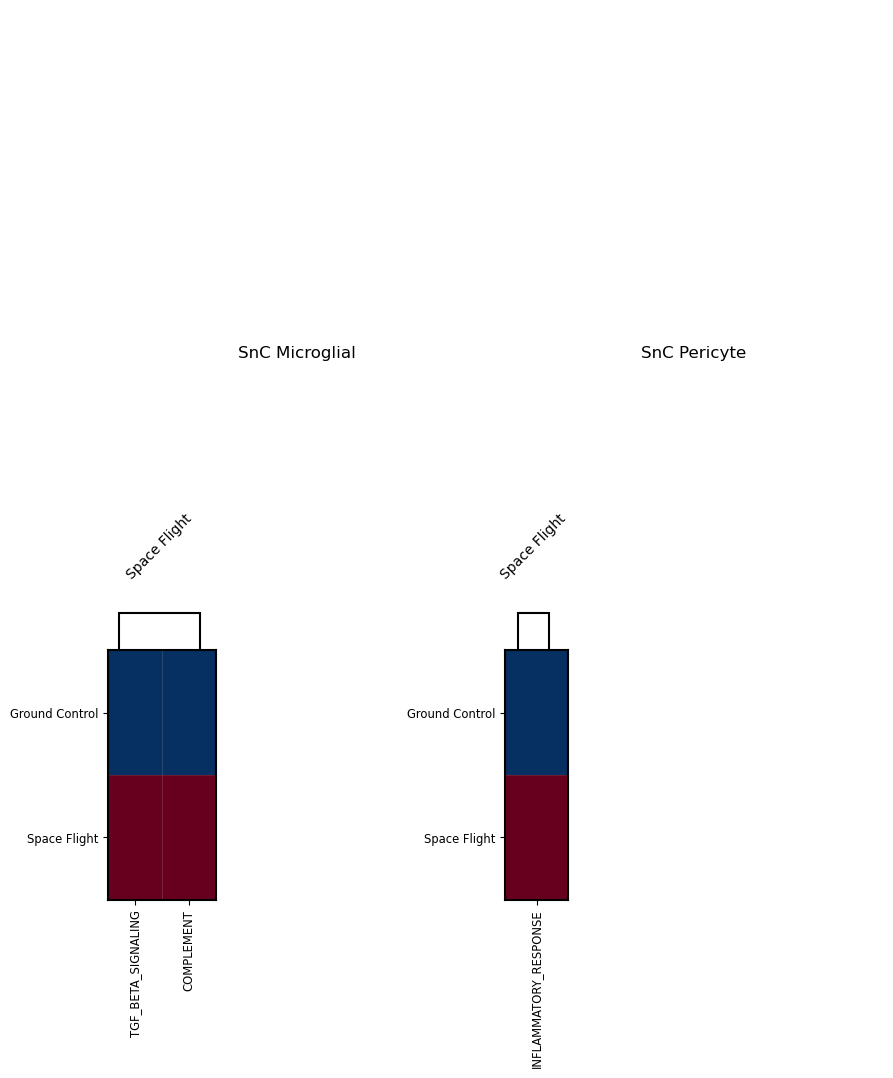

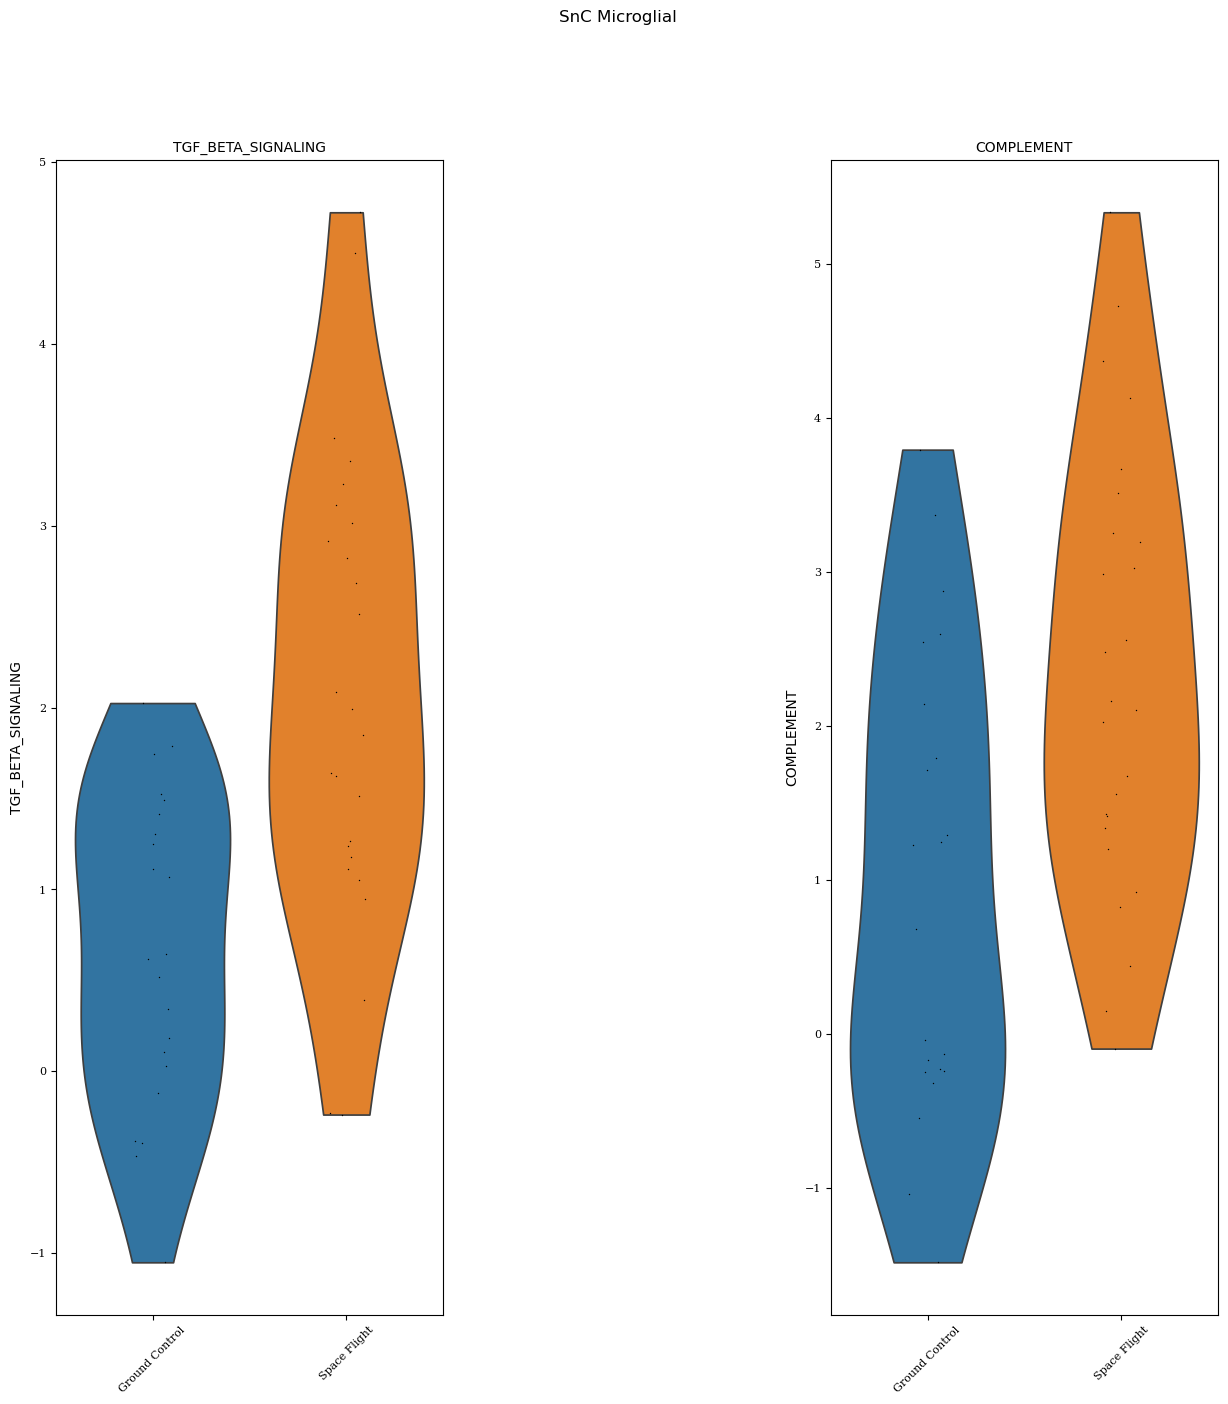



No significant contrasts for SnC Neurons


No significant contrasts for SnC OPC


No significant contrasts for SnC Endothelial


No significant contrasts for SnC Neuroepithelial


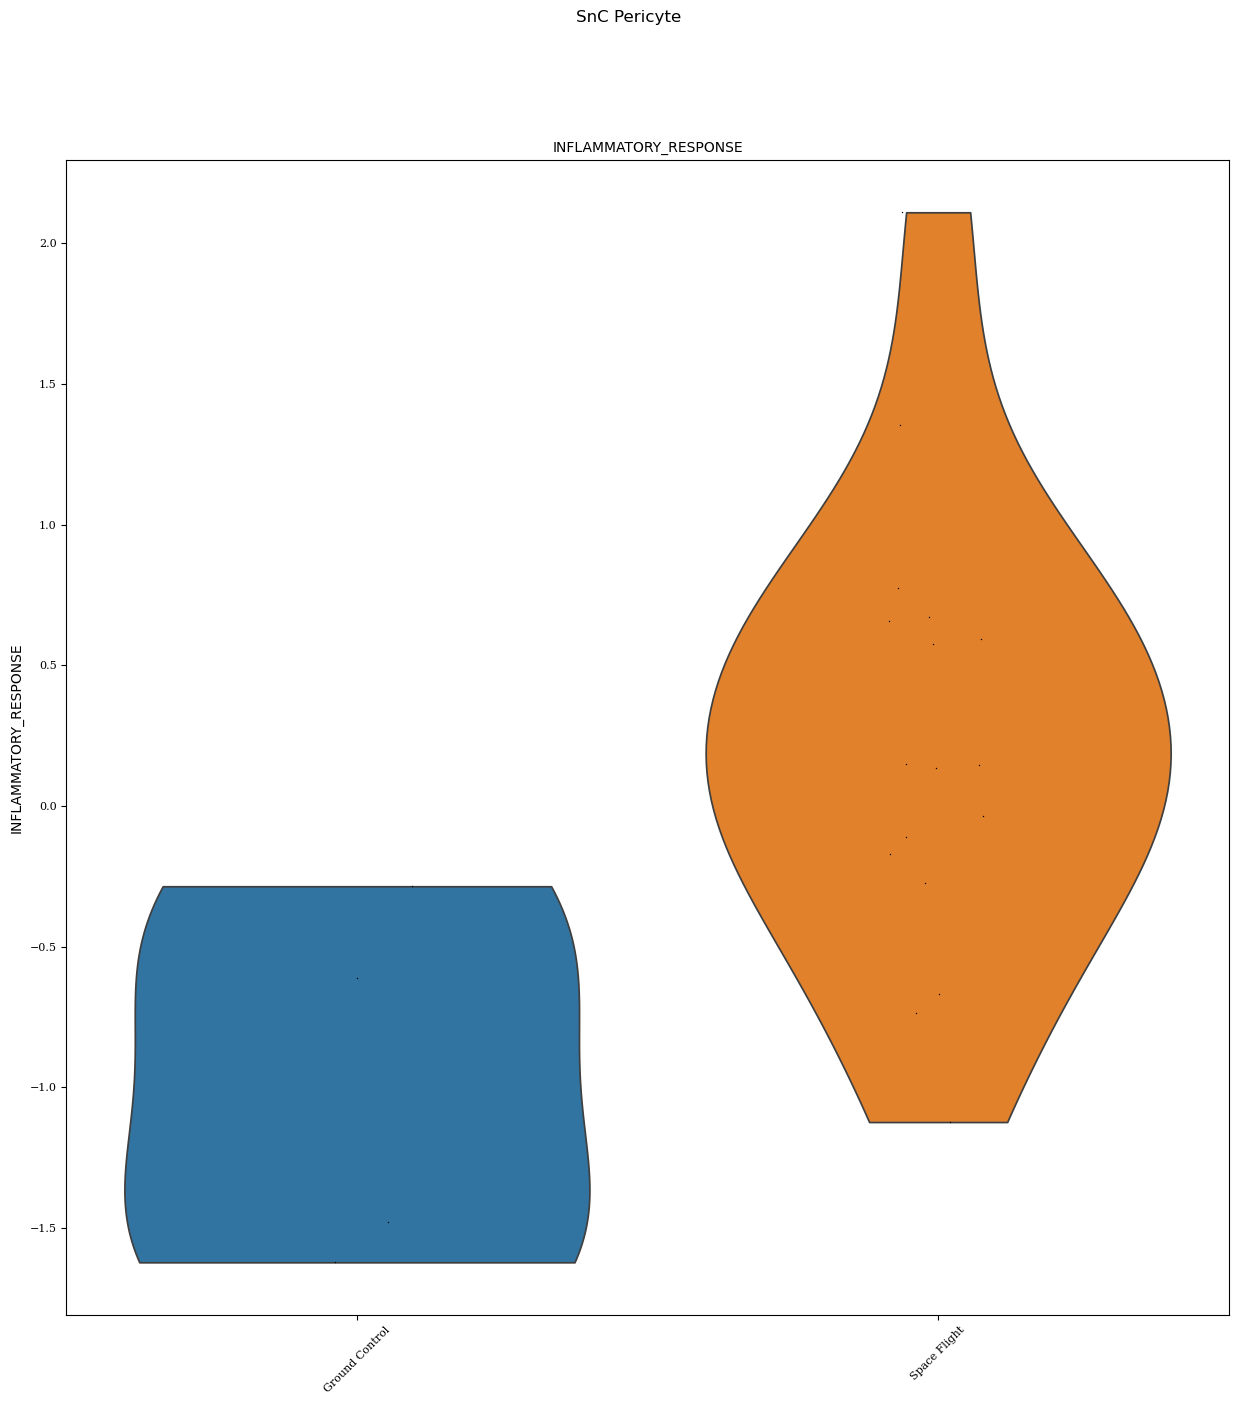

reference      stat  meanchange      pval      padj
annotation_scanvi_collapsed Condition    name                                                                     
SnC Microglial              Space Flight TGF_BETA_SIGNALING         rest  4.609209    1.397422  0.000035  0.001757
                                         COMPLEMENT                 rest  3.374825    1.374454  0.001437  0.035914
SnC Pericyte                Space Flight INFLAMMATORY_RESPONSE      rest  4.992155    1.238077  0.000022  0.001104

In [37]:
res_dc_ulm_hm_sf = scflow.ax.run_decoupler_ulm(
        self.rna[self.rna.obs["Senescent_Cell_Label"] == "Senescent"],
        col_condition, col_condition="Senescent_Cell_Label_by_Type",
        species=species, resource="hallmark", title_position=0.6,
        hspace=0.3, wspace=0.05, top=1, figsize=(10, 10), top_n=10)
res_dc_ulm_hm_sf_scores = pd.concat([res_dc_ulm_hm_sf[0][x][1].set_index(
    "group").rename_axis(col_condition).set_index(
        "name", append=True) for x in res_dc_ulm_hm_sf[0]],
                              keys=res_dc_ulm_hm_sf[0], names=[col_celltype])
res_dc_ulm_hm_sf_scores[res_dc_ulm_hm_sf_scores.padj < 0.05]

### Individual Cell Scores

In [ ]:
res_aucell = scflow.ax.run_decoupler_aucell(
    self.rna, col_covariates=["Senescent_Cell_Label_by_Type", col_condition],
    resource="progeny", species=species, inplace=True)
_ = self.plot(genes=list(self.rna.obsm["score_aucell"].columns),
              subset=self.rna.obs["Senescent_Cell"],
              col_celltype=col_condition, kind="violin",
              by_group="Senescent_Cell_Label_by_Type", figsize=(15, 15))

#### DEGs (`find_markers`) by Group

In [ ]:
out_pathway_snc_degs = scflow.ax.run_enrichr(
    df_snc_markers_top, col_grouping=["Comparison", col_celltype],
    gene_sets=gene_sets, fx_replace_string=fx_replace_string, title="Overall")
out_pathway_snc_degs_gc = scflow.ax.run_enrichr(
    df_snc_markers_top_gc, col_grouping=["Comparison", col_celltype],
    gene_sets=gene_sets, fx_replace_string=fx_replace_string,
    title=keys[col_condition]["key_control"])
out_pathway_snc_degs_sf = scflow.ax.run_enrichr(
    df_snc_markers_top_sf, col_grouping=["Comparison", col_celltype],
    gene_sets=gene_sets, fx_replace_string=fx_replace_string,
    title=keys[col_condition]["key_treatment"])
# out_pathway_snc_degs[1].drop("All", level=0)

#### Edger Contrasts (Pseudo-Bulk)

In [ ]:
# GSEA
print("\n\nGSEA Enrichment Analysis\n\n")
out_pathway_snc_degs = scflow.ax.run_enrichr(
    out_edgr_contrasts_snc_all_top, col_grouping=col_celltype,
    gene_sets=gene_sets, fx_replace_string=fx_replace_string)

# ToppGene
print("\n\nToppGene Enrichment Analysis\n\n")
mks_ctrsts_snc = dict(out_edgr_contrasts_snc_all_top.reset_index(
    1).variable.groupby(col_celltype).apply(lambda x: list(x)))  # SnC DEGs
results_toppgene_degs = scflow.pp.annotate_by_toppgene(
    mks_ctrsts_snc, species=species, min_genes=1,
    categories=["Pathway", "PubMed"])
results_toppgene_degs = results_toppgene_degs.join(pd.Series(
    mks_ctrsts_snc).to_frame("DEGs").rename_axis("Gene Set"))
results_toppgene_degs = results_toppgene_degs.groupby("Gene Set").apply(
    lambda x: x.sort_values("PValue", ascending=True), include_groups=False)
pthwys = dict(results_toppgene_degs.groupby("Gene Set").apply(
    lambda x: [i.capitalize() for i in x.Name.unique()]))
print("\n\n".join([f"{k}: {pthwys[k]}" for k in pthwys]))
results_toppgene_degs[["Name", "Symbols", "GenesInTerm", "GenesInQuery",
                       "GenesInTermInQuery", "PValue"]].reset_index(
                           2, drop=True)

## Plot

In [ ]:
# Top 10 Senescence Genes or All?
ggg = top_genes
# ggg = genes

# Mask for High Senescence Subset & Helper Variable for Figure Dimensions
subset = self.rna.obs["Senescent_Cell"].isin([1, True])
num_cts = len(self.rna[subset].obs[col_celltype].unique())

# Plot SnC Markers Overlap with Marker Sets
sc.pl.violin(self.rna[subset], set(genes).intersection(
    marker_gene_sets.explode().unique()),
             groupby=col_batch, rotation=90)  # plot overlap w/ SnC markers

# Plot Most Highly-Expressed Genes in Each Senescent Cell Type
_ = self.plot(kind=["matrix", "heat"], genes=top_genes,
              col_celltype=col_celltype, layer="log1p",
              subset=subset, dendrogram=True, swap_axes=False, heat=dict(
                  dendrogram=False), standard_scale="var",
              figsize=(len(top_genes) / 1.5, num_cts * 1.5))

# Grouped by Top Cell Types
_ = self.plot(kind=["matrix", "heat"], genes=top_genes_dict,
              standard_scale="obs", col_celltype=col_celltype,
              layer="log1p", swap_axes=False, figsize=(len(ggg), num_cts),
              subset=subset, dendrogram=True)

# Write Object

In [ ]:
# Send Email with Output When Done
if email is not None and html_out is not None:
    os.system(f"jupyter nbconvert --to html {cur_file}")
    os.system(f"echo 'yay' | mutt -s 'JOB DONE' -a {html_out} -- {email}")

# SCRATCH

In [ ]:
# %%R

# MAST

# find_de_MAST_RE <- function(adata_, formula){
#     # create a MAST object
#     sca <- SceToSingleCellAssay(adata_, class="SingleCellAssay")
#     print("Dimensions before subsetting:")
#     print(dim(sca))
#     print("")
#     # keep genes that are expressed in more than 10% of all cells
#     sca <- sca[freq(sca) > 0.1,]
#     print("Dimensions after subsetting:")
#     print(dim(sca), "\n")
#     cdr2 <- colSums(assay(sca) > 0)
#     colData(sca)$ngeneson <- scale(cdr2)
#     # store the columns that we are interested in as factors
#     label <- factor(colData(sca)$label)
#     # set the reference level
#     label <- relevel(label,"ctrl")
#     colData(sca)$label <- label
#     celltype <- factor(colData(sca)$cell_type)
#     colData(sca)$celltype <- celltype
#     # same for donors (which we need to model random effects)
#     replicate <- factor(colData(sca)$replicate)
#     colData(sca)$replicate <- replicate
#     # create a group per condition-celltype combination
#     colData(sca)$group <- paste0(colData(
#         adata_)$label, ".", colData(adata_)$cell_type)
#     colData(sca)$group <- factor(colData(sca)$group)
#     # define and fit the model
#     zlmCond <- zlm(formula=formula,
#                    sca=sca,
#                    method="glmer",
#                    ebayes=F,
#                    strictConvergence=F,
#                    fitArgsD=list(nAGQ = 0)) # to speed up calculations
#     # perform likelihood-ratio test for the condition
#     summaryCond <- summary(zlmCond, doLRT="groupstim.CD14_Monocytes")
#     # get the table with log-fold changes and p-values
#     summaryDt <- summaryCond$datatable
#     return(summaryDt)
# }

In [ ]:
# df_degs = out_edgr_old_sf_v_gc.copy()
# df_degs = out_edgr_batches_snc_top.copy()
# df_degs = res_snc_grps.copy()
df_degs = df_snc_markers.drop("All").reset_index(0, drop=True)
df_degs = df_degs[df_degs.pvals_adj < 1e-25]

factor_name = col_celltype
# factor_name = col_condition

names = gp.get_library_name()
# [i for i in names if "brain" in i.lower() or "mouse" in i.lower()]
pathways_snc_vs_no, res_pathways_snc_vs_no = {}, {}
thresh_p_path = 0.05
# perts_geo = ["Aging", "Drug", "Disease"]
perts_geo = ["Aging", "Disease"]
other_sets = ["GTEx_Aging_Signatures_2021", f"HDSigDB_{species}_2021",
              # "DGIdb_Drug_Targets_2024",
              "MSigDB_Hallmark_2020",
              "MSigDB_Oncogenic_Signatures", "OMIM_Disease",
              # "Reactome_Pathways_2024", "Reactome_2022",
              f"WikiPathways_2024_{species}", f"WikiPathways_2019_{species}"]
other_sets += [i for i in names if "GO_Biological_Process" in i]
gene_sets = dict(zip(["up", "down"], [[
    f"{u}_Perturbations_from_GEO_{i}" for u in perts_geo] + [
        f"Disease_Signatures_from_GEO_{i}_2014"] + other_sets
    for i in ["up", "down"]]))
# if species.lower() == "mouse":
#     other_sets += ["PerturbAtlas_MouseGenePerturbationSigs"]
for x in df_degs.reset_index()[factor_name].unique():
    pathways_snc_vs_no[x], res_pathways_snc_vs_no[x] = {}, {}
    for i in ["up", "down"]:
        degs_tmp = df_degs.loc[x]
        if i == "up":
            degs_tmp = list(degs_tmp[degs_tmp.log_fc > 0].index.values)
        else:
            degs_tmp = list(degs_tmp[degs_tmp.log_fc < 0].index.values)
        if len(degs_tmp) > 0:
            g_s = [f"{u}_Perturbations_from_GEO_{i}" for u in perts_geo] + [
                f"Disease_Signatures_from_GEO_{i}_2014"] + other_sets
            g_s = [g for g in g_s if g in names]
            pathways_snc_vs_no[x][i] = gp.enrichr(
                gene_list=degs_tmp, gene_sets=g_s,
                organism=species, cutoff=0.5)
            res_pathways_snc_vs_no[x][i] = pathways_snc_vs_no[x][i].results[
                pathways_snc_vs_no[x][i].results[
                    "Adjusted P-value"] < thresh_p_path]
    res_pathways_snc_vs_no[x] = pd.concat(res_pathways_snc_vs_no[x],
                                          names=["Direction"])
res_pathways_snc_vs_no = pd.concat(res_pathways_snc_vs_no,
                                   names=[col_celltype])
res_pathways_snc_vs_no.loc[
    :, "Term Short"] = res_pathways_snc_vs_no.Term.apply(
        lambda x: re.sub("Expression Of ", "", re.sub(".*.xls", "", re.sub(
            ".*.XLSX", "",
            re.sub(".*Supplementary Table [0-9]+[-]?", "", re.sub(
                ".*.xlsx.", "", re.sub(".*Supplementary Data ..", "", re.sub(
                    "PMID([0-9])+", "", re.sub(
                        "([0-9]+) years v ([0-9]+) years", "\\1 v \\2 yrs.",
                        re.sub("aging:([0-9]+)", "aging", re.sub(
                            "([0-9]+) months v ([0-9]+) mo(nths)?",
                            "\\1 v \\2 mo.", re.sub("SRP[0-9]+ ", "", re.sub(
                                "GSE[0-9]+ ", "", x)))))))))))))
cts_i = res_pathways_snc_vs_no.reset_index()[col_celltype].unique()
res_pathways_snc_top_vs_no = res_pathways_snc_vs_no.reset_index().groupby([
    col_celltype, "Direction"]).apply(lambda x: x.sort_values(
        "Adjusted P-value", ascending=True).head(10), include_groups=False)
fig, axes = plt.subplots(*scflow.pl.square_grid(cts_i), figsize=(
    20, 25), gridspec_kw=dict(wspace=1.5, top=0.95), squeeze=False)
for i, x in enumerate(cts_i):
    gp.dotplot(
        res_pathways_snc_top_vs_no.loc[x].reset_index(),
        column="Adjusted P-value",
        # column="Overlap",
        x="Direction", y="Term Short",
        ax=axes.flatten()[i], size=20, top_term=100,
        title=x, xticklabels_rot=45, yticklabels_rot=45,
        show_ring=True, marker="o", cutoff=0.5)
    axes.flatten()[i].tick_params(axis="y", labelsize=8,
                                  labelfontfamily="serif")
    axes.flatten()[i].tick_params(axis="x", labelsize=10,
                                  labelfontfamily="serif")
    axes.flatten()[i].title.set_fontsize(10)
if len(axes.flatten()) > len(cts_i):
    for a in axes.flatten()[len(cts_i):]:
        a.set_visible(False)
fig.suptitle("Senescent Cell Spaceflight DEGs", fontsize="xx-large",
             fontproperties=dict(family="serif"))
res_pathways_snc_top_vs_no[["Term Short", "Genes"] + list(
    res_pathways_snc_top_vs_no.columns.difference([
        "Term", "Genes", "Term Short"]))]

In [ ]:
# df_degs = out_edgr_old_sf_v_gc.copy()
# df_degs = out_edgr_batches_snc_top.copy()
# df_degs = res_snc_grps.copy()

# factor_name = col_celltype
# factor_name = col_condition
factor_name = col_batch

df_degs = res_rank_genes.loc[:, "Overall", :]
df_degs = df_degs.assign(log_fc=df_degs.logfoldchanges.abs())
df_degs = df_degs.assign(abs_log_fc=df_degs.logfoldchanges_abs)
df_degs = df_degs.reset_index(1).set_index("names", append=True)

names = gp.get_library_name()
# [i for i in names if "brain" in i.lower() or "mouse" in i.lower()]
pathways_snc_vs_no, res_pathways_snc_vs_no = {}, {}
thresh_p_path = 0.05
# perts_geo = ["Aging", "Drug", "Disease"]
perts_geo = ["Aging", "Disease"]
other_sets = ["GTEx_Aging_Signatures_2021",
              # f"HDSigDB_{species}_2021",
              # "DGIdb_Drug_Targets_2024",
              "MSigDB_Hallmark_2020",
              "MSigDB_Oncogenic_Signatures", "OMIM_Disease",
              "Reactome_Pathways_2024",
              # "Reactome_2022",
              f"WikiPathways_2024_{species}", f"WikiPathways_2019_{species}"]
other_sets += [i for i in names if "GO_Biological_Process" in i]
# if species.lower() == "mouse":
#     other_sets += ["PerturbAtlas_MouseGenePerturbationSigs"]
for x in df_degs.reset_index()[factor_name].unique():
    pathways_snc_vs_no[x], res_pathways_snc_vs_no[x] = {}, {}
    for i in ["up", "down"]:
        degs_tmp = df_degs.loc[x]
        if i == "up":
            degs_tmp = list(degs_tmp[degs_tmp.log_fc > 0].index.values)
        else:
            degs_tmp = list(degs_tmp[degs_tmp.log_fc < 0].index.values)
        if len(degs_tmp) > 0:
            g_s = [f"{u}_Perturbations_from_GEO_{i}" for u in perts_geo] + [
                f"Disease_Signatures_from_GEO_{i}_2014"] + other_sets
            g_s = [g for g in g_s if g in names]
            pathways_snc_vs_no[x][i] = gp.enrichr(
                gene_list=degs_tmp, gene_sets=g_s,
                organism=species, cutoff=0.5)
            res_pathways_snc_vs_no[x][i] = pathways_snc_vs_no[x][i].results[
                pathways_snc_vs_no[x][i].results[
                    "Adjusted P-value"] < thresh_p_path]
    res_pathways_snc_vs_no[x] = pd.concat(res_pathways_snc_vs_no[x],
                                          names=["Direction"])
res_pathways_snc_vs_no = pd.concat(res_pathways_snc_vs_no,
                                   names=[col_celltype])
res_pathways_snc_vs_no.loc[
    :, "Term Short"] = res_pathways_snc_vs_no.Term.apply(
        lambda x: re.sub("Expression Of ", "", re.sub(".*.xls", "", re.sub(
            ".*.XLSX", "",
            re.sub(".*Supplementary Table [0-9]+[-]?", "", re.sub(
                ".*.xlsx.", "", re.sub(".*Supplementary Data ..", "", re.sub(
                    "PMID([0-9])+", "", re.sub(
                        "([0-9]+) years v ([0-9]+) years", "\\1 v \\2 yrs.",
                        re.sub("aging:([0-9]+)", "aging", re.sub(
                            "([0-9]+) months v ([0-9]+) mo(nths)?",
                            "\\1 v \\2 mo.", re.sub("SRP[0-9]+ ", "", re.sub(
                                "GSE[0-9]+ ", "", x)))))))))))))
cts_i = res_pathways_snc_vs_no.reset_index()[col_celltype].unique()
res_pathways_snc_top_vs_no = res_pathways_snc_vs_no.reset_index().groupby([
    col_celltype, "Direction"]).apply(lambda x: x.sort_values(
        "Adjusted P-value", ascending=True).head(10), include_groups=False)
fig, axes = plt.subplots(*scflow.pl.square_grid(cts_i), figsize=(
    20, 25), gridspec_kw=dict(wspace=1.5, top=0.95), squeeze=False)
for i, x in enumerate(cts_i):
    gp.dotplot(
        res_pathways_snc_top_vs_no.loc[x].reset_index(),
        column="Adjusted P-value",
        # column="Overlap",
        x="Direction", y="Term Short",
        ax=axes.flatten()[i], size=20, top_term=100,
        title=x, xticklabels_rot=45, yticklabels_rot=45,
        show_ring=True, marker="o", cutoff=0.5)
    axes.flatten()[i].tick_params(axis="y", labelsize=8,
                                  labelfontfamily="serif")
    axes.flatten()[i].tick_params(axis="x", labelsize=10,
                                  labelfontfamily="serif")
    axes.flatten()[i].title.set_fontsize(10)
if len(axes.flatten()) > len(cts_i):
    for a in axes.flatten()[len(cts_i):]:
        a.set_visible(False)
fig.suptitle("Senescent Cell Spaceflight DEGs",
             fontsize="xx-large",
             fontproperties=dict(family="serif"))
res_pathways_snc_top_vs_no[["Term Short", "Genes"] + list(
    res_pathways_snc_top_vs_no.columns.difference([
        "Term", "Genes", "Term Short"]))]

In [ ]:
# df_degs = out_edgr_old_sf_v_gc.copy()
# df_degs = out_edgr_batches_snc_top.copy()
# df_degs = res_snc_grps.copy()

factor_name = col_celltype
# factor_name = col_condition

iii = 2
df_degs = res_rank_genes_top.loc[self.rna.obs[col_batch].unique()[iii]]
df_degs = df_degs.assign(log_fc=df_degs.logfoldchanges.abs())
df_degs = df_degs.assign(abs_log_fc=df_degs.logfoldchanges_abs)
print(self.rna.obs[col_batch].unique()[iii])

names = gp.get_library_name()
# [i for i in names if "brain" in i.lower() or "mouse" in i.lower()]
pathways_snc_vs_no, res_pathways_snc_vs_no = {}, {}
thresh_p_path = 0.05
# perts_geo = ["Aging", "Drug", "Disease"]
perts_geo = ["Aging", "Disease"]
other_sets = ["GTEx_Aging_Signatures_2021", f"HDSigDB_{species}_2021",
              # "DGIdb_Drug_Targets_2024",
              "MSigDB_Hallmark_2020",
              "MSigDB_Oncogenic_Signatures", "OMIM_Disease",
              # "Reactome_Pathways_2024", "Reactome_2022",
              f"WikiPathways_2024_{species}", f"WikiPathways_2019_{species}"]
other_sets += [i for i in names if "GO_Biological_Process" in i]
# if species.lower() == "mouse":
#     other_sets += ["PerturbAtlas_MouseGenePerturbationSigs"]
for x in df_degs.reset_index()[factor_name].unique():
    pathways_snc_vs_no[x], res_pathways_snc_vs_no[x] = {}, {}
    for i in ["up", "down"]:
        degs_tmp = df_degs.loc[x]
        if i == "up":
            degs_tmp = list(degs_tmp[degs_tmp.log_fc > 0].index.values)
        else:
            degs_tmp = list(degs_tmp[degs_tmp.log_fc < 0].index.values)
        if len(degs_tmp) > 0:
            g_s = [f"{u}_Perturbations_from_GEO_{i}" for u in perts_geo] + [
                f"Disease_Signatures_from_GEO_{i}_2014"] + other_sets
            g_s = [g for g in g_s if g in names]
            pathways_snc_vs_no[x][i] = gp.enrichr(
                gene_list=degs_tmp, gene_sets=g_s,
                organism=species, cutoff=0.5)
            res_pathways_snc_vs_no[x][i] = pathways_snc_vs_no[x][i].results[
                pathways_snc_vs_no[x][i].results[
                    "Adjusted P-value"] < thresh_p_path]
    res_pathways_snc_vs_no[x] = pd.concat(res_pathways_snc_vs_no[x],
                                          names=["Direction"])
res_pathways_snc_vs_no = pd.concat(res_pathways_snc_vs_no,
                                   names=[col_celltype])
res_pathways_snc_vs_no.loc[
    :, "Term Short"] = res_pathways_snc_vs_no.Term.apply(
        lambda x: re.sub("Expression Of ", "", re.sub(".*.xls", "", re.sub(
            ".*.XLSX", "",
            re.sub(".*Supplementary Table [0-9]+[-]?", "", re.sub(
                ".*.xlsx.", "", re.sub(".*Supplementary Data ..", "", re.sub(
                    "PMID([0-9])+", "", re.sub(
                        "([0-9]+) years v ([0-9]+) years", "\\1 v \\2 yrs.",
                        re.sub("aging:([0-9]+)", "aging", re.sub(
                            "([0-9]+) months v ([0-9]+) mo(nths)?",
                            "\\1 v \\2 mo.", re.sub("SRP[0-9]+ ", "", re.sub(
                                "GSE[0-9]+ ", "", x)))))))))))))
cts_i = res_pathways_snc_vs_no.reset_index()[col_celltype].unique()
res_pathways_snc_top_vs_no = res_pathways_snc_vs_no.reset_index().groupby([
    col_celltype, "Direction"]).apply(lambda x: x.sort_values(
        "Adjusted P-value", ascending=True).head(10), include_groups=False)
fig, axes = plt.subplots(*scflow.pl.square_grid(cts_i), figsize=(
    20, 25), gridspec_kw=dict(wspace=1.5, top=0.95), squeeze=False)
for i, x in enumerate(cts_i):
    gp.dotplot(
        res_pathways_snc_top_vs_no.loc[x].reset_index(),
        column="Adjusted P-value",
        # column="Overlap",
        x="Direction", y="Term Short",
        ax=axes.flatten()[i], size=20, top_term=100,
        title=x, xticklabels_rot=45, yticklabels_rot=45,
        show_ring=True, marker="o", cutoff=0.5)
    axes.flatten()[i].tick_params(axis="y", labelsize=8,
                                  labelfontfamily="serif")
    axes.flatten()[i].tick_params(axis="x", labelsize=10,
                                  labelfontfamily="serif")
    axes.flatten()[i].title.set_fontsize(10)
if len(axes.flatten()) > len(cts_i):
    for a in axes.flatten()[len(cts_i):]:
        a.set_visible(False)
fig.suptitle("Senescent Cell Spaceflight DEGs", fontsize="xx-large",
             fontproperties=dict(family="serif"))
res_pathways_snc_top_vs_no[["Term Short", "Genes"] + list(
    res_pathways_snc_top_vs_no.columns.difference([
        "Term", "Genes", "Term Short"]))]

In [ ]:
# df_degs = out_edgr_old_sf_v_gc.copy()
# df_degs = out_edgr_batches_snc_top.copy()
# df_degs = res_snc_grps.copy()

factor_name = col_celltype
# factor_name = col_condition

iii = 1
df_degs = res_rank_genes_top.loc[self.rna.obs[col_batch].unique()[iii]]
df_degs = df_degs.assign(log_fc=df_degs.logfoldchanges.abs())
df_degs = df_degs.assign(abs_log_fc=df_degs.logfoldchanges_abs)
print(self.rna.obs[col_batch].unique()[iii])

names = gp.get_library_name()
# [i for i in names if "brain" in i.lower() or "mouse" in i.lower()]
pathways_snc_vs_no, res_pathways_snc_vs_no = {}, {}
thresh_p_path = 0.05
# perts_geo = ["Aging", "Drug", "Disease"]
perts_geo = ["Aging", "Disease"]
other_sets = ["GTEx_Aging_Signatures_2021", f"HDSigDB_{species}_2021",
              # "DGIdb_Drug_Targets_2024",
              "MSigDB_Hallmark_2020",
              "MSigDB_Oncogenic_Signatures", "OMIM_Disease",
              # "Reactome_Pathways_2024", "Reactome_2022",
              f"WikiPathways_2024_{species}", f"WikiPathways_2019_{species}"]
other_sets += [i for i in names if "GO_Biological_Process" in i]
# if species.lower() == "mouse":
#     other_sets += ["PerturbAtlas_MouseGenePerturbationSigs"]
for x in df_degs.reset_index()[factor_name].unique():
    pathways_snc_vs_no[x], res_pathways_snc_vs_no[x] = {}, {}
    for i in ["up", "down"]:
        degs_tmp = df_degs.loc[x]
        if i == "up":
            degs_tmp = list(degs_tmp[degs_tmp.log_fc > 0].index.values)
        else:
            degs_tmp = list(degs_tmp[degs_tmp.log_fc < 0].index.values)
        if len(degs_tmp) > 0:
            g_s = [f"{u}_Perturbations_from_GEO_{i}" for u in perts_geo] + [
                f"Disease_Signatures_from_GEO_{i}_2014"] + other_sets
            g_s = [g for g in g_s if g in names]
            pathways_snc_vs_no[x][i] = gp.enrichr(
                gene_list=degs_tmp, gene_sets=g_s,
                organism=species, cutoff=0.5)
            res_pathways_snc_vs_no[x][i] = pathways_snc_vs_no[x][i].results[
                pathways_snc_vs_no[x][i].results[
                    "Adjusted P-value"] < thresh_p_path]
    res_pathways_snc_vs_no[x] = pd.concat(res_pathways_snc_vs_no[x],
                                          names=["Direction"])
res_pathways_snc_vs_no = pd.concat(res_pathways_snc_vs_no,
                                   names=[col_celltype])
res_pathways_snc_vs_no.loc[
    :, "Term Short"] = res_pathways_snc_vs_no.Term.apply(
        lambda x: re.sub("Expression Of ", "", re.sub(".*.xls", "", re.sub(
            ".*.XLSX", "",
            re.sub(".*Supplementary Table [0-9]+[-]?", "", re.sub(
                ".*.xlsx.", "", re.sub(".*Supplementary Data ..", "", re.sub(
                    "PMID([0-9])+", "", re.sub(
                        "([0-9]+) years v ([0-9]+) years", "\\1 v \\2 yrs.",
                        re.sub("aging:([0-9]+)", "aging", re.sub(
                            "([0-9]+) months v ([0-9]+) mo(nths)?",
                            "\\1 v \\2 mo.", re.sub("SRP[0-9]+ ", "", re.sub(
                                "GSE[0-9]+ ", "", x)))))))))))))
cts_i = res_pathways_snc_vs_no.reset_index()[col_celltype].unique()
res_pathways_snc_top_vs_no = res_pathways_snc_vs_no.reset_index().groupby([
    col_celltype, "Direction"]).apply(lambda x: x.sort_values(
        "Adjusted P-value", ascending=True).head(10), include_groups=False)
fig, axes = plt.subplots(*scflow.pl.square_grid(cts_i), figsize=(
    20, 25), gridspec_kw=dict(wspace=1.5, top=0.95), squeeze=False)
for i, x in enumerate(cts_i):
    gp.dotplot(
        res_pathways_snc_top_vs_no.loc[x].reset_index(),
        column="Adjusted P-value",
        # column="Overlap",
        x="Direction", y="Term Short",
        ax=axes.flatten()[i], size=20, top_term=100,
        title=x, xticklabels_rot=45, yticklabels_rot=45,
        show_ring=True, marker="o", cutoff=0.5)
    axes.flatten()[i].tick_params(axis="y", labelsize=8,
                                  labelfontfamily="serif")
    axes.flatten()[i].tick_params(axis="x", labelsize=10,
                                  labelfontfamily="serif")
    axes.flatten()[i].title.set_fontsize(10)
if len(axes.flatten()) > len(cts_i):
    for a in axes.flatten()[len(cts_i):]:
        a.set_visible(False)
fig.suptitle("Senescent Cell Spaceflight DEGs", fontsize="xx-large",
             fontproperties=dict(family="serif"))
res_pathways_snc_top_vs_no[["Term Short", "Genes"] + list(
    res_pathways_snc_top_vs_no.columns.difference([
        "Term", "Genes", "Term Short"]))]

In [ ]:
# df_degs = out_edgr_old_sf_v_gc.copy()
# df_degs = out_edgr_batches_snc_top.copy()
# df_degs = res_snc_grps.copy()

# factor_name = col_celltype
factor_name = col_condition
# factor_name = col_batch

c_t = "OPC"

df_degs = res_rank_genes.loc[:, c_t, :]
df_degs = df_degs.assign(log_fc=df_degs.logfoldchanges.abs())
df_degs = df_degs.assign(abs_log_fc=df_degs.logfoldchanges_abs)
df_degs = df_degs.reset_index(1).set_index("names", append=True)

names = gp.get_library_name()
# [i for i in names if "brain" in i.lower() or "mouse" in i.lower()]
pathways_snc_vs_no, res_pathways_snc_vs_no = {}, {}
thresh_p_path = 0.05
# perts_geo = ["Aging", "Drug", "Disease"]
perts_geo = ["Aging", "Disease"]
other_sets = ["GTEx_Aging_Signatures_2021",
              # f"HDSigDB_{species}_2021",
              # "DGIdb_Drug_Targets_2024",
              "MSigDB_Hallmark_2020",
              "MSigDB_Oncogenic_Signatures",
              # "OMIM_Disease",
              "Reactome_Pathways_2024",
              "Reactome_2022",
              f"WikiPathways_2024_{species}", f"WikiPathways_2019_{species}"]
other_sets += [i for i in names if "GO_Biological_Process" in i]
# if species.lower() == "mouse":
#     other_sets += ["PerturbAtlas_MouseGenePerturbationSigs"]
for x in df_degs.reset_index()[factor_name].unique():
    pathways_snc_vs_no[x], res_pathways_snc_vs_no[x] = {}, {}
    for i in ["up", "down"]:
        degs_tmp = df_degs.loc[x]
        if i == "up":
            degs_tmp = list(degs_tmp[degs_tmp.log_fc > 0].index.values)
        else:
            degs_tmp = list(degs_tmp[degs_tmp.log_fc < 0].index.values)
        if len(degs_tmp) > 0:
            g_s = [f"{u}_Perturbations_from_GEO_{i}" for u in perts_geo] + [
                f"Disease_Signatures_from_GEO_{i}_2014"] + other_sets
            g_s = [g for g in g_s if g in names]
            pathways_snc_vs_no[x][i] = gp.enrichr(
                gene_list=degs_tmp, gene_sets=g_s,
                organism=species, cutoff=0.5)
            res_pathways_snc_vs_no[x][i] = pathways_snc_vs_no[x][i].results[
                pathways_snc_vs_no[x][i].results[
                    "Adjusted P-value"] < thresh_p_path]
    res_pathways_snc_vs_no[x] = pd.concat(res_pathways_snc_vs_no[x],
                                          names=["Direction"])
res_pathways_snc_vs_no = pd.concat(res_pathways_snc_vs_no,
                                   names=[col_celltype])
res_pathways_snc_vs_no.loc[
    :, "Term Short"] = res_pathways_snc_vs_no.Term.apply(
        lambda x: re.sub("Expression Of ", "", re.sub(".*.xls", "", re.sub(
            ".*.XLSX", "",
            re.sub(".*Supplementary Table [0-9]+[-]?", "", re.sub(
                ".*.xlsx.", "", re.sub(".*Supplementary Data ..", "", re.sub(
                    "PMID([0-9])+", "", re.sub(
                        "([0-9]+) years v ([0-9]+) years", "\\1 v \\2 yrs.",
                        re.sub("aging:([0-9]+)", "aging", re.sub(
                            "([0-9]+) months v ([0-9]+) mo(nths)?",
                            "\\1 v \\2 mo.", re.sub("SRP[0-9]+ ", "", re.sub(
                                "GSE[0-9]+ ", "", x)))))))))))))
cts_i = res_pathways_snc_vs_no.reset_index()[col_celltype].unique()
res_pathways_snc_top_vs_no = res_pathways_snc_vs_no.reset_index().groupby([
    col_celltype, "Direction"]).apply(lambda x: x.sort_values(
        "Adjusted P-value", ascending=True).head(10), include_groups=False)
fig, axes = plt.subplots(*scflow.pl.square_grid(cts_i), figsize=(
    20, 25), gridspec_kw=dict(wspace=1.5, top=0.95), squeeze=False)
for i, x in enumerate(cts_i):
    gp.dotplot(
        res_pathways_snc_top_vs_no.loc[x].reset_index(),
        column="Adjusted P-value",
        # column="Overlap",
        x="Direction", y="Term Short",
        ax=axes.flatten()[i], size=20, top_term=100,
        title=x, xticklabels_rot=45, yticklabels_rot=45,
        show_ring=True, marker="o", cutoff=0.5)
    axes.flatten()[i].tick_params(axis="y", labelsize=8,
                                  labelfontfamily="serif")
    axes.flatten()[i].tick_params(axis="x", labelsize=10,
                                  labelfontfamily="serif")
    axes.flatten()[i].title.set_fontsize(10)
if len(axes.flatten()) > len(cts_i):
    for a in axes.flatten()[len(cts_i):]:
        a.set_visible(False)
fig.suptitle(f"{c_t} SnC vs. Non-SnC DEGs",
             fontsize="xx-large",
             fontproperties=dict(family="serif"))
res_pathways_snc_top_vs_no[["Term Short", "Genes"] + list(
    res_pathways_snc_top_vs_no.columns.difference([
        "Term", "Genes", "Term Short"]))]

In [ ]:
# df_degs = out_edgr_old_sf_v_gc.copy()
# df_degs = out_edgr_batches_snc_top.copy()
# df_degs = res_snc_grps.copy()

factor_name = col_celltype
# factor_name = col_condition
# factor_name = col_batch

c_t = "Space Flight"

df_degs = res_rank_genes.loc[c_t]
df_degs = df_degs.assign(log_fc=df_degs.logfoldchanges.abs())
df_degs = df_degs.assign(abs_log_fc=df_degs.logfoldchanges_abs)
df_degs = df_degs.reset_index(1).set_index("names", append=True)

names = gp.get_library_name()
# [i for i in names if "brain" in i.lower() or "mouse" in i.lower()]
pathways_snc_vs_no, res_pathways_snc_vs_no = {}, {}
thresh_p_path = 0.05
# perts_geo = ["Aging", "Drug", "Disease"]
perts_geo = ["Aging", "Disease"]
other_sets = ["GTEx_Aging_Signatures_2021",
              # f"HDSigDB_{species}_2021",
              # "DGIdb_Drug_Targets_2024",
              "MSigDB_Hallmark_2020",
              "MSigDB_Oncogenic_Signatures",
              # "OMIM_Disease",
              "Reactome_Pathways_2024",
              "Reactome_2022",
              f"WikiPathways_2024_{species}", f"WikiPathways_2019_{species}"]
other_sets += [i for i in names if "GO_Biological_Process" in i]
# if species.lower() == "mouse":
#     other_sets += ["PerturbAtlas_MouseGenePerturbationSigs"]
for x in df_degs.reset_index()[factor_name].unique():
    pathways_snc_vs_no[x], res_pathways_snc_vs_no[x] = {}, {}
    for i in ["up", "down"]:
        degs_tmp = df_degs.loc[x]
        if i == "up":
            degs_tmp = list(degs_tmp[degs_tmp.log_fc > 0].index.values)
        else:
            degs_tmp = list(degs_tmp[degs_tmp.log_fc < 0].index.values)
        if len(degs_tmp) > 0:
            g_s = [f"{u}_Perturbations_from_GEO_{i}" for u in perts_geo] + [
                f"Disease_Signatures_from_GEO_{i}_2014"] + other_sets
            g_s = [g for g in g_s if g in names]
            pathways_snc_vs_no[x][i] = gp.enrichr(
                gene_list=degs_tmp, gene_sets=g_s,
                organism=species, cutoff=0.5)
            res_pathways_snc_vs_no[x][i] = pathways_snc_vs_no[x][i].results[
                pathways_snc_vs_no[x][i].results[
                    "Adjusted P-value"] < thresh_p_path]
    res_pathways_snc_vs_no[x] = pd.concat(res_pathways_snc_vs_no[x],
                                          names=["Direction"])
res_pathways_snc_vs_no = pd.concat(res_pathways_snc_vs_no,
                                   names=[col_celltype])
res_pathways_snc_vs_no.loc[
    :, "Term Short"] = res_pathways_snc_vs_no.Term.apply(
        lambda x: re.sub("Expression Of ", "", re.sub(".*.xls", "", re.sub(
            ".*.XLSX", "",
            re.sub(".*Supplementary Table [0-9]+[-]?", "", re.sub(
                ".*.xlsx.", "", re.sub(".*Supplementary Data ..", "", re.sub(
                    "PMID([0-9])+", "", re.sub(
                        "([0-9]+) years v ([0-9]+) years", "\\1 v \\2 yrs.",
                        re.sub("aging:([0-9]+)", "aging", re.sub(
                            "([0-9]+) months v ([0-9]+) mo(nths)?",
                            "\\1 v \\2 mo.", re.sub("SRP[0-9]+ ", "", re.sub(
                                "GSE[0-9]+ ", "", x)))))))))))))
cts_i = res_pathways_snc_vs_no.reset_index()[col_celltype].unique()
res_pathways_snc_top_vs_no = res_pathways_snc_vs_no.reset_index().groupby([
    col_celltype, "Direction"]).apply(lambda x: x.sort_values(
        "Adjusted P-value", ascending=True).head(10), include_groups=False)
fig, axes = plt.subplots(*scflow.pl.square_grid(cts_i), figsize=(
    20, 25), gridspec_kw=dict(wspace=1.5, top=0.95), squeeze=False)
for i, x in enumerate(cts_i):
    gp.dotplot(
        res_pathways_snc_top_vs_no.loc[x].reset_index(),
        column="Adjusted P-value",
        # column="Overlap",
        x="Direction", y="Term Short",
        ax=axes.flatten()[i], size=20, top_term=100,
        title=x, xticklabels_rot=45, yticklabels_rot=45,
        show_ring=True, marker="o", cutoff=0.5)
    axes.flatten()[i].tick_params(axis="y", labelsize=8,
                                  labelfontfamily="serif")
    axes.flatten()[i].tick_params(axis="x", labelsize=10,
                                  labelfontfamily="serif")
    axes.flatten()[i].title.set_fontsize(10)
if len(axes.flatten()) > len(cts_i):
    for a in axes.flatten()[len(cts_i):]:
        a.set_visible(False)
fig.suptitle(f"{c_t} SnC vs. Non-SnC DEGs",
             fontsize="xx-large",
             fontproperties=dict(family="serif"))
res_pathways_snc_top_vs_no[["Term Short", "Genes"] + list(
    res_pathways_snc_top_vs_no.columns.difference([
        "Term", "Genes", "Term Short"]))]

In [ ]:
# df_degs = out_edgr_old_sf_v_gc.copy()
# df_degs = out_edgr_batches_snc_top.copy()
# df_degs = res_snc_grps.copy()

factor_name = col_celltype
# factor_name = col_condition
# factor_name = col_batch

c_t = "Ground Control"

df_degs = res_rank_genes.loc[c_t]
df_degs = df_degs.assign(log_fc=df_degs.logfoldchanges.abs())
df_degs = df_degs.assign(abs_log_fc=df_degs.logfoldchanges_abs)
df_degs = df_degs.reset_index(1).set_index("names", append=True)

names = gp.get_library_name()
# [i for i in names if "brain" in i.lower() or "mouse" in i.lower()]
pathways_snc_vs_no, res_pathways_snc_vs_no = {}, {}
thresh_p_path = 0.05
# perts_geo = ["Aging", "Drug", "Disease"]
perts_geo = ["Aging", "Disease"]
other_sets = ["GTEx_Aging_Signatures_2021",
              # f"HDSigDB_{species}_2021",
              # "DGIdb_Drug_Targets_2024",
              "MSigDB_Hallmark_2020",
              "MSigDB_Oncogenic_Signatures",
              # "OMIM_Disease",
              "Reactome_Pathways_2024",
              "Reactome_2022",
              f"WikiPathways_2024_{species}", f"WikiPathways_2019_{species}"]
other_sets += [i for i in names if "GO_Biological_Process" in i]
# if species.lower() == "mouse":
#     other_sets += ["PerturbAtlas_MouseGenePerturbationSigs"]
for x in df_degs.reset_index()[factor_name].unique():
    pathways_snc_vs_no[x], res_pathways_snc_vs_no[x] = {}, {}
    for i in ["up", "down"]:
        degs_tmp = df_degs.loc[x]
        if i == "up":
            degs_tmp = list(degs_tmp[degs_tmp.log_fc > 0].index.values)
        else:
            degs_tmp = list(degs_tmp[degs_tmp.log_fc < 0].index.values)
        if len(degs_tmp) > 0:
            g_s = [f"{u}_Perturbations_from_GEO_{i}" for u in perts_geo] + [
                f"Disease_Signatures_from_GEO_{i}_2014"] + other_sets
            g_s = [g for g in g_s if g in names]
            pathways_snc_vs_no[x][i] = gp.enrichr(
                gene_list=degs_tmp, gene_sets=g_s,
                organism=species, cutoff=0.5)
            res_pathways_snc_vs_no[x][i] = pathways_snc_vs_no[x][i].results[
                pathways_snc_vs_no[x][i].results[
                    "Adjusted P-value"] < thresh_p_path]
    res_pathways_snc_vs_no[x] = pd.concat(res_pathways_snc_vs_no[x],
                                          names=["Direction"])
res_pathways_snc_vs_no = pd.concat(res_pathways_snc_vs_no,
                                   names=[col_celltype])
res_pathways_snc_vs_no.loc[
    :, "Term Short"] = res_pathways_snc_vs_no.Term.apply(
        lambda x: re.sub("Expression Of ", "", re.sub(".*.xls", "", re.sub(
            ".*.XLSX", "",
            re.sub(".*Supplementary Table [0-9]+[-]?", "", re.sub(
                ".*.xlsx.", "", re.sub(".*Supplementary Data ..", "", re.sub(
                    "PMID([0-9])+", "", re.sub(
                        "([0-9]+) years v ([0-9]+) years", "\\1 v \\2 yrs.",
                        re.sub("aging:([0-9]+)", "aging", re.sub(
                            "([0-9]+) months v ([0-9]+) mo(nths)?",
                            "\\1 v \\2 mo.", re.sub("SRP[0-9]+ ", "", re.sub(
                                "GSE[0-9]+ ", "", x)))))))))))))
cts_i = res_pathways_snc_vs_no.reset_index()[col_celltype].unique()
res_pathways_snc_top_vs_no = res_pathways_snc_vs_no.reset_index().groupby([
    col_celltype, "Direction"]).apply(lambda x: x.sort_values(
        "Adjusted P-value", ascending=True).head(10), include_groups=False)
fig, axes = plt.subplots(*scflow.pl.square_grid(cts_i), figsize=(
    20, 25), gridspec_kw=dict(wspace=1.5, top=0.95), squeeze=False)
for i, x in enumerate(cts_i):
    gp.dotplot(
        res_pathways_snc_top_vs_no.loc[x].reset_index(),
        column="Adjusted P-value",
        # column="Overlap",
        x="Direction", y="Term Short",
        ax=axes.flatten()[i], size=20, top_term=100,
        title=x, xticklabels_rot=45, yticklabels_rot=45,
        show_ring=True, marker="o", cutoff=0.5)
    axes.flatten()[i].tick_params(axis="y", labelsize=8,
                                  labelfontfamily="serif")
    axes.flatten()[i].tick_params(axis="x", labelsize=10,
                                  labelfontfamily="serif")
    axes.flatten()[i].title.set_fontsize(10)
if len(axes.flatten()) > len(cts_i):
    for a in axes.flatten()[len(cts_i):]:
        a.set_visible(False)
fig.suptitle(f"{c_t} SnC vs. Non-SnC DEGs",
             fontsize="xx-large",
             fontproperties=dict(family="serif"))
res_pathways_snc_top_vs_no[["Term Short", "Genes"] + list(
    res_pathways_snc_top_vs_no.columns.difference([
        "Term", "Genes", "Term Short"]))]